In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!which Rscript || (apt-get -qq update && apt-get -qq install -y r-base > /dev/null)
!Rscript -e 'if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager", repos="https://cloud.r-project.org"); for (p in c("impute","preprocessCore","GO.db","AnnotationDbi")) if (!requireNamespace(p, quietly=TRUE)) BiocManager::install(p, ask=FALSE, update=FALSE); for (p in c("WGCNA","data.table","ggplot2","VennDiagram")) if (!requireNamespace(p, quietly=TRUE)) install.packages(p, repos="https://cloud.r-project.org"); library(WGCNA); cat("\nWGCNA", as.character(packageVersion("WGCNA")), "ready\n")'

/usr/bin/Rscript
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB

* installing *source* package ‘BiocManager’ ...
** this is package ‘BiocManager’ version ‘1.30.27’
** package ‘BiocManager’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (BiocManager)

The downloaded source packages are in
	‘/tmp/RtmpvGdbUX/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repo

In [ ]:
%%writefile /content/WGCNA_final_reviewer8.R
## WGCNA + MODULE PRESERVATION -- Reviewer #2, Concern #8
## Reference GSE98793 (MDD) | Test GSE63878 (PTSD) | full gene-level matrices, no DEG filtering
## Top-variance genes in reference (+ hub/shared genes forced) | signed network | minModuleSize 30
## Preservation on the SAME genes (module sizes >= 30) | Zsummary + medianRank | real-data figures

options(stringsAsFactors = FALSE, warn = 1)
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager", repos = "https://cloud.r-project.org")
for (p in c("impute", "preprocessCore", "GO.db", "AnnotationDbi"))
  if (!requireNamespace(p, quietly = TRUE)) BiocManager::install(p, ask = FALSE, update = FALSE)
for (p in c("WGCNA", "data.table", "ggplot2", "VennDiagram"))
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p, repos = "https://cloud.r-project.org")
suppressPackageStartupMessages({
  library(WGCNA); library(data.table); library(ggplot2); library(VennDiagram); library(grid)
})
allowWGCNAThreads()

## ---------------------------------------------------------------- 1. CONFIG
ROOT <- "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
SEARCH_DIRS <- paste0(ROOT, c("process_datasets_0.08/datasets/", "Final_validation/"))
MIN_COLS <- 15000
pick_full <- function(gse) {
  for (d in SEARCH_DIRS) {
    f <- paste0(d, gse, "_matrix_Transpose_labeled.csv")
    if (file.exists(f)) {
      n <- ncol(data.table::fread(f, nrows = 1)) - 1
      cat(sprintf("  %s: %d gene columns %s\n", f, n, ifelse(n >= MIN_COLS, "-> FULL, used", "-> filtered, skipped")))
      if (n >= MIN_COLS) return(f)
    }
  }
  stop("No full (unfiltered) matrix found for ", gse, ". Put the full gene-symbol matrix in one of: ",
       paste(SEARCH_DIRS, collapse = " | "))
}
cat("Selecting input matrices:\n")
REF_FILE  <- pick_full("GSE98793")
TEST_FILE <- pick_full("GSE63878")
OUT <- paste0(ROOT, "process_datasets_0.08/WGCNA/Final Analysis/")
dir.create(OUT, recursive = TRUE, showWarnings = FALSE)

N_GENES    <- 5000
R2_CUT     <- 0.85
MIN_MODULE <- 30
DEEP_SPLIT <- 2
MERGE_CUT  <- 0.25
N_PERM     <- 200
SEED       <- 12345
HUB_GENES <- c("IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3")
SHARED_19 <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B","CYP2U1","IGF1R",
               "GALNT11","HGF","DKKL1","GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

log_file <- file(paste0(OUT, "run_log.txt"), open = "wt")
say <- function(...) { msg <- paste0(...); cat(msg, "\n"); cat(msg, "\n", file = log_file) }
say("Reference file: ", REF_FILE); say("Test file: ", TEST_FILE)
save_fig <- function(name, expr, w = 10, h = 6) {
  pdf(paste0(OUT, name, ".pdf"), width = w, height = h); eval.parent(substitute(expr)); dev.off()
  png(paste0(OUT, name, ".png"), width = w, height = h, units = "in", res = 300)
  eval.parent(substitute(expr)); dev.off()
}

## ---------------------------------------------------------------- 2. READ + GENE-LEVEL MATRIX
read_gene_matrix <- function(path, name) {
  df <- fread(path, data.table = FALSE, check.names = FALSE)
  y  <- as.integer(df$target == 1)
  X  <- df[, setdiff(colnames(df), "target"), drop = FALSE]
  X[] <- lapply(X, function(v) suppressWarnings(as.numeric(v)))
  X  <- X[, colSums(!is.na(X)) > 0, drop = FALSE]
  sym <- sub("\\.[0-9]+$", "", colnames(X))
  keep <- sym != "" & !grepl("///", sym, fixed = TRUE)
  X <- X[, keep, drop = FALSE]; sym <- sym[keep]
  M <- as.matrix(X)
  raw_max <- max(M, na.rm = TRUE); logged <- raw_max > 50
  if (logged) M <- log2(pmax(M, 0) + 1)
  idx <- split(seq_along(sym), sym)
  G <- sapply(idx, function(i) if (length(i) == 1) M[, i] else rowMeans(M[, i, drop = FALSE], na.rm = TRUE))
  for (j in seq_len(ncol(G))) { v <- G[, j]; v[is.na(v)] <- median(v, na.rm = TRUE); G[, j] <- v }
  say(sprintf("%s: %d samples (case %d / control %d); %d probes -> %d genes; multi-probe genes %d; log2 applied %s",
              name, nrow(G), sum(y), sum(1 - y), ncol(X), ncol(G), sum(lengths(idx) > 1), logged))
  list(X = as.data.frame(G), y = y)
}
ref  <- read_gene_matrix(REF_FILE,  "GSE98793 (reference)")
test <- read_gene_matrix(TEST_FILE, "GSE63878 (test)")

## ---------------------------------------------------------------- 3. GENE SET
common <- intersect(colnames(ref$X), colnames(test$X))
vR <- apply(ref$X[, common], 2, var); vT <- apply(test$X[, common], 2, var)
common <- common[vR > 0 & vT > 0]
say("Genes measured in both datasets (non-zero variance): ", length(common))
top <- names(sort(vR[common], decreasing = TRUE))[seq_len(min(N_GENES, length(common)))]
forced <- setdiff(intersect(c(HUB_GENES, SHARED_19), common), top)
genes <- c(top, forced)
say("Genes used: ", length(genes), " (top ", length(top), " by reference variance + ",
    length(forced), " force-included hub/shared genes: ", paste(forced, collapse = ", "), ")")
say("Hub genes not measured on both platforms: ", paste(setdiff(HUB_GENES, common), collapse = ", "))
say("Shared DEGs not measured on both platforms: ", paste(setdiff(SHARED_19, common), collapse = ", "))

datRef <- ref$X[, genes]; datTest <- test$X[, genes]
gsgR <- goodSamplesGenes(datRef, verbose = 0); gsgT <- goodSamplesGenes(datTest, verbose = 0)
okG <- gsgR$goodGenes & gsgT$goodGenes
datRef <- datRef[gsgR$goodSamples, okG]; datTest <- datTest[gsgT$goodSamples, okG]
yRef <- ref$y[gsgR$goodSamples]; yTest <- test$y[gsgT$goodSamples]
say("After goodSamplesGenes: reference ", nrow(datRef), " x ", ncol(datRef),
    "; test ", nrow(datTest), " x ", ncol(datTest))

## ---------------------------------------------------------------- 4. SAMPLE CLUSTERING (Fig 4A)
for (d in list(list(datRef, "GSE98793"), list(datTest, "GSE63878"))) {
  tr <- hclust(dist(d[[1]]), method = "average")
  save_fig(paste0("Fig4A_sample_clustering_", d[[2]]),
           plot(tr, main = paste(d[[2]], "- sample clustering"), sub = "", xlab = "", cex = 0.4), w = 12)
}

## ---------------------------------------------------------------- 5. SOFT THRESHOLD (Fig 4D)
powers <- 1:20
sft <- pickSoftThreshold(datRef, powerVector = powers, networkType = "signed", verbose = 0)
fit <- -sign(sft$fitIndices$slope) * sft$fitIndices$SFT.R.sq
ok <- which(fit >= R2_CUT)
softPower <- if (length(ok)) powers[min(ok)] else powers[which.max(fit)]
say(sprintf("Soft power = %d (signed R^2 = %.3f; mean connectivity = %.1f)%s", softPower,
            fit[powers == softPower], sft$fitIndices$mean.k.[powers == softPower],
            if (length(ok)) "" else "  [R^2 threshold not reached: max-R^2 power used]"))
write.csv(cbind(sft$fitIndices, signedR2 = fit), paste0(OUT, "S_soft_threshold_table.csv"), row.names = FALSE)
save_fig("Fig4D_soft_threshold", {
  par(mfrow = c(1, 2))
  plot(powers, fit, type = "n", xlab = "Soft threshold (power)", ylab = "Scale-free fit, signed R^2",
       main = "Scale independence"); text(powers, fit, labels = powers, col = "red")
  abline(h = R2_CUT, col = "blue", lty = 2); abline(v = softPower, col = "grey50", lty = 3)
  plot(powers, sft$fitIndices$mean.k., type = "n", xlab = "Soft threshold (power)",
       ylab = "Mean connectivity", main = "Mean connectivity")
  text(powers, sft$fitIndices$mean.k., labels = powers, col = "red")
}, w = 11, h = 5)

## ---------------------------------------------------------------- 6. MODULES (Fig 4B)
net <- blockwiseModules(datRef, power = softPower, networkType = "signed", TOMType = "signed",
                        corType = "pearson", maxBlockSize = ncol(datRef) + 10,
                        minModuleSize = MIN_MODULE, deepSplit = DEEP_SPLIT, mergeCutHeight = MERGE_CUT,
                        reassignThreshold = 0, pamRespectsDendro = FALSE, numericLabels = TRUE,
                        randomSeed = SEED, saveTOMs = FALSE, verbose = 0)
moduleColors <- labels2colors(net$colors); names(moduleColors) <- colnames(datRef)
modSize <- sort(table(moduleColors), decreasing = TRUE)
say("Modules (excluding grey): ", sum(names(modSize) != "grey"),
    "; smallest non-grey module = ", min(modSize[names(modSize) != "grey"]), " genes; grey = ",
    ifelse("grey" %in% names(modSize), modSize[["grey"]], 0))
write.csv(data.frame(Module = names(modSize), Size = as.integer(modSize)),
          paste0(OUT, "S_module_sizes.csv"), row.names = FALSE)
write.csv(data.frame(Gene = names(moduleColors), Module = moduleColors),
          paste0(OUT, "S_gene_module_assignment.csv"), row.names = FALSE)
save_fig("Fig4B_gene_dendrogram_modules",
         plotDendroAndColors(net$dendrograms[[1]], moduleColors[net$blockGenes[[1]]], "Module",
                             dendroLabels = FALSE, hang = 0.03, addGuide = TRUE, guideHang = 0.05,
                             main = "GSE98793 gene dendrogram and modules"), w = 12)

## ---------------------------------------------------------------- 7. MODULE-TRAIT (Fig 4E)
MEref  <- orderMEs(moduleEigengenes(datRef, moduleColors)$eigengenes)
MEtest <- moduleEigengenes(datTest, moduleColors)$eigengenes[, colnames(MEref)]
mt <- function(ME, y) { r <- cor(ME, y, use = "p"); p <- corPvalueStudent(r, length(y)); cbind(r = r, p = p) }
tR <- mt(MEref, yRef); tT <- mt(MEtest, yTest)
trait <- data.frame(Module = sub("^ME", "", colnames(MEref)),
                    Size = as.integer(modSize[sub("^ME", "", colnames(MEref))]),
                    r_MDD_GSE98793 = tR[, 1], p_MDD = tR[, 2], FDR_MDD = p.adjust(tR[, 2], "BH"),
                    r_PTSD_GSE63878 = tT[, 1], p_PTSD = tT[, 2], FDR_PTSD = p.adjust(tT[, 2], "BH"))
write.csv(trait, paste0(OUT, "S_module_trait_correlation.csv"), row.names = FALSE)
txt <- matrix(paste0(signif(c(tR[, 1], tT[, 1]), 2), "\n(", signif(c(tR[, 2], tT[, 2]), 1), ")"), ncol = 2)
save_fig("Fig4E_module_trait_heatmap", {
  par(mar = c(5, 10, 3, 3))
  labeledHeatmap(Matrix = cbind(tR[, 1], tT[, 1]), xLabels = c("MDD (GSE98793)", "PTSD (GSE63878)"),
                 yLabels = colnames(MEref), ySymbols = colnames(MEref), colorLabels = FALSE,
                 colors = blueWhiteRed(50), textMatrix = txt, setStdMargins = FALSE, cex.text = 0.6,
                 zlim = c(-1, 1), main = "Module eigengene - disease correlation")
}, w = 7, h = 0.35 * ncol(MEref) + 2)

## ---------------------------------------------------------------- 8. HUB / SHARED GENES IN MODULES
kmeR <- signedKME(datRef, MEref); kmeT <- signedKME(datTest, MEtest)
gsR <- cor(datRef, yRef); gsT <- cor(datTest, yTest)
focus <- intersect(unique(c(HUB_GENES, SHARED_19)), colnames(datRef))
hubTab <- do.call(rbind, lapply(focus, function(g) {
  m <- moduleColors[[g]]; col <- paste0("kME", m)
  data.frame(Gene = g, Set = ifelse(g %in% HUB_GENES & g %in% SHARED_19, "hub + shared DEG",
                                   ifelse(g %in% HUB_GENES, "hub (network)", "shared DEG")),
             Module = m,
             kME_ref = if (col %in% colnames(kmeR)) kmeR[g, col] else NA,
             kME_test = if (col %in% colnames(kmeT)) kmeT[g, col] else NA,
             GS_MDD = gsR[g, 1], p_GS_MDD = corPvalueStudent(gsR[g, 1], length(yRef)),
             GS_PTSD = gsT[g, 1], p_GS_PTSD = corPvalueStudent(gsT[g, 1], length(yTest)))
}))
write.csv(hubTab, paste0(OUT, "S_hub_and_shared_genes_module_membership.csv"), row.names = FALSE)

hubIn <- intersect(HUB_GENES, colnames(datRef))
hm <- cor(datRef[, hubIn, drop = FALSE], MEref)
save_fig("Fig4E_hub_gene_module_eigengene_heatmap", {
  par(mar = c(8, 7, 3, 3))
  labeledHeatmap(Matrix = hm, xLabels = colnames(MEref), yLabels = hubIn, xSymbols = colnames(MEref),
                 colorLabels = FALSE, colors = blueWhiteRed(50), textMatrix = signif(hm, 2),
                 setStdMargins = FALSE, cex.text = 0.5, zlim = c(-1, 1),
                 main = "Hub genes vs module eigengenes (GSE98793)")
}, w = 0.45 * ncol(MEref) + 4, h = 5)

## ---------------------------------------------------------------- 9. VENN (Fig 4F, computed)
sigMods <- trait$Module[trait$Module != "grey" & trait$FDR_MDD < 0.05]
modGenes <- names(moduleColors)[moduleColors %in% sigMods]
say("Modules associated with MDD (FDR < 0.05): ", paste(sigMods, collapse = ", "),
    " (", length(modGenes), " genes)")
sets <- list(`Shared DEGs (19)` = SHARED_19, `Hub genes (10)` = HUB_GENES,
             `MDD-associated modules` = modGenes)
vp <- venn.diagram(sets, filename = NULL, fill = c("#e74c3c", "#3498db", "#2ecc71"), alpha = 0.45,
                   cex = 1.4, cat.cex = 1.1, margin = 0.08)
save_fig("Fig4F_venn_computed", { grid.newpage(); grid.draw(vp) }, w = 7, h = 7)
writeLines(c(paste("Shared DEGs in MDD modules:", paste(intersect(SHARED_19, modGenes), collapse = ", ")),
             paste("Hub genes in MDD modules:", paste(intersect(HUB_GENES, modGenes), collapse = ", "))),
           paste0(OUT, "S_venn_intersections.txt"))

## ---------------------------------------------------------------- 10. MODULE PRESERVATION (Fig 4C, Table 3)
multiExpr  <- list(GSE98793 = list(data = datRef), GSE63878 = list(data = datTest))
multiColor <- list(GSE98793 = moduleColors)
say("Module preservation: reference GSE98793, test GSE63878, ", N_PERM, " permutations, ",
    ncol(datRef), " genes ...")
mp <- modulePreservation(multiExpr, multiColor, referenceNetworks = 1, testNetworks = 2,
                         networkType = "signed", corFnc = "cor", nPermutations = N_PERM,
                         maxModuleSize = max(modSize[names(modSize) != "grey"]),
                         randomSeed = SEED, quickCor = 0, verbose = 1)
obs <- cbind(mp$quality$observed[[1]][[2]][, -1, drop = FALSE],
             mp$preservation$observed[[1]][[2]][, -1, drop = FALSE])
Z   <- cbind(mp$quality$Z[[1]][[2]][, -1, drop = FALSE],
             mp$preservation$Z[[1]][[2]][, -1, drop = FALSE])
pres <- data.frame(Module = rownames(Z), ModuleSize = mp$preservation$Z[[1]][[2]]$moduleSize,
                   Zsummary = Z[, "Zsummary.pres"], Zdensity = Z[, "Zdensity.pres"],
                   Zconnectivity = Z[, "Zconnectivity.pres"], medianRank = obs[, "medianRank.pres"])
pres$Interpretation <- with(pres, ifelse(Zsummary > 10, "Strong", ifelse(Zsummary > 2, "Moderate", "Low/none")))
pres$Note <- ifelse(pres$Module == "grey", "unassigned genes (not a module)",
                    ifelse(pres$Module == "gold", "random-gene reference (gold)", ""))
pres <- merge(pres, trait[, c("Module", "r_MDD_GSE98793", "FDR_MDD", "r_PTSD_GSE63878", "FDR_PTSD")],
              by = "Module", all.x = TRUE)
pres <- pres[order(-pres$Zsummary), ]
write.csv(pres, paste0(OUT, "Table3_module_preservation.csv"), row.names = FALSE)
save(net, moduleColors, datRef, datTest, yRef, yTest, mp, softPower, file = paste0(OUT, "WGCNA_final.RData"))

real <- pres[!pres$Module %in% c("grey", "gold"), ]
cols <- real$Module
save_fig("Fig4C_module_preservation", {
  par(mfrow = c(1, 2), mar = c(5, 5, 3, 1))
  plot(real$ModuleSize, real$medianRank, col = 1, bg = cols, pch = 21, cex = 2, log = "x",
       ylim = rev(range(real$medianRank)), xlab = "Module size", ylab = "Preservation median rank",
       main = "Median rank (low = preserved)")
  text(real$ModuleSize, real$medianRank, real$Module, pos = 4, cex = 0.6)
  plot(real$ModuleSize, real$Zsummary, col = 1, bg = cols, pch = 21, cex = 2, log = "x",
       ylim = range(c(0, real$Zsummary, 11)), xlab = "Module size", ylab = "Zsummary",
       main = "Zsummary (GSE98793 -> GSE63878)")
  text(real$ModuleSize, real$Zsummary, real$Module, pos = 4, cex = 0.6)
  abline(h = c(2, 10), col = c("blue", "darkgreen"), lty = 2)
}, w = 12, h = 5.5)

## ---------------------------------------------------------------- 11. SUMMARY
say("\nPARAMETERS: N_GENES=", N_GENES, " power=", softPower, " minModuleSize=", MIN_MODULE,
    " deepSplit=", DEEP_SPLIT, " mergeCutHeight=", MERGE_CUT, " nPermutations=", N_PERM, " seed=", SEED)
say("Preservation: strong (Z>10) = ", sum(real$Zsummary > 10), "; moderate (2-10) = ",
    sum(real$Zsummary > 2 & real$Zsummary <= 10), "; low (<2) = ", sum(real$Zsummary <= 2),
    " of ", nrow(real), " modules")
print(pres[, c("Module", "ModuleSize", "Zsummary", "medianRank", "Interpretation", "r_MDD_GSE98793", "FDR_MDD")])
print(hubTab[, c("Gene", "Set", "Module", "kME_ref", "kME_test", "GS_MDD", "GS_PTSD")])
writeLines(capture.output(sessionInfo()), paste0(OUT, "sessionInfo.txt"))
close(log_file)
cat("\nAll outputs saved to:", OUT, "\n")

Writing /content/WGCNA_final_reviewer8.R


In [ ]:
!Rscript /content/WGCNA_final_reviewer8.R


Allowing multi-threading with up to 2 threads.
Selecting input matrices:
  /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/datasets/GSE98793_matrix_Transpose_labeled.csv: 4607 gene columns -> filtered, skipped
  /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/Final_validation/GSE98793_matrix_Transpose_labeled.csv: 45118 gene columns -> FULL, used
  /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/datasets/GSE63878_matrix_Transpose_labeled.csv: 858 gene columns -> filtered, skipped
  /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/Final_validation/GSE63878_matrix_Transpose_labeled.csv: 21783 gene columns -

In [ ]:
import pandas as pd, os
OUT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final Analysis/"
print(open(OUT + "run_log.txt").read())
display(pd.read_csv(OUT + "Table3_module_preservation.csv"))
display(pd.read_csv(OUT + "S_hub_and_shared_genes_module_membership.csv"))
print(sorted(os.listdir(OUT)))

Reference file: /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/Final_validation/GSE98793_matrix_Transpose_labeled.csv 
Test file: /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/Final_validation/GSE63878_matrix_Transpose_labeled.csv 
GSE98793 (reference): 192 samples (case 128 / control 64); 42904 probes -> 20848 genes; multi-probe genes 10924; log2 applied FALSE 
GSE63878 (test): 96 samples (case 48 / control 48); 19697 probes -> 18761 genes; multi-probe genes 722; log2 applied FALSE 
Genes measured in both datasets (non-zero variance): 16911 
Genes used: 5017 (top 5000 by reference variance + 17 force-included hub/shared genes: IGF1R, STAT2, PML, HGF, HDAC1, JAK1, MDM2, ERBB2, STAT3, PLXNA2, EIF4B, CYP2U1, GALNT11, DKKL1, PTMA, AHI1, SLC22A14) 
Hub genes not measured on both platforms:  
Shared DEGs not measured o

,Module,ModuleSize,Zsummary,Zdensity,Zconnectivity,medianRank,Interpretation,Note,r_MDD_GSE98793,FDR_MDD,r_PTSD_GSE63878,FDR_PTSD
0,blue,1238,23.976038,22.776810,25.175266,3,Strong,NaN,-0.030530,0.942336,0.045475,0.8207
1,turquoise,2450,19.212261,11.343889,27.080633,4,Strong,NaN,0.005255,0.942336,0.025568,0.8207
2,gold,1000,12.176064,5.379748,18.972380,6,Strong,random-gene reference (gold),NaN,NaN,NaN,NaN
3,green,83,6.637916,6.197418,7.078413,1,Moderate,NaN,0.055312,0.780606,0.023920,0.8207
4,red,53,4.796303,4.023328,5.569277,2,Moderate,NaN,0.154746,0.112355,-0.094842,0.8207
5,yellow,156,3.541469,-0.173573,7.256511,5,Moderate,NaN,0.110254,0.298458,-0.023436,0.8207
6,brown,527,-1.048816,-5.982852,3.885219,7,Low/none,NaN,-0.014084,0.942336,-0.060252,0.8207
7,grey,510,-2.487913,-4.831520,-0.144306,8,Low/none,unassigned genes (not a module),-0.254215,0.002614,-0.052210,0.8207


,Gene,Set,Module,kME_ref,kME_test,GS_MDD,p_GS_MDD,GS_PTSD,p_GS_PTSD
0,IGF1R,hub + shared DEG,grey,-0.530926,-0.448941,0.240571,0.000776,-0.181547,0.076689
1,STAT2,hub + shared DEG,brown,0.457847,-0.660965,0.170067,0.018357,0.184102,0.072562
2,PML,hub + shared DEG,turquoise,0.572426,0.778696,0.090773,0.210513,0.261092,0.010188
3,HGF,hub + shared DEG,grey,-0.218239,-0.233540,0.183366,0.010902,0.191959,0.060981
4,HDAC1,hub (network),turquoise,0.877997,0.879443,-0.083377,0.250238,-0.004968,0.961687
5,JAK2,hub (network),blue,0.636380,0.759276,0.086000,0.235597,0.123998,0.228721
6,JAK1,hub (network),brown,0.828106,-0.751980,-0.135772,0.060418,-0.005339,0.958829
7,MDM2,hub (network),brown,0.385878,-0.715969,0.068069,0.348184,-0.122172,0.235699
8,ERBB2,hub (network),grey,-0.021964,-0.447595,0.028730,0.692419,-0.049982,0.628661
9,STAT3,hub (network),turquoise,-0.061133,0.748199,-0.009452,0.896469,0.126200,0.220497


['Fig4A_sample_clustering_GSE63878.pdf', 'Fig4A_sample_clustering_GSE63878.png', 'Fig4A_sample_clustering_GSE98793.pdf', 'Fig4A_sample_clustering_GSE98793.png', 'Fig4B_gene_dendrogram_modules.pdf', 'Fig4B_gene_dendrogram_modules.png', 'Fig4C_module_preservation.pdf', 'Fig4C_module_preservation.png', 'Fig4D_soft_threshold.pdf', 'Fig4D_soft_threshold.png', 'Fig4E_hub_gene_module_eigengene_heatmap.pdf', 'Fig4E_hub_gene_module_eigengene_heatmap.png', 'Fig4E_module_trait_heatmap.pdf', 'Fig4E_module_trait_heatmap.png', 'Fig4F_venn_computed.pdf', 'Fig4F_venn_computed.png', 'S_gene_module_assignment.csv', 'S_hub_and_shared_genes_module_membership.csv', 'S_module_sizes.csv', 'S_module_trait_correlation.csv', 'S_soft_threshold_table.csv', 'S_venn_intersections.txt', 'Table3_module_preservation.csv', 'WGCNA_final.RData', 'run_log.txt', 'sessionInfo.txt']


In [ ]:
%%writefile /content/WGCNA_figures.R
## Publication figures for Fig 4 from the saved WGCNA run (no re-analysis)
options(stringsAsFactors = FALSE, warn = 1)
for (p in c("ggplot2", "patchwork", "png", "scales"))
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p, repos = "https://cloud.r-project.org")
suppressPackageStartupMessages({
  library(WGCNA); library(ggplot2); library(patchwork); library(png); library(grid); library(scales)
})

ROOT <- "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
OUT  <- paste0(ROOT, "process_datasets_0.08/WGCNA/Final Analysis/")   # input: saved WGCNA run
FIG  <- paste0(ROOT, "process_datasets_0.08/WGCNA/Final2/")           # output: figures
dir.create(FIG, showWarnings = FALSE, recursive = TRUE)

load(paste0(OUT, "WGCNA_final.RData"))      # net, moduleColors, datRef, datTest, yRef, yTest, mp, softPower
sft   <- read.csv(paste0(OUT, "S_soft_threshold_table.csv"))
pres  <- read.csv(paste0(OUT, "Table3_module_preservation.csv"))
trait <- read.csv(paste0(OUT, "S_module_trait_correlation.csv"))
hub   <- read.csv(paste0(OUT, "S_hub_and_shared_genes_module_membership.csv"))

BS <- 8                                              # base font size (PLOS width 7.5 in)
theme_pub <- theme_classic(base_size = BS) +
  theme(plot.title = element_text(face = "bold", size = BS + 1, hjust = 0.5),
        axis.text = element_text(colour = "black"), axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold"), legend.key.size = unit(0.35, "cm"),
        plot.margin = margin(4, 6, 4, 6))
modcol <- function(m) ifelse(m == "gold", "#D4AF37", ifelse(m == "grey", "grey70", m))
pfmt <- function(p) ifelse(p < 0.001, "p<0.001", sprintf("p=%.2f", p))

## base-graphics panels -> high-resolution image inside patchwork
base_panel <- function(name, fun, w = 5.6, h = 3.9) {
  f <- paste0(FIG, name, ".png")
  png(f, width = w, height = h, units = "in", res = 600); fun(); dev.off()
  pdf(paste0(FIG, name, ".pdf"), width = w, height = h); fun(); dev.off()
  wrap_elements(full = rasterGrob(readPNG(f), interpolate = TRUE))
}

## ---------------- A. sample clustering with disease bar
pA <- base_panel("Fig4A_sample_clustering", function() {
  tr <- hclust(dist(datRef), method = "average")
  plotDendroAndColors(tr, ifelse(yRef == 1, "#C0392B", "#2E86C1"), groupLabels = "MDD / control",
                      dendroLabels = FALSE, hang = 0.03, cex.colorLabels = 0.8, cex.main = 1,
                      main = "GSE98793 sample clustering (red = MDD, blue = control)",
                      marAll = c(1, 5, 3, 1))
})

## ---------------- B. gene dendrogram + modules
pB <- base_panel("Fig4B_gene_dendrogram", function() {
  plotDendroAndColors(net$dendrograms[[1]], moduleColors[net$blockGenes[[1]]], "Module",
                      dendroLabels = FALSE, hang = 0.03, addGuide = TRUE, guideHang = 0.05,
                      cex.colorLabels = 0.8, cex.main = 1, marAll = c(1, 5, 3, 1),
                      main = sprintf("GSE98793 gene dendrogram (%d genes, power %d)", ncol(datRef), softPower))
})

## ---------------- C. module preservation (bar chart)
pc <- pres[pres$Module != "grey", ]
pc <- pc[order(-pc$Zsummary), ]
pc$Label <- ifelse(pc$Module == "gold", paste0("gold*\n(n=", pc$ModuleSize, ")"),
                   paste0(pc$Module, "\n(n=", pc$ModuleSize, ")"))
pc$Label <- factor(pc$Label, levels = pc$Label)
ytop <- max(pc$Zsummary) + 4
pC <- ggplot(pc, aes(Label, Zsummary, fill = Module)) +
  geom_hline(yintercept = c(2, 10), linetype = "dashed", colour = c("#C0392B", "#1F4E99"), linewidth = 0.5) +
  geom_col(width = 0.7, colour = "black", linewidth = 0.3) +
  geom_text(aes(label = sprintf("%.1f", Zsummary), vjust = ifelse(Zsummary >= 0, -0.4, 1.3)),
            size = BS / 3, fontface = "bold") +
  annotate("text", x = nrow(pc) + 0.45, y = 10.6, label = "Strong (Z > 10)", hjust = 1,
           colour = "#1F4E99", size = BS / 3.2, fontface = "bold") +
  annotate("text", x = nrow(pc) + 0.45, y = 2.6, label = "Moderate (Z > 2)", hjust = 1,
           colour = "#C0392B", size = BS / 3.2, fontface = "bold") +
  scale_fill_manual(values = setNames(modcol(pc$Module), pc$Module), guide = "none") +
  scale_y_continuous(limits = c(min(0, min(pc$Zsummary)) - 1.5, ytop), expand = c(0, 0)) +
  geom_hline(yintercept = 0, linewidth = 0.3) +
  labs(title = "Module preservation (GSE98793 \u2192 GSE63878)", x = NULL, y = "Zsummary") +
  theme_pub + theme(axis.text.x = element_text(size = BS - 1))

## ---------------- D. soft threshold
sft$chosen <- sft$Power == softPower
d1 <- ggplot(sft, aes(Power, signedR2)) +
  geom_hline(yintercept = 0.85, linetype = "dashed", colour = "#1F4E99", linewidth = 0.5) +
  geom_line(colour = "grey55", linewidth = 0.4) +
  geom_point(aes(colour = chosen, size = chosen)) +
  geom_text(aes(label = Power), vjust = -0.9, size = BS / 3.4) +
  scale_colour_manual(values = c(`FALSE` = "#C0392B", `TRUE` = "black"), guide = "none") +
  scale_size_manual(values = c(`FALSE` = 1.4, `TRUE` = 2.8), guide = "none") +
  scale_y_continuous(limits = c(min(0, min(sft$signedR2)) - 0.05, 1.05)) +
  labs(title = "Scale independence", x = "Soft-threshold power", y = expression(bold("Signed scale-free "*R^2))) +
  theme_pub
d2 <- ggplot(sft, aes(Power, mean.k.)) +
  geom_line(colour = "grey55", linewidth = 0.4) +
  geom_point(aes(colour = chosen, size = chosen)) +
  geom_text(aes(label = Power), vjust = -0.9, size = BS / 3.4) +
  scale_colour_manual(values = c(`FALSE` = "#C0392B", `TRUE` = "black"), guide = "none") +
  scale_size_manual(values = c(`FALSE` = 1.4, `TRUE` = 2.8), guide = "none") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0.05, 0.12))) +
  labs(title = "Mean connectivity", x = "Soft-threshold power", y = "Mean connectivity") +
  theme_pub
pD <- wrap_elements(full = d1 | d2)

## ---------------- E. module-disease correlation heatmap
tm <- trait[!trait$Module %in% c("grey"), ]
tm <- tm[order(-tm$Size), ]
lv <- paste0(tm$Module, " (", tm$Size, ")")
el <- rbind(data.frame(Module = tm$Module, Lab = lv, Data = "MDD\nGSE98793", r = tm$r_MDD_GSE98793, p = tm$p_MDD),
            data.frame(Module = tm$Module, Lab = lv, Data = "PTSD\nGSE63878", r = tm$r_PTSD_GSE63878, p = tm$p_PTSD))
el$Lab <- factor(el$Lab, levels = rev(lv))
lim <- max(0.3, ceiling(max(abs(el$r)) * 10) / 10)
strip <- unique(el[, c("Module", "Lab")])
pE <- ggplot(el, aes(Data, Lab, fill = r)) +
  geom_tile(colour = "white", linewidth = 0.8) +
  geom_text(aes(label = sprintf("%.2f\n%s", r, pfmt(p))), size = BS / 3.3, lineheight = 0.9) +
  geom_tile(data = strip, aes(x = 0.38, y = Lab), width = 0.18, fill = modcol(strip$Module),
            colour = "black", linewidth = 0.2, inherit.aes = FALSE) +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", limits = c(-lim, lim),
                       oob = squish, name = "r") +
  scale_x_discrete(expand = expansion(add = c(0.75, 0.5))) +
  labs(title = "Module eigengene\u2013disease correlation", x = NULL, y = "Module (size)") +
  theme_pub + theme(axis.line = element_blank(), axis.ticks = element_blank())

## ---------------- F. hub-gene module membership (kME) in both datasets
hf <- hub[hub$Set != "shared DEG", ]
modOrder <- c("turquoise", "blue", "brown", "green", "red", "yellow", "grey")
hf <- hf[order(match(hf$Module, modOrder), -hf$kME_ref), ]
hf$Gene <- factor(hf$Gene, levels = rev(hf$Gene))
hl <- rbind(data.frame(Gene = hf$Gene, kME = hf$kME_ref, Data = "GSE98793 (reference)"),
            data.frame(Gene = hf$Gene, kME = hf$kME_test, Data = "GSE63878 (test)"))
pF <- ggplot() +
  geom_vline(xintercept = 0, colour = "grey60", linewidth = 0.4) +
  geom_segment(data = hf, aes(x = kME_ref, xend = kME_test, y = Gene, yend = Gene),
               colour = "grey55", linewidth = 0.6) +
  geom_point(data = hl, aes(kME, Gene, shape = Data, fill = Data), size = 2.4, colour = "black", stroke = 0.3) +
  geom_tile(data = hf, aes(x = -1.17, y = Gene), width = 0.1, height = 0.8,
            fill = modcol(hf$Module), colour = "black", linewidth = 0.2) +
  geom_text(data = hf, aes(x = -1.04, y = Gene, label = Module), hjust = 0, size = BS / 3.5,
            colour = "grey25") +
  scale_shape_manual(values = c(21, 24), name = NULL) +
  scale_fill_manual(values = c("#C0392B", "#2E86C1"), name = NULL) +
  scale_x_continuous(limits = c(-1.25, 1), breaks = seq(-1, 1, 0.5)) +
  labs(title = "Hub-gene module membership", x = "kME (correlation with module eigengene)", y = NULL) +
  theme_pub + theme(legend.position = "bottom", axis.text.y = element_text(face = "italic"))

## ---------------- save single panels
for (x in list(list(pC, "Fig4C_module_preservation", 4.5, 3.3), list(d1 | d2, "Fig4D_soft_threshold", 6, 3),
               list(pE, "Fig4E_module_trait_heatmap", 4, 4), list(pF, "Fig4F_hub_gene_kME", 4.5, 3.8))) {
  ggsave(paste0(FIG, x[[2]], ".pdf"), x[[1]], width = x[[3]], height = x[[4]])
  ggsave(paste0(FIG, x[[2]], ".png"), x[[1]], width = x[[3]], height = x[[4]], dpi = 600, bg = "white")
}

## ---------------- composite Fig 4 (PLOS ONE: max 7.5 x 8.75 in)
fig4 <- (pA | pB) / (pC | pD) / (pE | pF) +
  plot_layout(heights = c(1, 1, 1.15)) +
  plot_annotation(tag_levels = "A") &
  theme(plot.tag = element_text(face = "bold", size = 12))
ggsave(paste0(FIG, "Fig4_composite.pdf"), fig4, width = 7.5, height = 8.75)
ggsave(paste0(FIG, "Fig4_composite.png"), fig4, width = 7.5, height = 8.75, dpi = 600, bg = "white")
ggsave(paste0(FIG, "Fig4_composite.tiff"), fig4, width = 7.5, height = 8.75, dpi = 600,
       compression = "lzw", bg = "white")
cat("Figures saved to:", FIG, "\n"); print(list.files(FIG))

Writing /content/WGCNA_figures.R


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/patchwork_1.3.2.tar.gz'
Content type 'application/x-gzip' length 3322521 bytes (3.2 MB)
downloaded 3.2 MB

* installing *source* package ‘patchwork’ ...
** this is package ‘patchwork’ version ‘1.3.2’
** package ‘patchwork’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (patchwork)

The downloaded source packages are in
	‘/tmp/RtmpUwV13V/downloaded_packages’
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for 'M

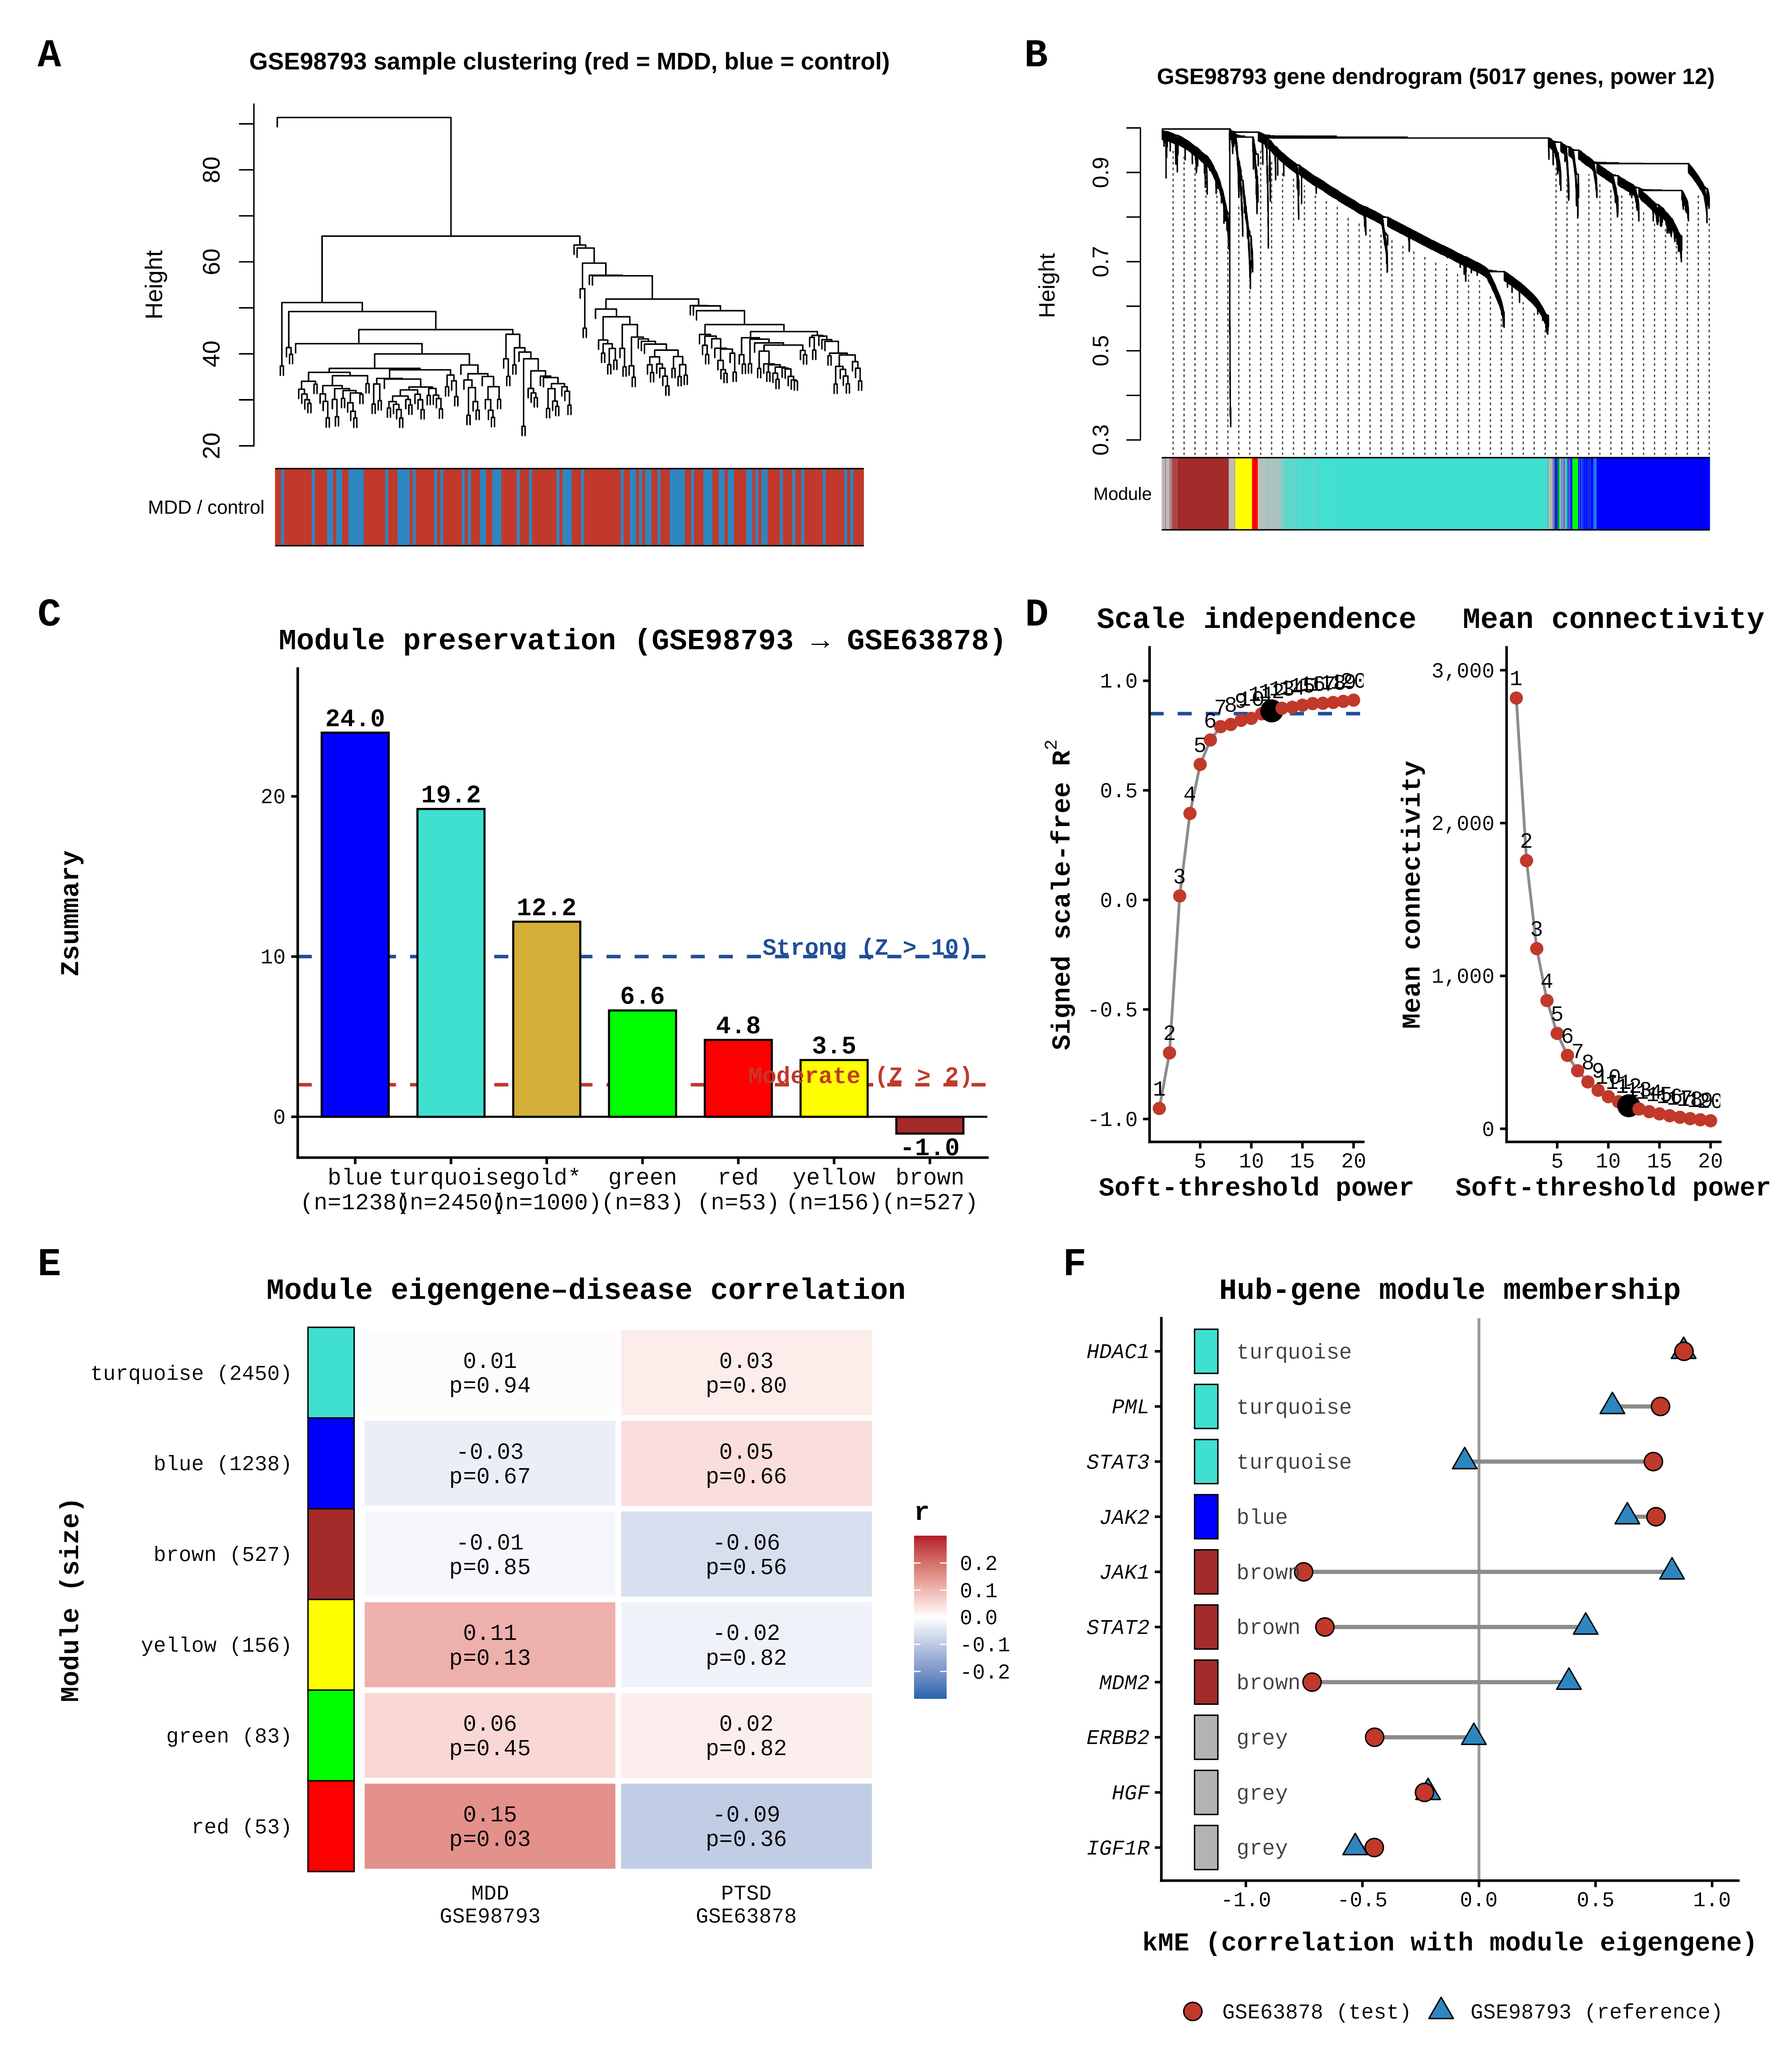

In [ ]:
!Rscript /content/WGCNA_figures.R
from IPython.display import Image
Image("/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final2/Fig4_composite.png", width=900)

In [ ]:
!Rscript "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/WGCNA_full_Final3.R"

Fatal error: cannot open file '/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/WGCNA_full_Final3.R': No such file or directory


In [ ]:
%%writefile /content/WGCNA_full_Final3.R

Writing /content/WGCNA_full_Final3.R


In [ ]:
!Rscript /content/WGCNA_full_Final3.R

In [ ]:
# ONE CELL: mount Drive -> write R script -> run it with Rscript (paste this whole cell as is)
from google.colab import drive
drive.mount('/content/drive')

R_CODE = r'''
options(stringsAsFactors = FALSE, warn = 1)
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager", repos = "https://cloud.r-project.org")
for (p in c("impute", "preprocessCore", "GO.db", "AnnotationDbi"))
  if (!requireNamespace(p, quietly = TRUE)) BiocManager::install(p, ask = FALSE, update = FALSE)
for (p in c("WGCNA", "data.table", "ggplot2", "patchwork", "png", "scales"))
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p, repos = "https://cloud.r-project.org")
suppressPackageStartupMessages({
  library(WGCNA); library(data.table); library(ggplot2); library(patchwork)
  library(png); library(grid); library(scales)
})
allowWGCNAThreads()

## ---------------- 1. PATHS + PARAMETERS
ROOT <- "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
SM   <- paste0(ROOT, "process_datasets_0.08/WGCNA/")
OUT  <- paste0(ROOT, "process_datasets_0.08/WGCNA/Final3/")
FIG  <- paste0(OUT, "Figures/")
dir.create(FIG, recursive = TRUE, showWarnings = FALSE)

SEARCH_DIRS <- paste0(ROOT, c("process_datasets_0.08/datasets/", "Final_validation/"))
MIN_COLS   <- 15000
N_GENES    <- 5000
R2_CUT     <- 0.85
MIN_MODULE <- 30
DEEP_SPLIT <- 2
MERGE_CUT  <- 0.25
N_PERM     <- 200
SEED       <- 12345
HUB_GENES <- c("IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3")
SHARED_19 <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B","CYP2U1","IGF1R",
               "GALNT11","HGF","DKKL1","GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

log_file <- file(paste0(OUT, "run_log.txt"), open = "wt")
say <- function(...) { msg <- paste0(...); cat(msg, "\n"); cat(msg, "\n", file = log_file) }

pick_full <- function(gse) {
  for (d in SEARCH_DIRS) {
    f <- paste0(d, gse, "_matrix_Transpose_labeled.csv")
    if (file.exists(f)) {
      n <- ncol(fread(f, nrows = 1)) - 1
      say(sprintf("  %s: %d gene columns %s", f, n, ifelse(n >= MIN_COLS, "-> FULL, used", "-> filtered, skipped")))
      if (n >= MIN_COLS) return(f)
    }
  }
  stop("No full (unfiltered) matrix found for ", gse)
}
say("Selecting input matrices:")
REF_FILE <- pick_full("GSE98793"); TEST_FILE <- pick_full("GSE63878")

## ---------------- 2. READ + VERIFY GSM IDs
sample_ids <- function(raw, gse) {
  ex  <- fread(paste0(SM, gse, "_expression.csv"), data.table = FALSE)
  ids <- colnames(ex)[-1]
  E   <- as.matrix(ex[, -1]); storage.mode(E) <- "numeric"
  lab <- read.csv(paste0(SM, gse, "_labels.csv"))
  fallback <- paste0(gse, "_S", seq_len(nrow(raw)))
  if (length(ids) != nrow(raw)) { say("  ", gse, ": sample count differs -> numeric labels"); return(fallback) }
  cand <- setdiff(colnames(raw), "target"); cand <- cand[!grepl("\\.[0-9]+$", cand)]
  set.seed(1); cand <- sample(cand, min(30, length(cand)))
  hit <- vapply(cand, function(g) {
    x <- suppressWarnings(as.numeric(raw[[g]]))
    if (anyNA(x)) return(NA)
    d <- rowSums(abs(sweep(E, 2, x)))
    any(d < 1e-3, na.rm = TRUE)
  }, logical(1))
  rate <- mean(hit, na.rm = TRUE)
  labs <- lab$Label[match(ids, lab$Sample)]
  lab_ok <- isTRUE(all(as.integer(labs == 1) == as.integer(raw$target == 1)))
  say(sprintf("  %s: %.0f%% of tested genes match the series matrix in the same sample order; labels identical: %s",
              gse, 100 * rate, lab_ok))
  if (rate >= 0.8 && lab_ok) ids else { say("  ", gse, ": order NOT verified -> numeric labels"); fallback }
}

read_gene_matrix <- function(path, gse, name) {
  df <- fread(path, data.table = FALSE, check.names = FALSE)
  ids <- sample_ids(df, gse)
  y  <- as.integer(df$target == 1)
  X  <- df[, setdiff(colnames(df), "target"), drop = FALSE]
  X[] <- lapply(X, function(v) suppressWarnings(as.numeric(v)))
  X  <- X[, colSums(!is.na(X)) > 0, drop = FALSE]
  sym <- sub("\\.[0-9]+$", "", colnames(X))
  keep <- sym != "" & !grepl("///", sym, fixed = TRUE)
  X <- X[, keep, drop = FALSE]; sym <- sym[keep]
  M <- as.matrix(X)
  logged <- max(M, na.rm = TRUE) > 50
  if (logged) M <- log2(pmax(M, 0) + 1)
  idx <- split(seq_along(sym), sym)
  G <- sapply(idx, function(i) if (length(i) == 1) M[, i] else rowMeans(M[, i, drop = FALSE], na.rm = TRUE))
  for (j in seq_len(ncol(G))) { v <- G[, j]; v[is.na(v)] <- median(v, na.rm = TRUE); G[, j] <- v }
  rownames(G) <- ids
  say(sprintf("%s: %d samples (case %d / control %d); %d probes -> %d genes; log2 applied %s",
              name, nrow(G), sum(y), sum(1 - y), ncol(X), ncol(G), logged))
  list(X = as.data.frame(G), y = y)
}
say("Reference file: ", REF_FILE); say("Test file: ", TEST_FILE)
ref  <- read_gene_matrix(REF_FILE,  "GSE98793", "GSE98793 (reference)")
test <- read_gene_matrix(TEST_FILE, "GSE63878", "GSE63878 (test)")

## ---------------- 3. GENE SET
common <- intersect(colnames(ref$X), colnames(test$X))
vR <- apply(ref$X[, common], 2, var); vT <- apply(test$X[, common], 2, var)
common <- common[vR > 0 & vT > 0]
top <- names(sort(vR[common], decreasing = TRUE))[seq_len(min(N_GENES, length(common)))]
forced <- setdiff(intersect(c(HUB_GENES, SHARED_19), common), top)
genes <- c(top, forced)
say("Genes measured in both datasets: ", length(common), "; used: ", length(genes),
    " (top ", length(top), " + forced ", length(forced), ")")
datRef <- ref$X[, genes]; datTest <- test$X[, genes]
gsgR <- goodSamplesGenes(datRef, verbose = 0); gsgT <- goodSamplesGenes(datTest, verbose = 0)
okG <- gsgR$goodGenes & gsgT$goodGenes
datRef <- datRef[gsgR$goodSamples, okG]; datTest <- datTest[gsgT$goodSamples, okG]
yRef <- ref$y[gsgR$goodSamples]; yTest <- test$y[gsgT$goodSamples]
say("Final matrices: reference ", nrow(datRef), " x ", ncol(datRef), "; test ", nrow(datTest), " x ", ncol(datTest))

## ---------------- 4. SOFT THRESHOLD
powers <- 1:20
sft <- pickSoftThreshold(datRef, powerVector = powers, networkType = "signed", verbose = 0)
fit <- -sign(sft$fitIndices$slope) * sft$fitIndices$SFT.R.sq
ok <- which(fit >= R2_CUT)
softPower <- if (length(ok)) powers[min(ok)] else powers[which.max(fit)]
say(sprintf("Soft power = %d (signed R^2 = %.3f; mean connectivity = %.1f)", softPower,
            fit[powers == softPower], sft$fitIndices$mean.k.[powers == softPower]))
sftTab <- cbind(sft$fitIndices, signedR2 = fit)
write.csv(sftTab, paste0(OUT, "S_soft_threshold_table.csv"), row.names = FALSE)

## ---------------- 5. MODULES
net <- blockwiseModules(datRef, power = softPower, networkType = "signed", TOMType = "signed",
                        corType = "pearson", maxBlockSize = ncol(datRef) + 10,
                        minModuleSize = MIN_MODULE, deepSplit = DEEP_SPLIT, mergeCutHeight = MERGE_CUT,
                        reassignThreshold = 0, pamRespectsDendro = FALSE, numericLabels = TRUE,
                        randomSeed = SEED, saveTOMs = FALSE, verbose = 0)
moduleColors <- labels2colors(net$colors); names(moduleColors) <- colnames(datRef)
modSize <- sort(table(moduleColors), decreasing = TRUE)
say("Modules (excluding grey): ", sum(names(modSize) != "grey"), "; smallest = ",
    min(modSize[names(modSize) != "grey"]), " genes; grey = ", ifelse("grey" %in% names(modSize), modSize[["grey"]], 0))
write.csv(data.frame(Module = names(modSize), Size = as.integer(modSize)), paste0(OUT, "S_module_sizes.csv"), row.names = FALSE)
write.csv(data.frame(Gene = names(moduleColors), Module = moduleColors), paste0(OUT, "S_gene_module_assignment.csv"), row.names = FALSE)

## ---------------- 6. MODULE-TRAIT
MEref  <- orderMEs(moduleEigengenes(datRef, moduleColors)$eigengenes)
MEtest <- moduleEigengenes(datTest, moduleColors)$eigengenes[, colnames(MEref)]
mt <- function(ME, y) { r <- cor(ME, y, use = "p"); cbind(r = r[, 1], p = corPvalueStudent(r[, 1], length(y))) }
tR <- mt(MEref, yRef); tT <- mt(MEtest, yTest)
trait <- data.frame(Module = sub("^ME", "", colnames(MEref)),
                    Size = as.integer(modSize[sub("^ME", "", colnames(MEref))]),
                    r_MDD_GSE98793 = tR[, "r"], p_MDD = tR[, "p"], FDR_MDD = p.adjust(tR[, "p"], "BH"),
                    r_PTSD_GSE63878 = tT[, "r"], p_PTSD = tT[, "p"], FDR_PTSD = p.adjust(tT[, "p"], "BH"))
write.csv(trait, paste0(OUT, "S_module_trait_correlation.csv"), row.names = FALSE)
say("Modules associated with MDD (FDR<0.05, excl. grey): ",
    paste(trait$Module[trait$Module != "grey" & trait$FDR_MDD < 0.05], collapse = ", "))

## ---------------- 7. HUB / SHARED GENES
kmeR <- signedKME(datRef, MEref); kmeT <- signedKME(datTest, MEtest)
gsR <- cor(datRef, yRef); gsT <- cor(datTest, yTest)
focus <- intersect(unique(c(HUB_GENES, SHARED_19)), colnames(datRef))
hub <- do.call(rbind, lapply(focus, function(g) {
  m <- moduleColors[[g]]; col <- paste0("kME", m)
  data.frame(Gene = g, Set = ifelse(g %in% HUB_GENES & g %in% SHARED_19, "hub + shared DEG",
                                   ifelse(g %in% HUB_GENES, "hub (network)", "shared DEG")),
             Module = m, kME_ref = kmeR[g, col], kME_test = kmeT[g, col],
             GS_MDD = gsR[g, 1], p_GS_MDD = corPvalueStudent(gsR[g, 1], length(yRef)),
             GS_PTSD = gsT[g, 1], p_GS_PTSD = corPvalueStudent(gsT[g, 1], length(yTest)))
}))
write.csv(hub, paste0(OUT, "S_hub_and_shared_genes_module_membership.csv"), row.names = FALSE)

## ---------------- 8. MODULE PRESERVATION
say("Module preservation: reference GSE98793, test GSE63878, ", N_PERM, " permutations ...")
mp <- modulePreservation(list(GSE98793 = list(data = datRef), GSE63878 = list(data = datTest)),
                         list(GSE98793 = moduleColors), referenceNetworks = 1, testNetworks = 2,
                         networkType = "signed", corFnc = "cor", nPermutations = N_PERM,
                         maxModuleSize = max(modSize[names(modSize) != "grey"]),
                         randomSeed = SEED, quickCor = 0, verbose = 1)
obs <- cbind(mp$quality$observed[[1]][[2]][, -1, drop = FALSE], mp$preservation$observed[[1]][[2]][, -1, drop = FALSE])
Z   <- cbind(mp$quality$Z[[1]][[2]][, -1, drop = FALSE], mp$preservation$Z[[1]][[2]][, -1, drop = FALSE])
pres <- data.frame(Module = rownames(Z), ModuleSize = mp$preservation$Z[[1]][[2]]$moduleSize,
                   Zsummary = Z[, "Zsummary.pres"], Zdensity = Z[, "Zdensity.pres"],
                   Zconnectivity = Z[, "Zconnectivity.pres"], medianRank = obs[, "medianRank.pres"])
pres$Interpretation <- ifelse(pres$Zsummary > 10, "Strong", ifelse(pres$Zsummary > 2, "Moderate", "Low/none"))
pres$Note <- ifelse(pres$Module == "grey", "unassigned genes (not a module)",
                    ifelse(pres$Module == "gold", "random-gene reference (gold)", ""))
pres <- merge(pres, trait[, c("Module", "r_MDD_GSE98793", "FDR_MDD", "r_PTSD_GSE63878", "FDR_PTSD")], by = "Module", all.x = TRUE)
pres <- pres[order(-pres$Zsummary), ]
write.csv(pres, paste0(OUT, "Table3_module_preservation.csv"), row.names = FALSE)
save(net, moduleColors, datRef, datTest, yRef, yTest, mp, softPower, file = paste0(OUT, "WGCNA_final.RData"))
real <- pres[!pres$Module %in% c("grey", "gold"), ]
say("PARAMETERS: genes=", ncol(datRef), " power=", softPower, " minModuleSize=", MIN_MODULE,
    " deepSplit=", DEEP_SPLIT, " mergeCutHeight=", MERGE_CUT, " nPermutations=", N_PERM, " seed=", SEED)
say("Preservation: strong ", sum(real$Zsummary > 10), "; moderate ", sum(real$Zsummary > 2 & real$Zsummary <= 10),
    "; low ", sum(real$Zsummary <= 2), " of ", nrow(real), " modules")

## ---------------- 9. PUBLICATION FIGURES
BS <- 8
theme_pub <- theme_classic(base_size = BS) +
  theme(plot.title = element_text(face = "bold", size = BS + 1, hjust = 0.5),
        axis.text = element_text(colour = "black"), axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold"), legend.key.size = unit(0.35, "cm"),
        plot.margin = margin(4, 6, 4, 6))
modcol <- function(m) ifelse(m == "gold", "#D4AF37", ifelse(m == "grey", "grey70", m))
pfmt <- function(p) ifelse(p < 0.001, "p<0.001", sprintf("p=%.2f", p))
base_panel <- function(name, fun, w = 5.6, h = 3.9) {
  f <- paste0(FIG, name, ".png")
  png(f, width = w, height = h, units = "in", res = 600); fun(); dev.off()
  pdf(paste0(FIG, name, ".pdf"), width = w, height = h); fun(); dev.off()
  wrap_elements(full = rasterGrob(readPNG(f), interpolate = TRUE))
}
sample_tree_plot <- function(dat, y, title, cexLab) function() {
  tr <- hclust(dist(dat), method = "average")
  plotDendroAndColors(tr, ifelse(y == 1, "#C0392B", "#2E86C1"), groupLabels = "Status",
                      dendroLabels = NULL, cex.dendroLabels = cexLab, hang = 0.03,
                      cex.colorLabels = 0.8, cex.main = 1, main = title, marAll = c(1, 5, 3, 1))
}

pA <- base_panel("Fig4A_sample_clustering_GSE98793",
                 sample_tree_plot(datRef, yRef, "GSE98793 sample clustering (red = MDD, blue = control)", 0.22),
                 w = 9, h = 4.5)
invisible(base_panel("FigS_sample_clustering_GSE63878",
                     sample_tree_plot(datTest, yTest, "GSE63878 sample clustering (red = PTSD, blue = control)", 0.4),
                     w = 9, h = 4.5))

pB <- base_panel("Fig4B_gene_dendrogram", function() {
  plotDendroAndColors(net$dendrograms[[1]], moduleColors[net$blockGenes[[1]]], "Module",
                      dendroLabels = FALSE, hang = 0.03, addGuide = TRUE, guideHang = 0.05,
                      cex.colorLabels = 0.8, cex.main = 1, marAll = c(1, 5, 3, 1),
                      main = sprintf("GSE98793 gene dendrogram (%d genes, power %d)", ncol(datRef), softPower))
})

pc <- pres[pres$Module != "grey", ]; pc <- pc[order(-pc$Zsummary), ]
labs_c <- ifelse(pc$Module == "gold", paste0("gold*\n(n=", pc$ModuleSize, ")"),
                 paste0(pc$Module, "\n(n=", pc$ModuleSize, ")"))
pc$Label <- factor(labs_c, levels = unique(labs_c))
pC <- ggplot(pc, aes(Label, Zsummary, fill = Module)) +
  geom_hline(yintercept = c(2, 10), linetype = "dashed", colour = c("#C0392B", "#1F4E99"), linewidth = 0.5) +
  geom_col(width = 0.7, colour = "black", linewidth = 0.3) +
  geom_text(aes(label = sprintf("%.1f", Zsummary), vjust = ifelse(Zsummary >= 0, -0.4, 1.3)), size = BS / 3, fontface = "bold") +
  annotate("text", x = nrow(pc) + 0.45, y = 10.6, label = "Strong (Z > 10)", hjust = 1, colour = "#1F4E99", size = BS / 3.2, fontface = "bold") +
  annotate("text", x = nrow(pc) + 0.45, y = 2.6, label = "Moderate (Z > 2)", hjust = 1, colour = "#C0392B", size = BS / 3.2, fontface = "bold") +
  scale_fill_manual(values = setNames(modcol(pc$Module), pc$Module), guide = "none") +
  scale_y_continuous(limits = c(min(0, min(pc$Zsummary)) - 1.5, max(pc$Zsummary) + 4), expand = c(0, 0)) +
  geom_hline(yintercept = 0, linewidth = 0.3) +
  labs(title = "Module preservation (GSE98793 \u2192 GSE63878)", x = NULL, y = "Zsummary") +
  theme_pub + theme(axis.text.x = element_text(size = BS - 1))

sftTab$chosen <- sftTab$Power == softPower
pt <- function(yvar, ttl, ylab) ggplot(sftTab, aes(Power, .data[[yvar]])) +
  geom_line(colour = "grey55", linewidth = 0.4) +
  geom_point(aes(colour = chosen, size = chosen)) +
  geom_text(aes(label = Power), vjust = -0.9, size = BS / 3.4) +
  scale_colour_manual(values = c(`FALSE` = "#C0392B", `TRUE` = "black"), guide = "none") +
  scale_size_manual(values = c(`FALSE` = 1.4, `TRUE` = 2.8), guide = "none") +
  labs(title = ttl, x = "Soft-threshold power", y = ylab) + theme_pub
d1 <- pt("signedR2", "Scale independence", "Signed scale-free R\u00b2") +
  geom_hline(yintercept = R2_CUT, linetype = "dashed", colour = "#1F4E99", linewidth = 0.5) +
  scale_y_continuous(limits = c(min(0, min(sftTab$signedR2)) - 0.05, 1.05))
d2 <- pt("mean.k.", "Mean connectivity", "Mean connectivity") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0.05, 0.12)))
pD <- wrap_elements(full = d1 | d2)

tm <- trait[trait$Module != "grey", ]; tm <- tm[order(-tm$Size), ]
lv <- paste0(tm$Module, " (", tm$Size, ")")
el <- rbind(data.frame(Module = tm$Module, Lab = lv, Data = "MDD\nGSE98793", r = tm$r_MDD_GSE98793, p = tm$p_MDD),
            data.frame(Module = tm$Module, Lab = lv, Data = "PTSD\nGSE63878", r = tm$r_PTSD_GSE63878, p = tm$p_PTSD))
el$Lab <- factor(el$Lab, levels = rev(lv))
lim <- max(0.3, ceiling(max(abs(el$r)) * 10) / 10)
strip <- unique(el[, c("Module", "Lab")])
pE <- ggplot(el, aes(Data, Lab, fill = r)) +
  geom_tile(colour = "white", linewidth = 0.8) +
  geom_text(aes(label = sprintf("%.2f\n%s", r, pfmt(p))), size = BS / 3.3, lineheight = 0.9) +
  geom_tile(data = strip, aes(x = 0.38, y = Lab), width = 0.18, fill = modcol(strip$Module),
            colour = "black", linewidth = 0.2, inherit.aes = FALSE) +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", limits = c(-lim, lim), oob = squish, name = "r") +
  scale_x_discrete(expand = expansion(add = c(0.75, 0.5))) +
  labs(title = "Module eigengene\u2013disease correlation", x = NULL, y = "Module (size)") +
  theme_pub + theme(axis.line = element_blank(), axis.ticks = element_blank())

hf <- hub[hub$Set != "shared DEG", ]
hf <- hf[order(match(hf$Module, c("turquoise", "blue", "brown", "green", "red", "yellow", "grey")), -hf$kME_ref), ]
hf$Gene <- factor(hf$Gene, levels = rev(hf$Gene))
hl <- rbind(data.frame(Gene = hf$Gene, kME = hf$kME_ref, Data = "GSE98793 (reference)"),
            data.frame(Gene = hf$Gene, kME = hf$kME_test, Data = "GSE63878 (test)"))
pF <- ggplot() +
  geom_vline(xintercept = 0, colour = "grey60", linewidth = 0.4) +
  geom_segment(data = hf, aes(x = kME_ref, xend = kME_test, y = Gene, yend = Gene), colour = "grey55", linewidth = 0.6) +
  geom_point(data = hl, aes(kME, Gene, shape = Data, fill = Data), size = 2.4, colour = "black", stroke = 0.3) +
  geom_tile(data = hf, aes(x = -1.17, y = Gene), width = 0.1, height = 0.8, fill = modcol(hf$Module), colour = "black", linewidth = 0.2) +
  geom_text(data = hf, aes(x = -1.04, y = Gene, label = Module), hjust = 0, size = BS / 3.5, colour = "grey25") +
  scale_shape_manual(values = c(21, 24), name = NULL) +
  scale_fill_manual(values = c("#C0392B", "#2E86C1"), name = NULL) +
  scale_x_continuous(limits = c(-1.25, 1), breaks = seq(-1, 1, 0.5)) +
  labs(title = "Hub-gene module membership", x = "kME (correlation with module eigengene)", y = NULL) +
  theme_pub + theme(legend.position = "bottom", axis.text.y = element_text(face = "italic"))

for (x in list(list(pC, "Fig4C_module_preservation", 4.5, 3.3), list(d1 | d2, "Fig4D_soft_threshold", 6, 3),
               list(pE, "Fig4E_module_trait_heatmap", 4, 4), list(pF, "Fig4F_hub_gene_kME", 4.5, 3.8))) {
  ggsave(paste0(FIG, x[[2]], ".pdf"), x[[1]], width = x[[3]], height = x[[4]])
  ggsave(paste0(FIG, x[[2]], ".png"), x[[1]], width = x[[3]], height = x[[4]], dpi = 600, bg = "white")
}

fig4 <- pA / (pB | pC) / (pD) / (pE | pF) +
  plot_layout(heights = c(1.1, 1, 0.8, 1.15)) +
  plot_annotation(tag_levels = "A") & theme(plot.tag = element_text(face = "bold", size = 12))
ggsave(paste0(FIG, "Fig4_composite.pdf"), fig4, width = 7.5, height = 8.75)
ggsave(paste0(FIG, "Fig4_composite.png"), fig4, width = 7.5, height = 8.75, dpi = 600, bg = "white")
ggsave(paste0(FIG, "Fig4_composite.tiff"), fig4, width = 7.5, height = 8.75, dpi = 600, compression = "lzw", bg = "white")

writeLines(capture.output(sessionInfo()), paste0(OUT, "sessionInfo.txt"))
close(log_file)
cat("\nResults:", OUT, "\nFigures:", FIG, "\n"); print(list.files(FIG))
'''

with open("/content/WGCNA_full_Final3.R", "w") as f:
    f.write(R_CODE)
print("R script written. Running... (30-90 min)")

import subprocess, sys
proc = subprocess.Popen(["Rscript", "/content/WGCNA_full_Final3.R"],
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    sys.stdout.write(line); sys.stdout.flush()
proc.wait()
print("\nFINISHED, exit code:", proc.returncode)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
R script written. Running... (30-90 min)

Allowing multi-threading with up to 2 threads.
Selecting input matrices: 
  /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/datasets/GSE98793_matrix_Transpose_labeled.csv: 4607 gene columns -> filtered, skipped 
  /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/Final_validation/GSE98793_matrix_Transpose_labeled.csv: 45118 gene columns -> FULL, used 
  /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/datasets/GSE63878_matrix_Transpose_labeled.csv: 858 gene columns -> filtered, skipped 
  /content/drive/MyDrive/research/p5-s

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Allowing multi-threading with up to 2 threads.
saved W1_sample_dendrogram_trait_GSE98793 
saved W1_sample_dendrogram_trait_GSE63878 
saved W2_module_trait_relationships 
saved W3_eigengene_network 
saved W4_TOM_network_heatmap 
saved W5_MM_vs_GS_hub_modules 
saved W6_module_significance 
saved W7_module_preservation_size 

All published-style figures saved to: /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final3/Figures_published_style/ 
[1] "W1_sample_dendrogram_trait_GSE63878.png"
[2] "W1_sample_dendrogram_trait_GSE98793.png"
[3] "W2_module_trait_relationships.png"      
[4] "W3_eigengene_network.png"               
[5] "W4_TOM_network_heatmap.png"             
[6] "W5_MM_vs_GS_hub_modules.png"            
[7] "W6_module_significance.png"     

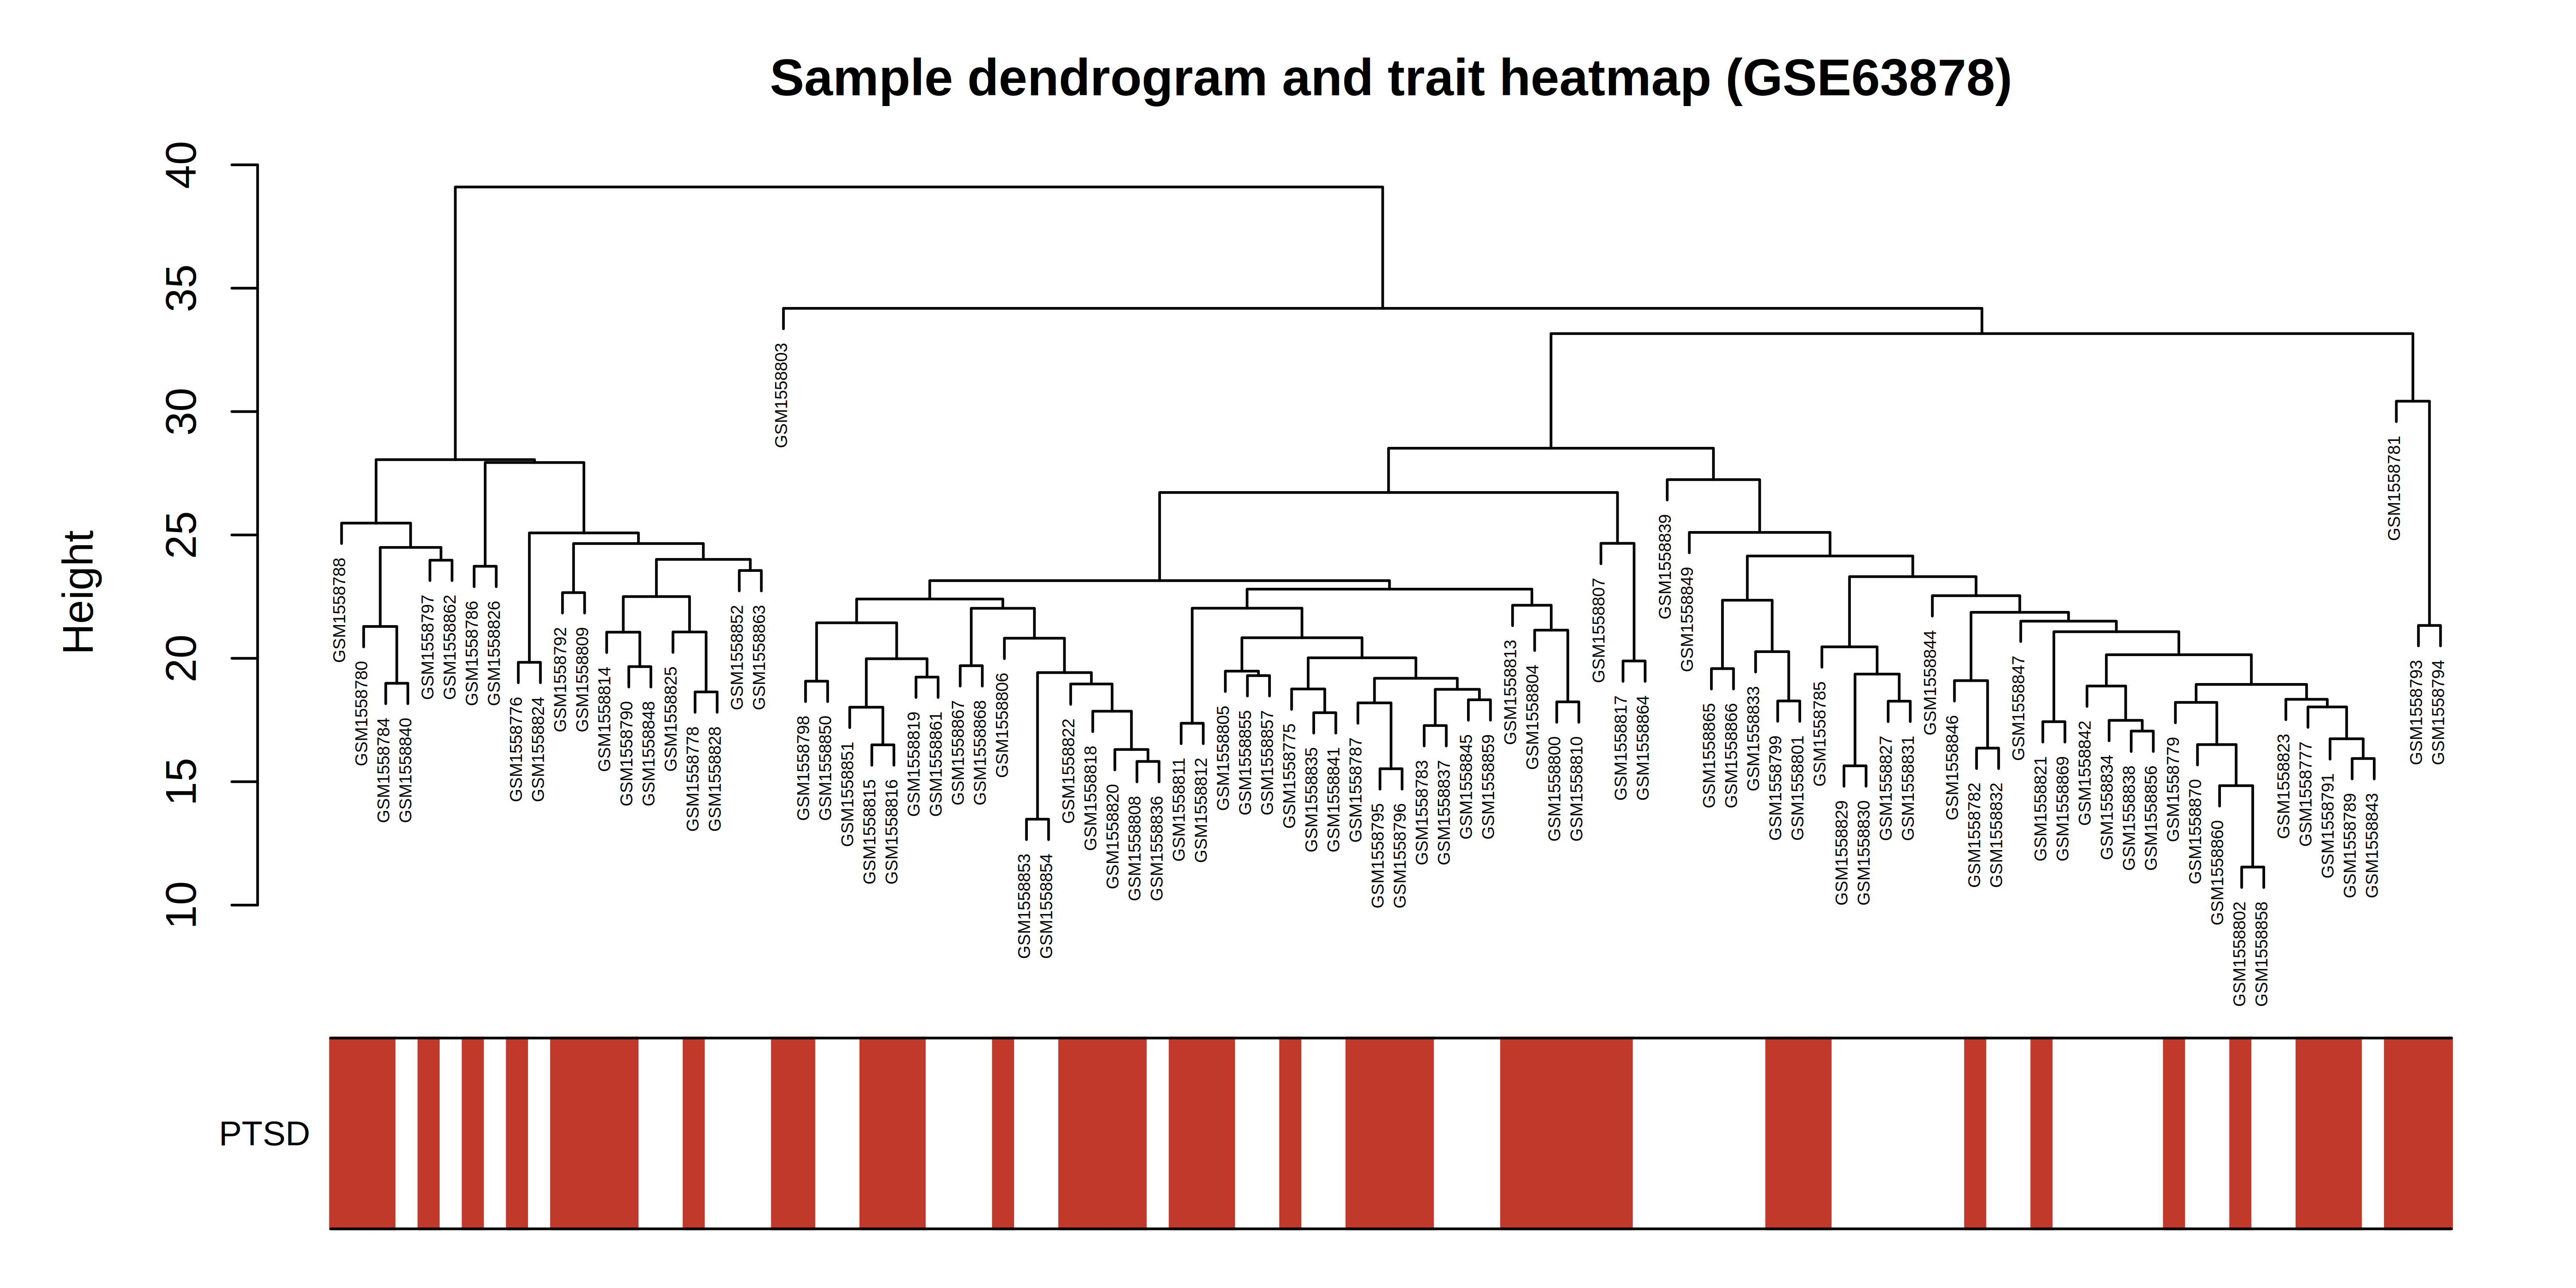

W1_sample_dendrogram_trait_GSE98793.png


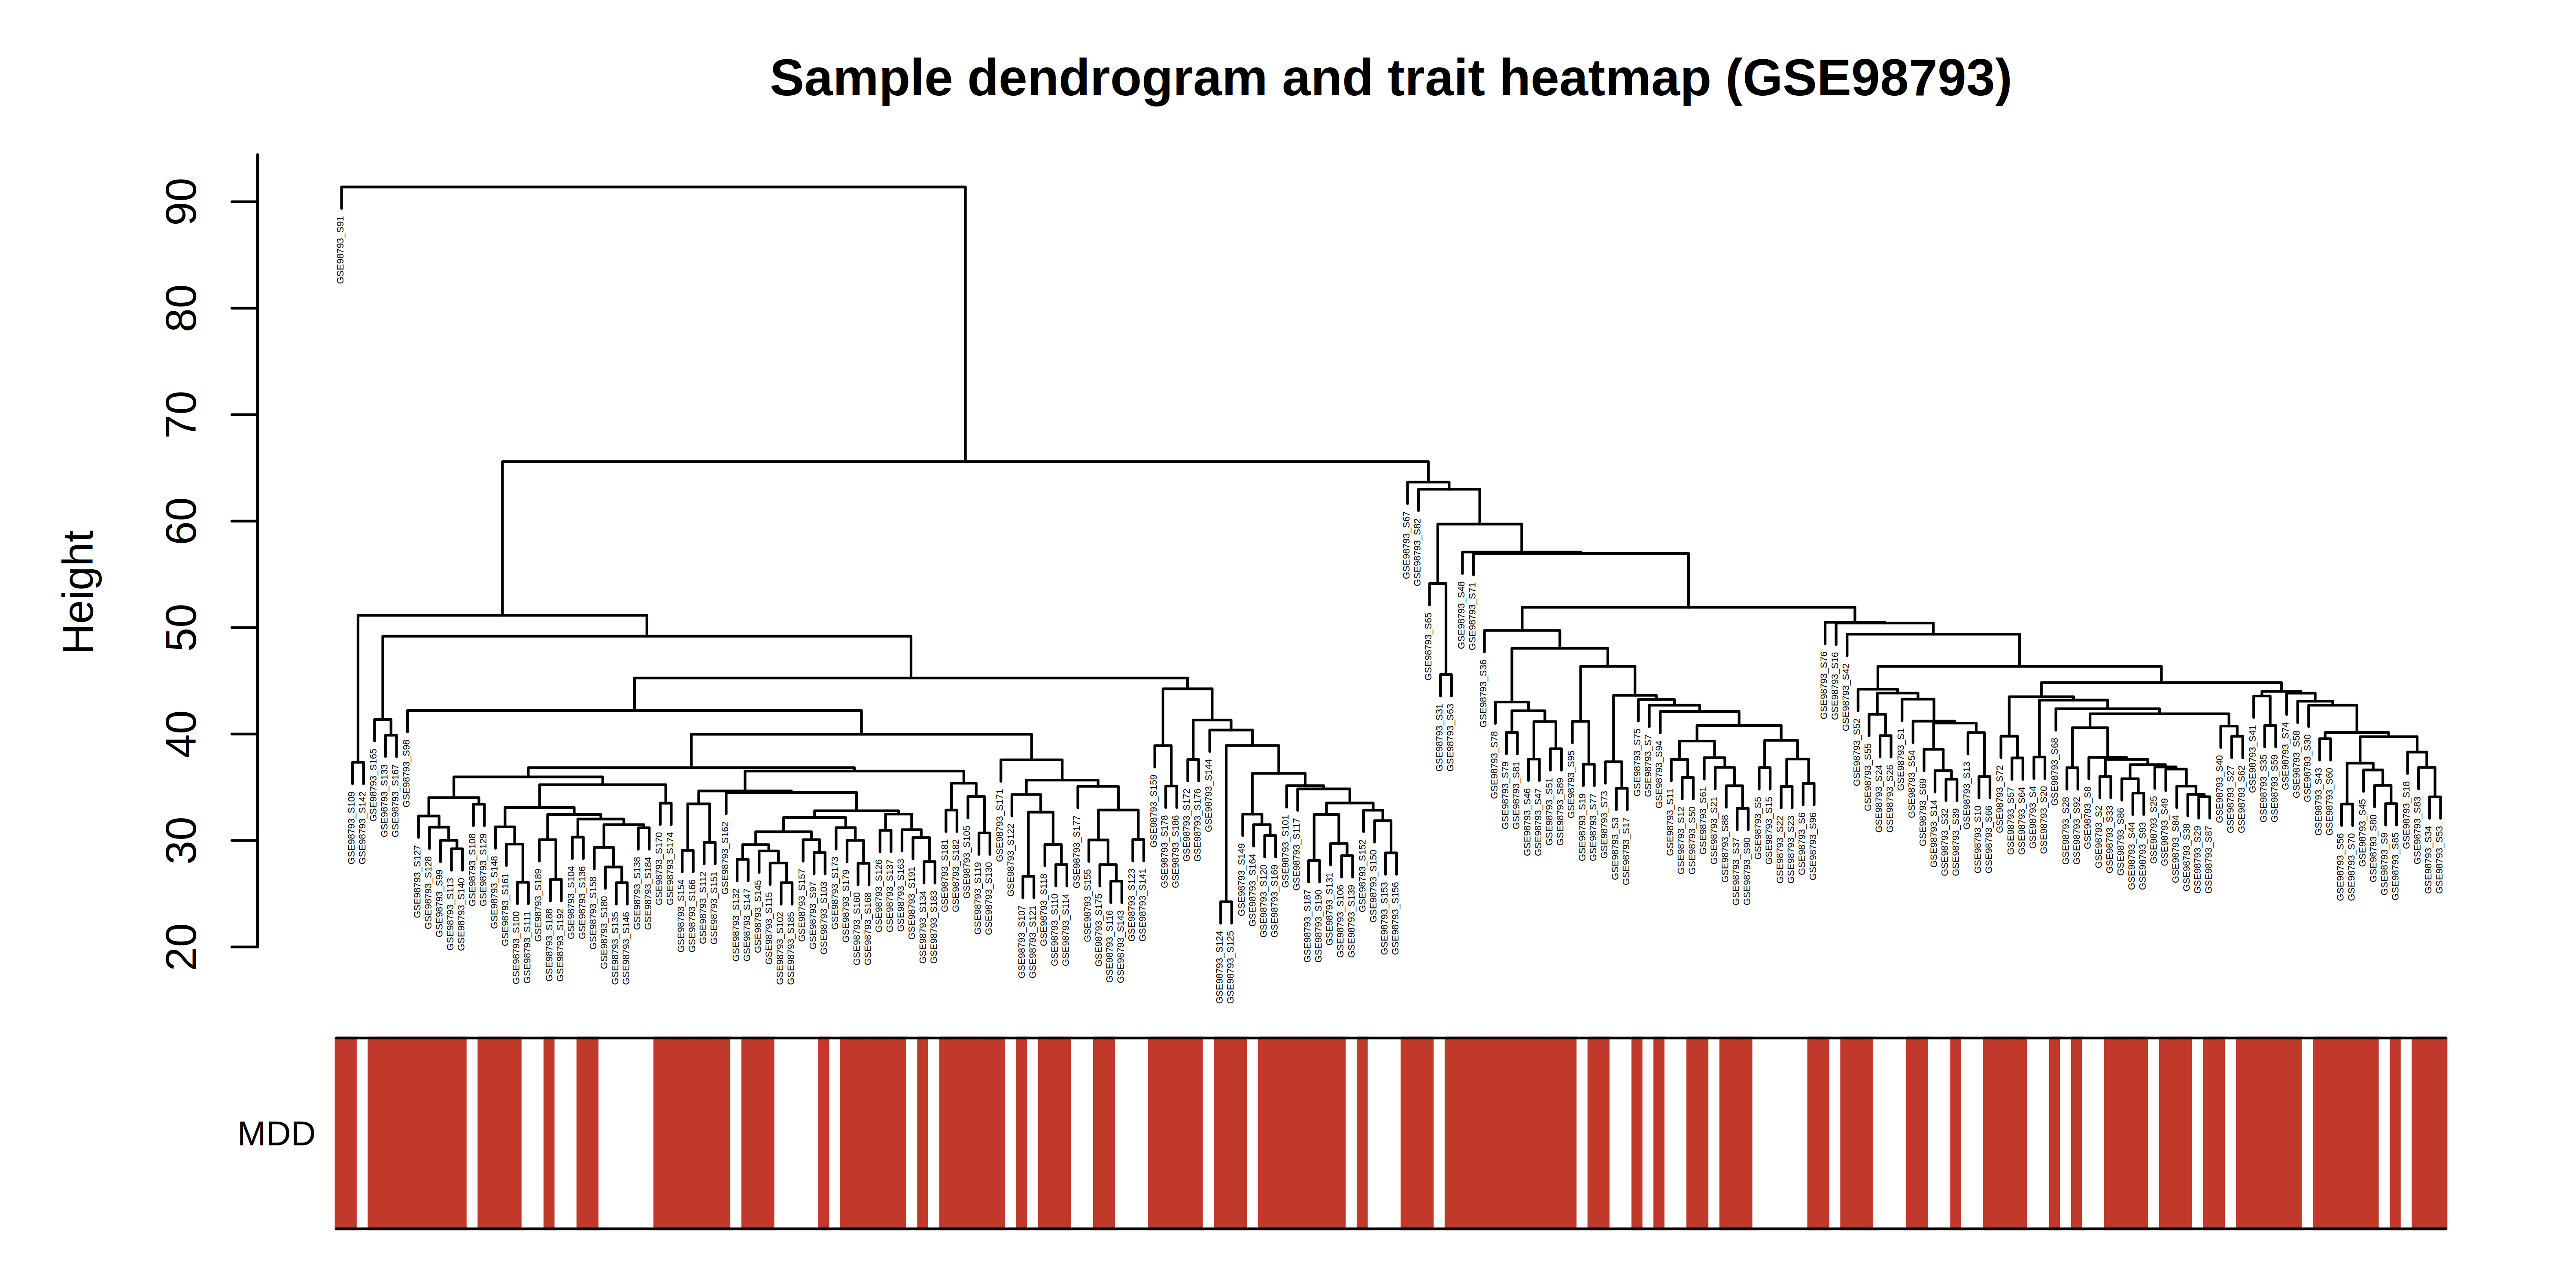

W2_module_trait_relationships.png


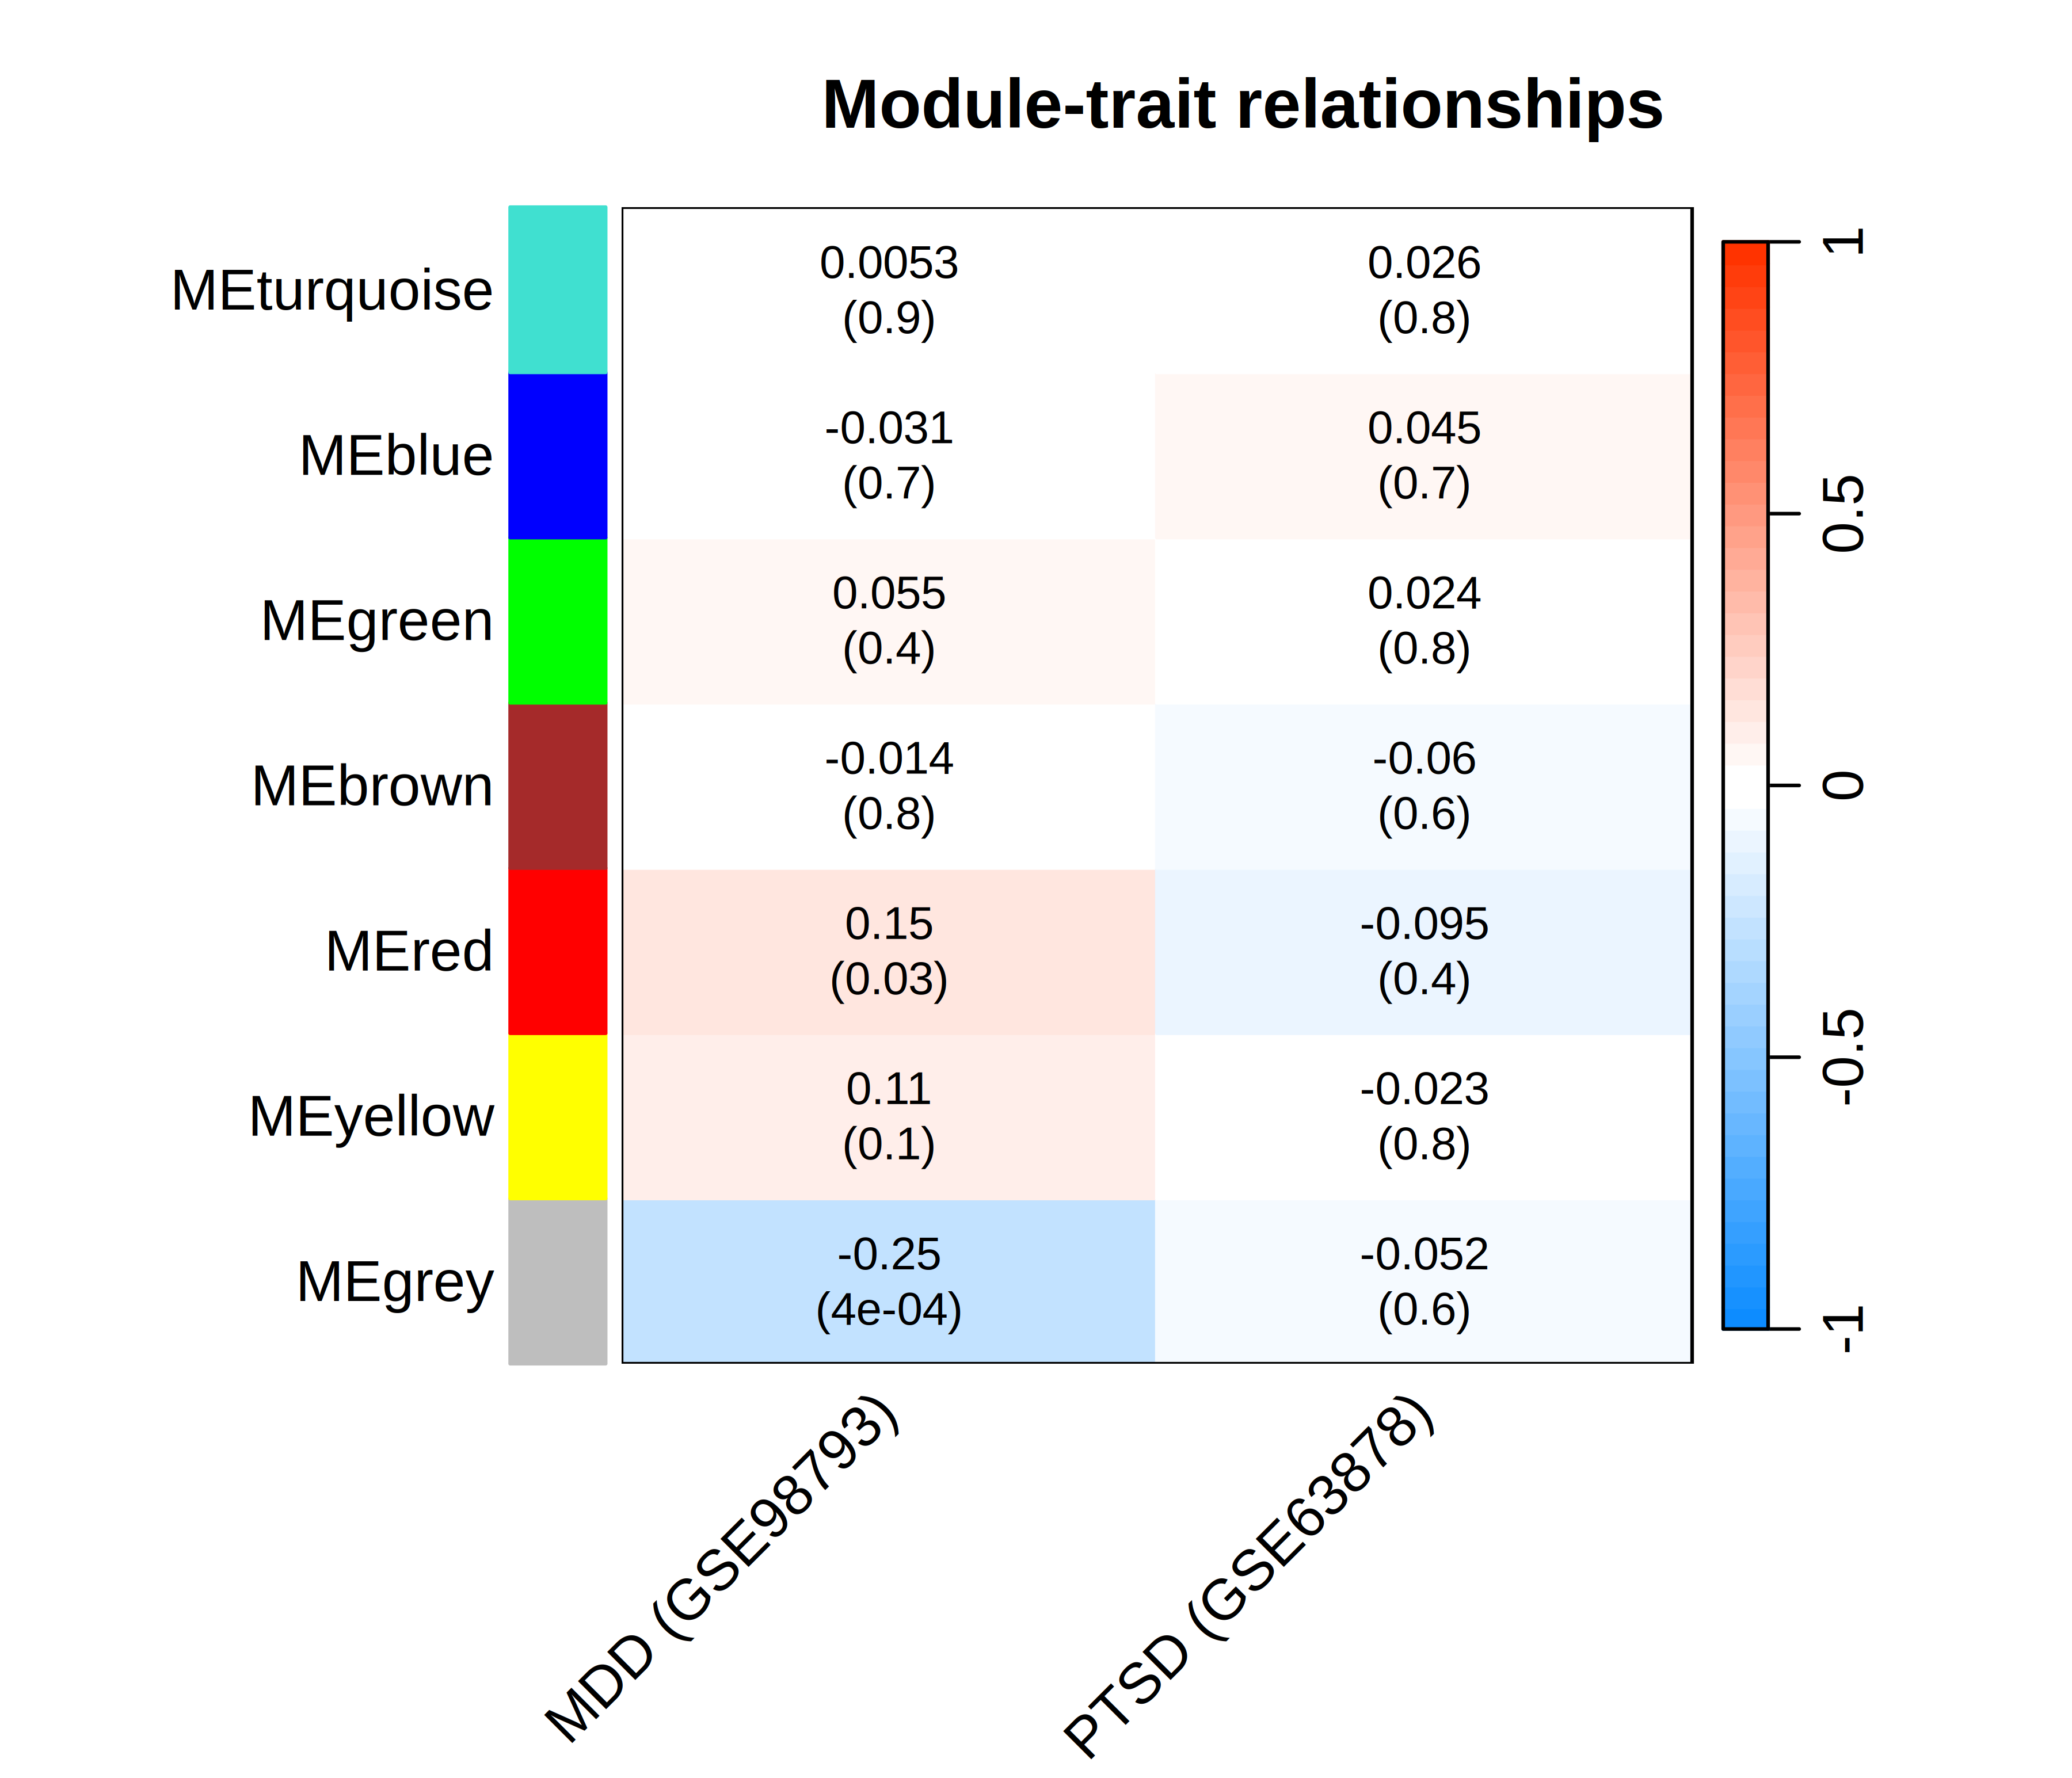

W3_eigengene_network.png


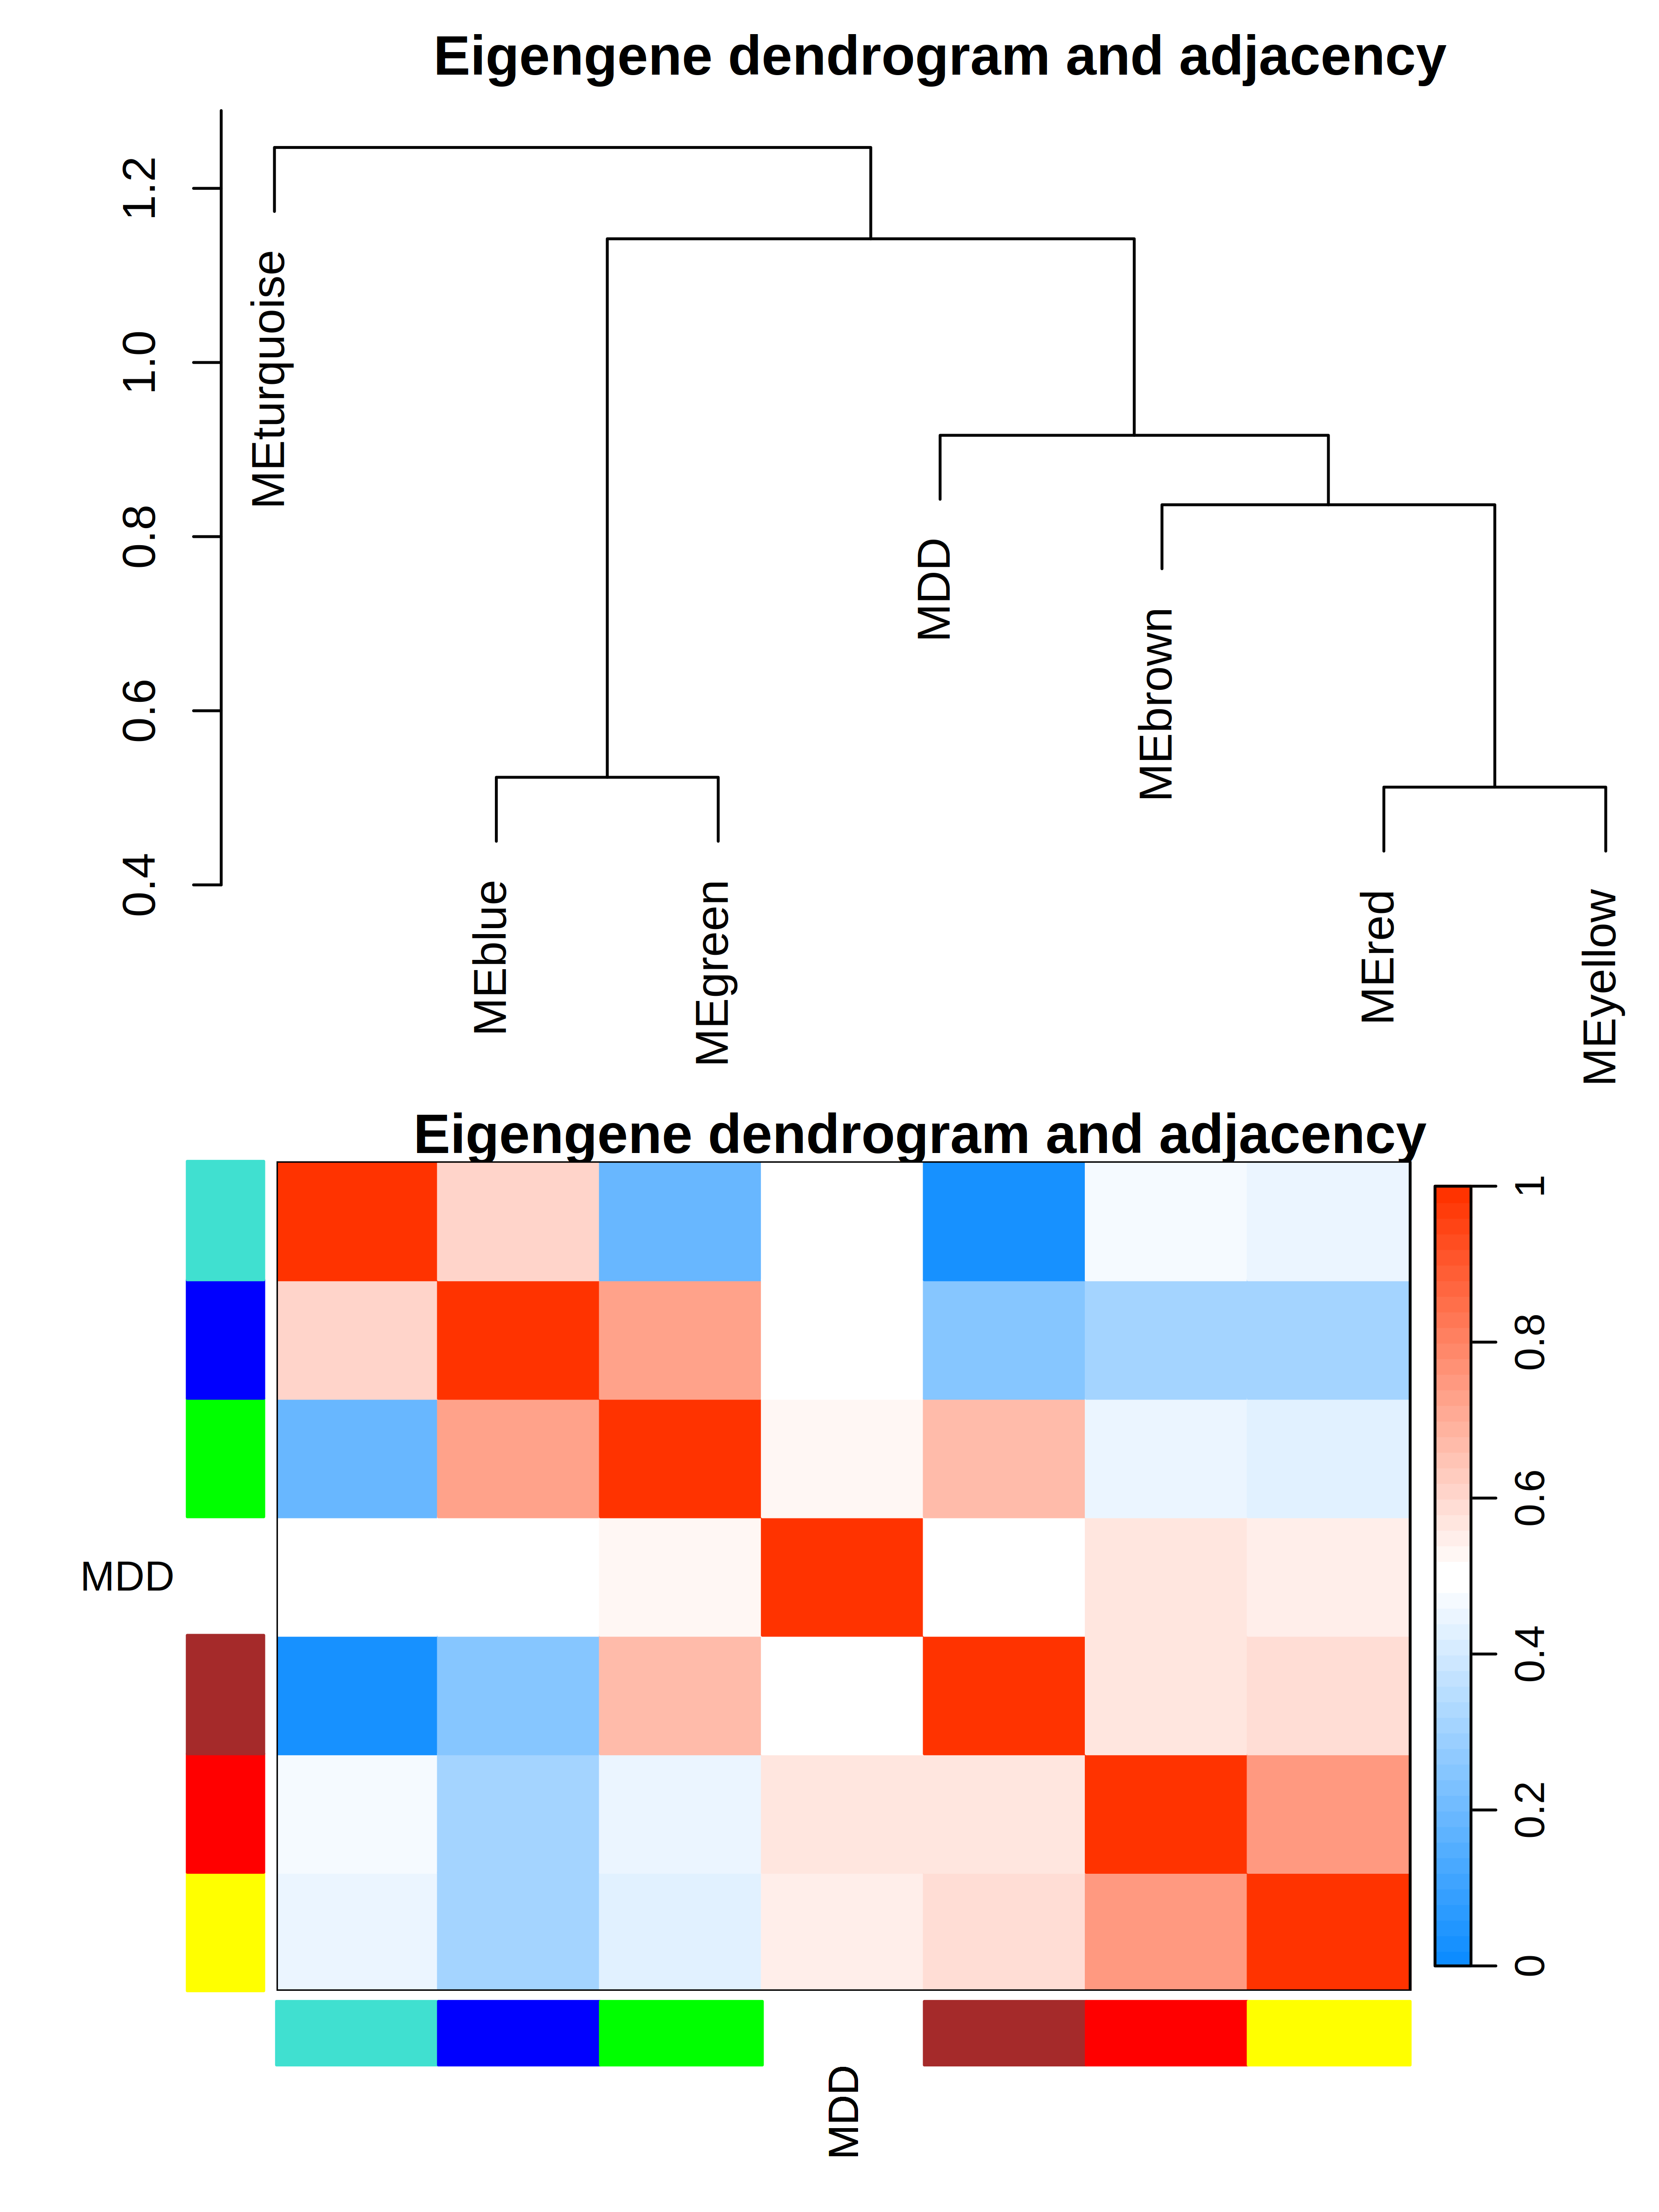

W4_TOM_network_heatmap.png


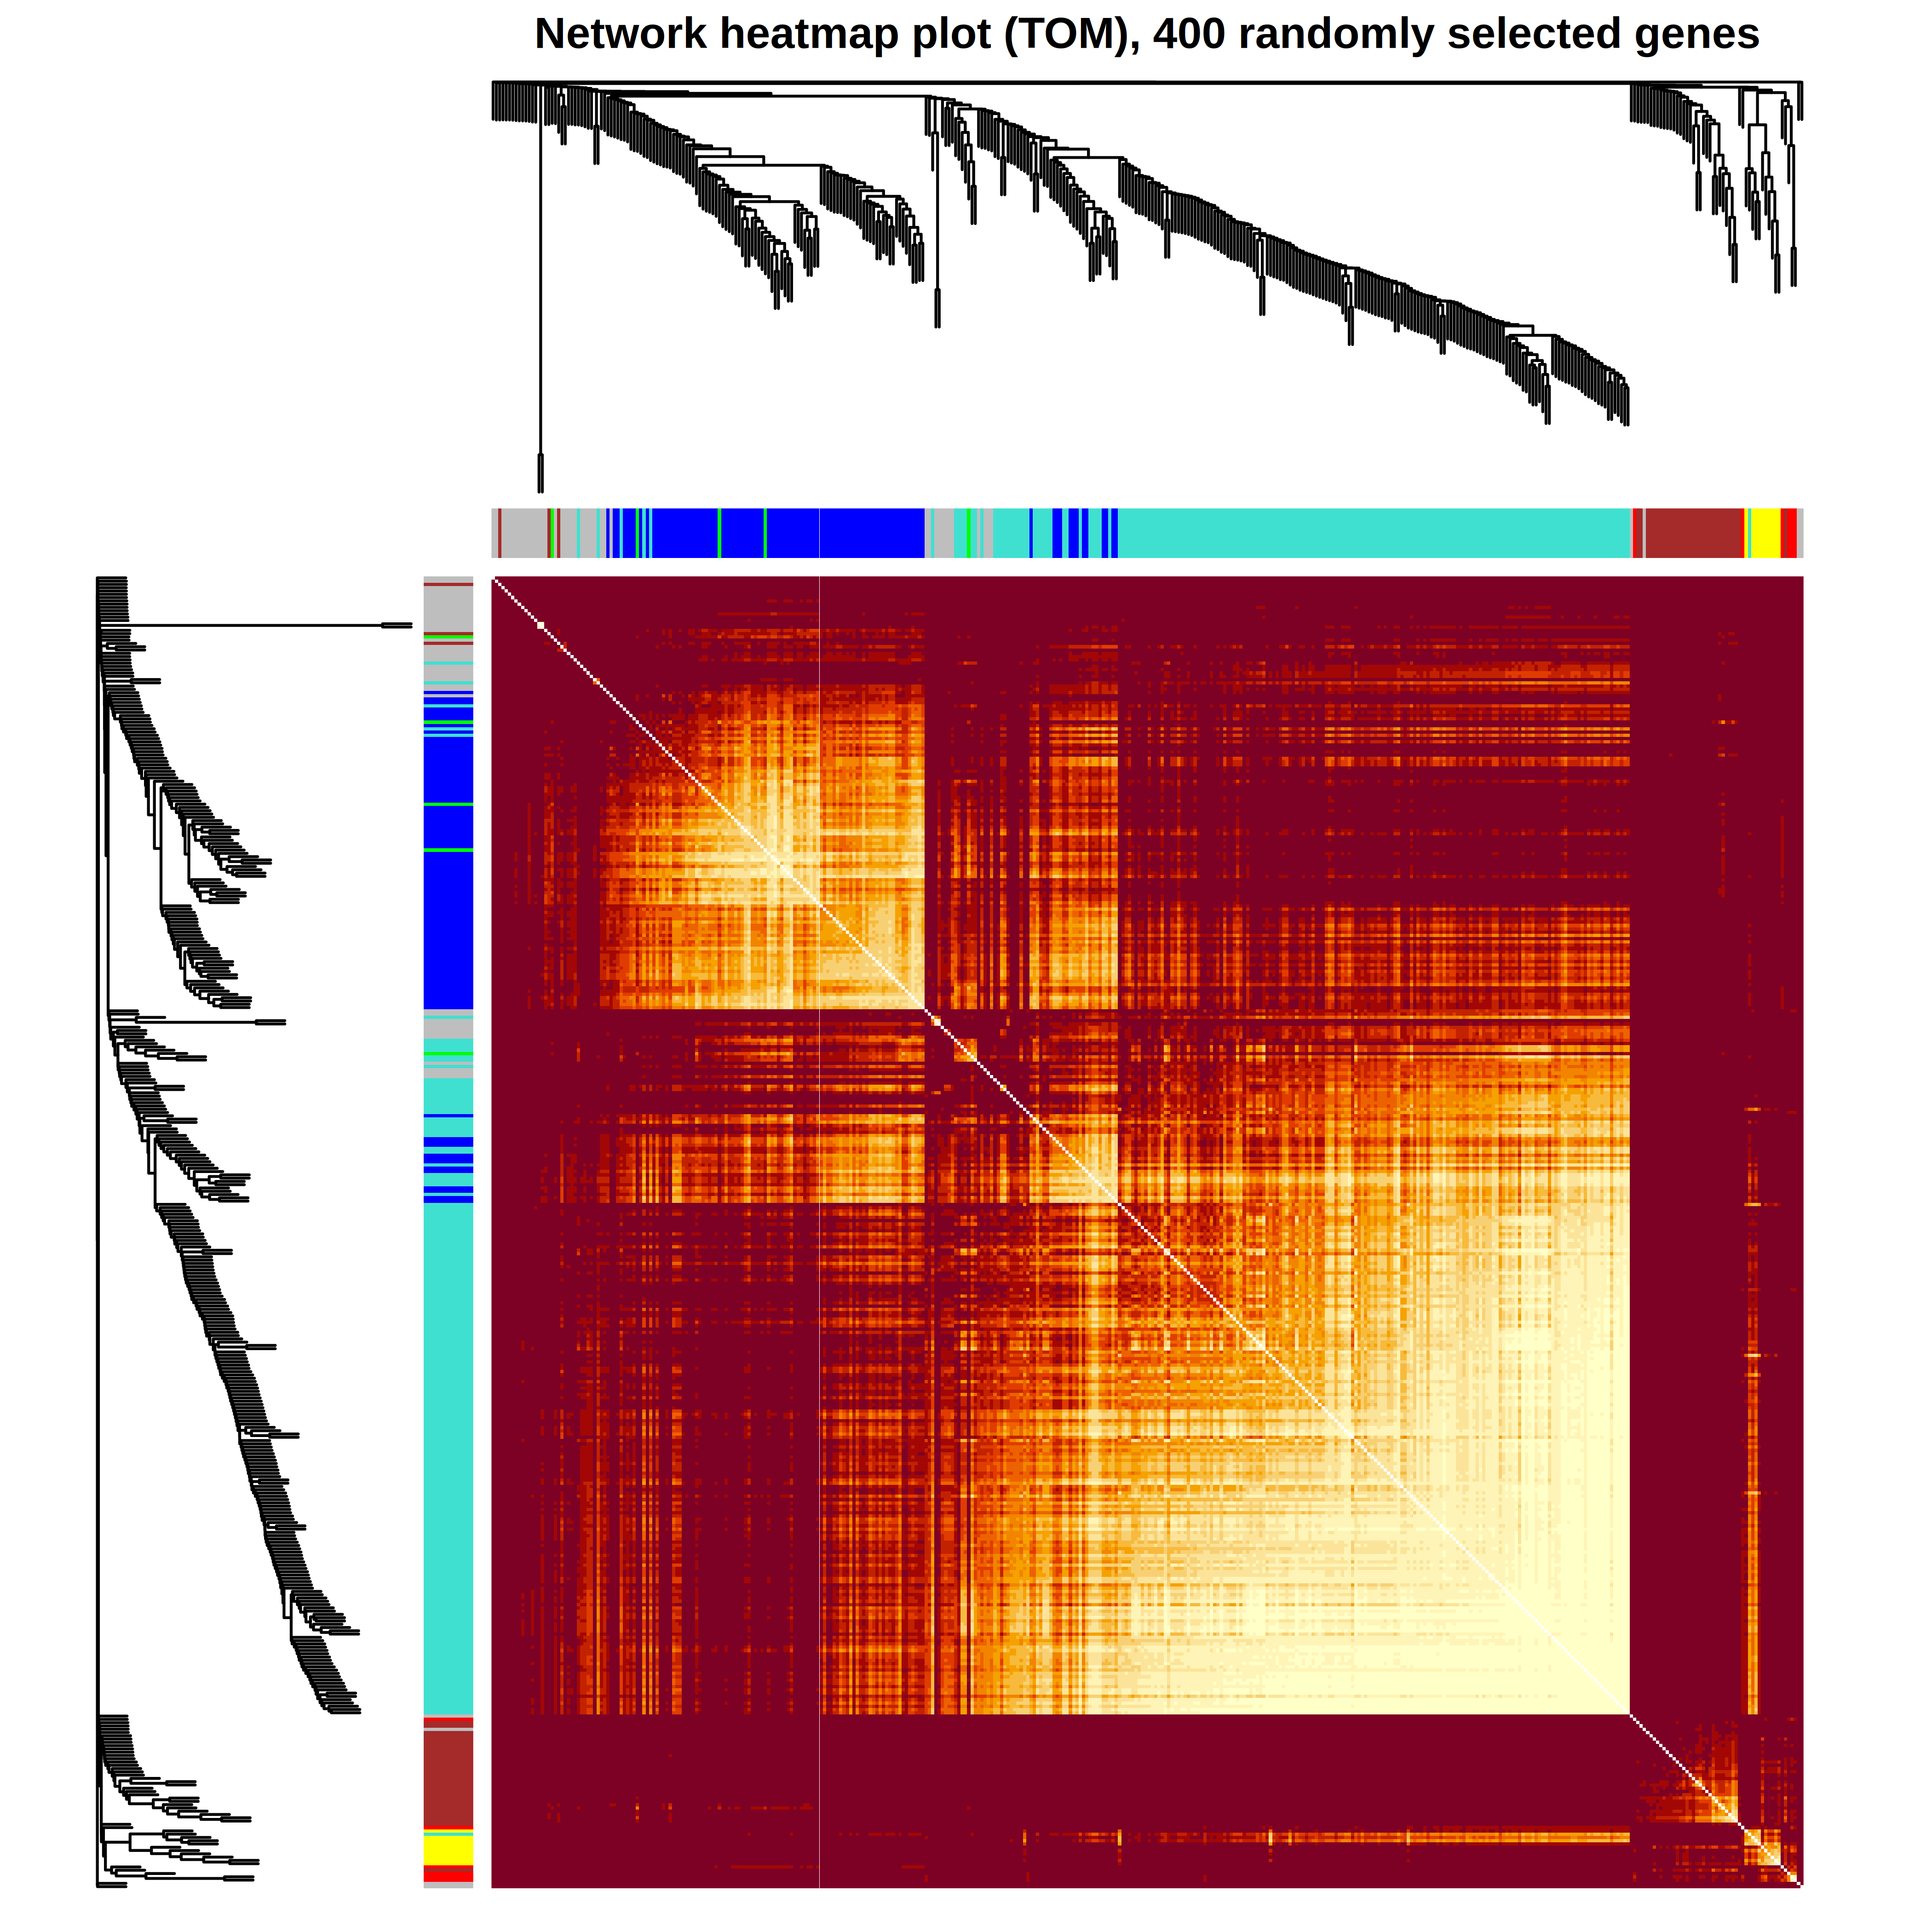

W5_MM_vs_GS_hub_modules.png


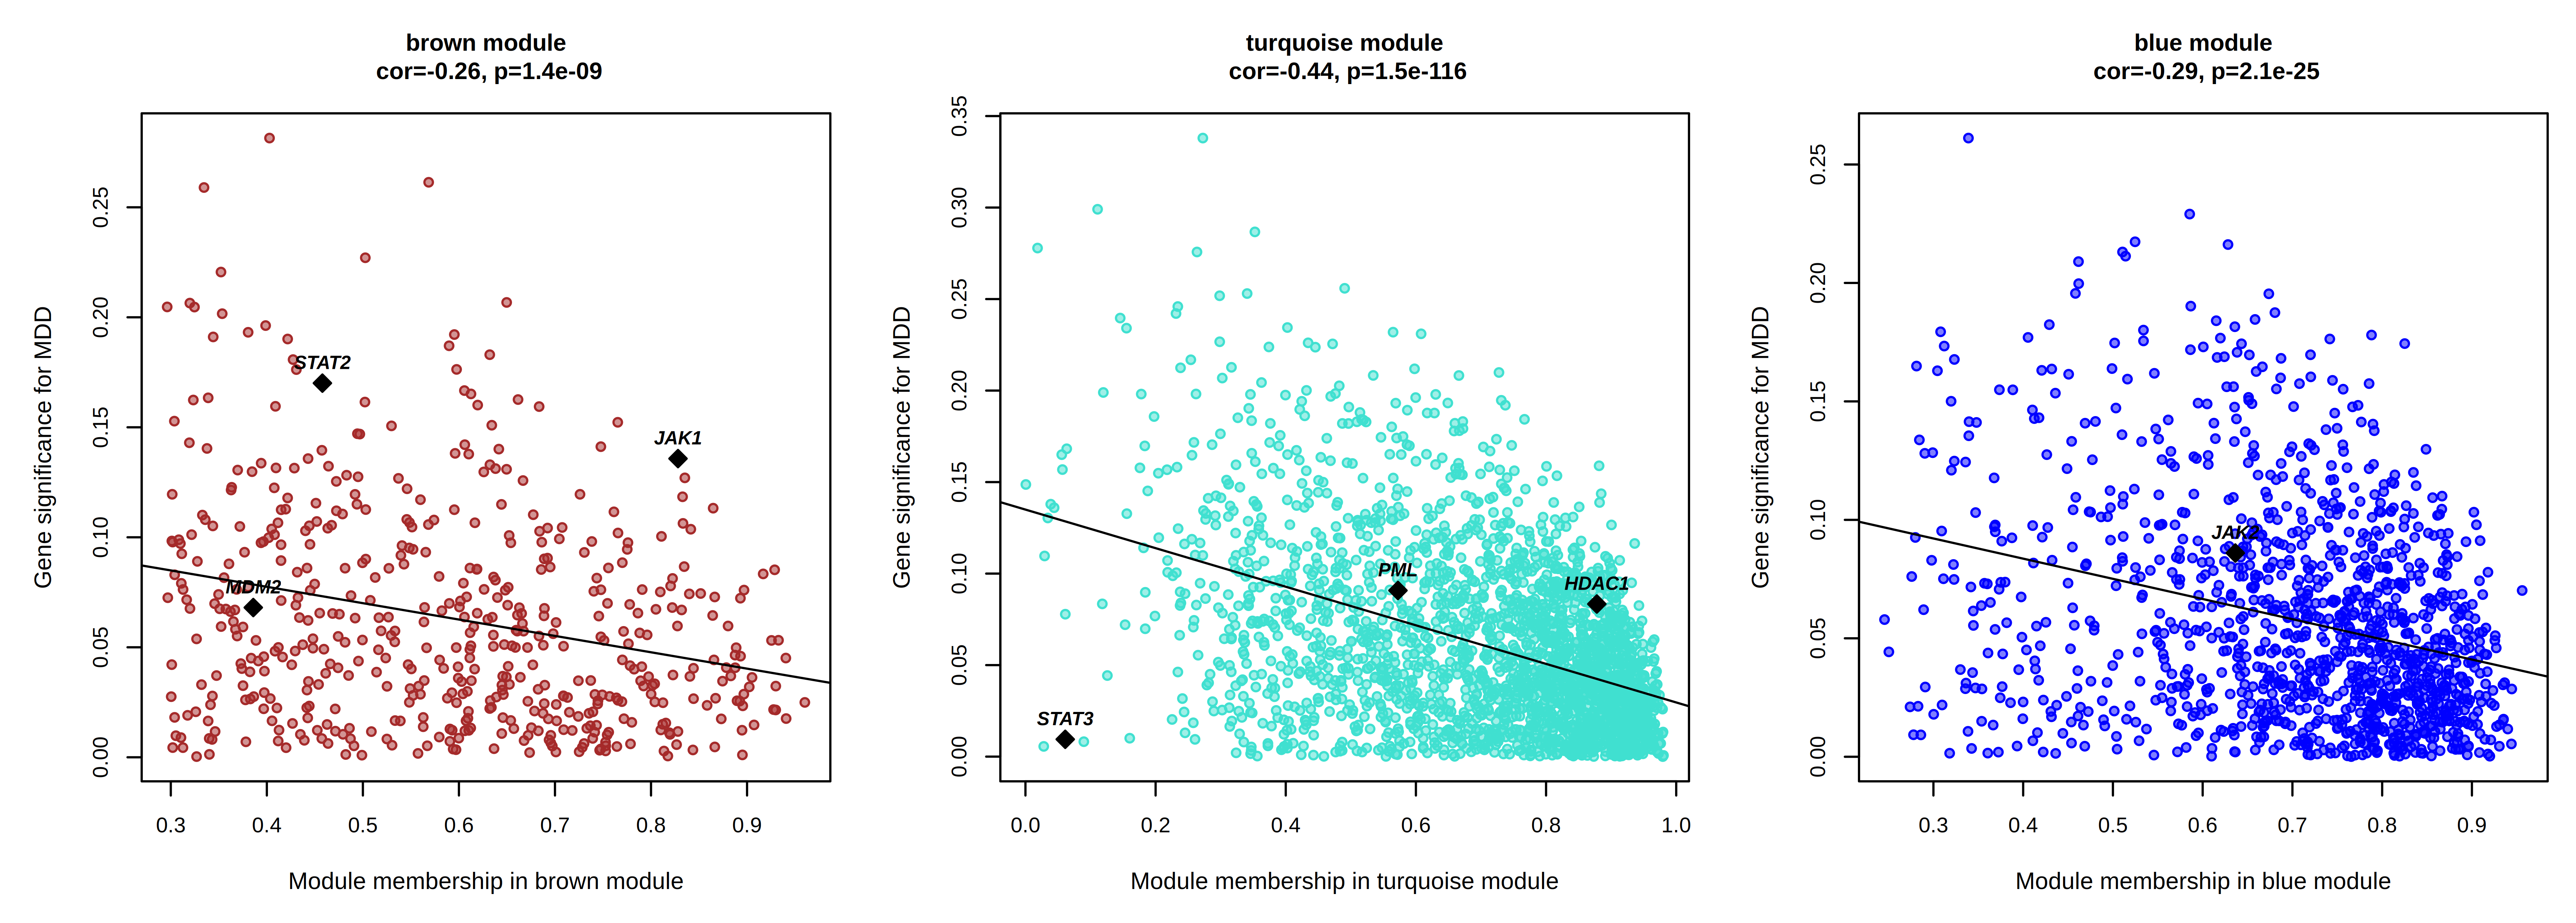

W6_module_significance.png


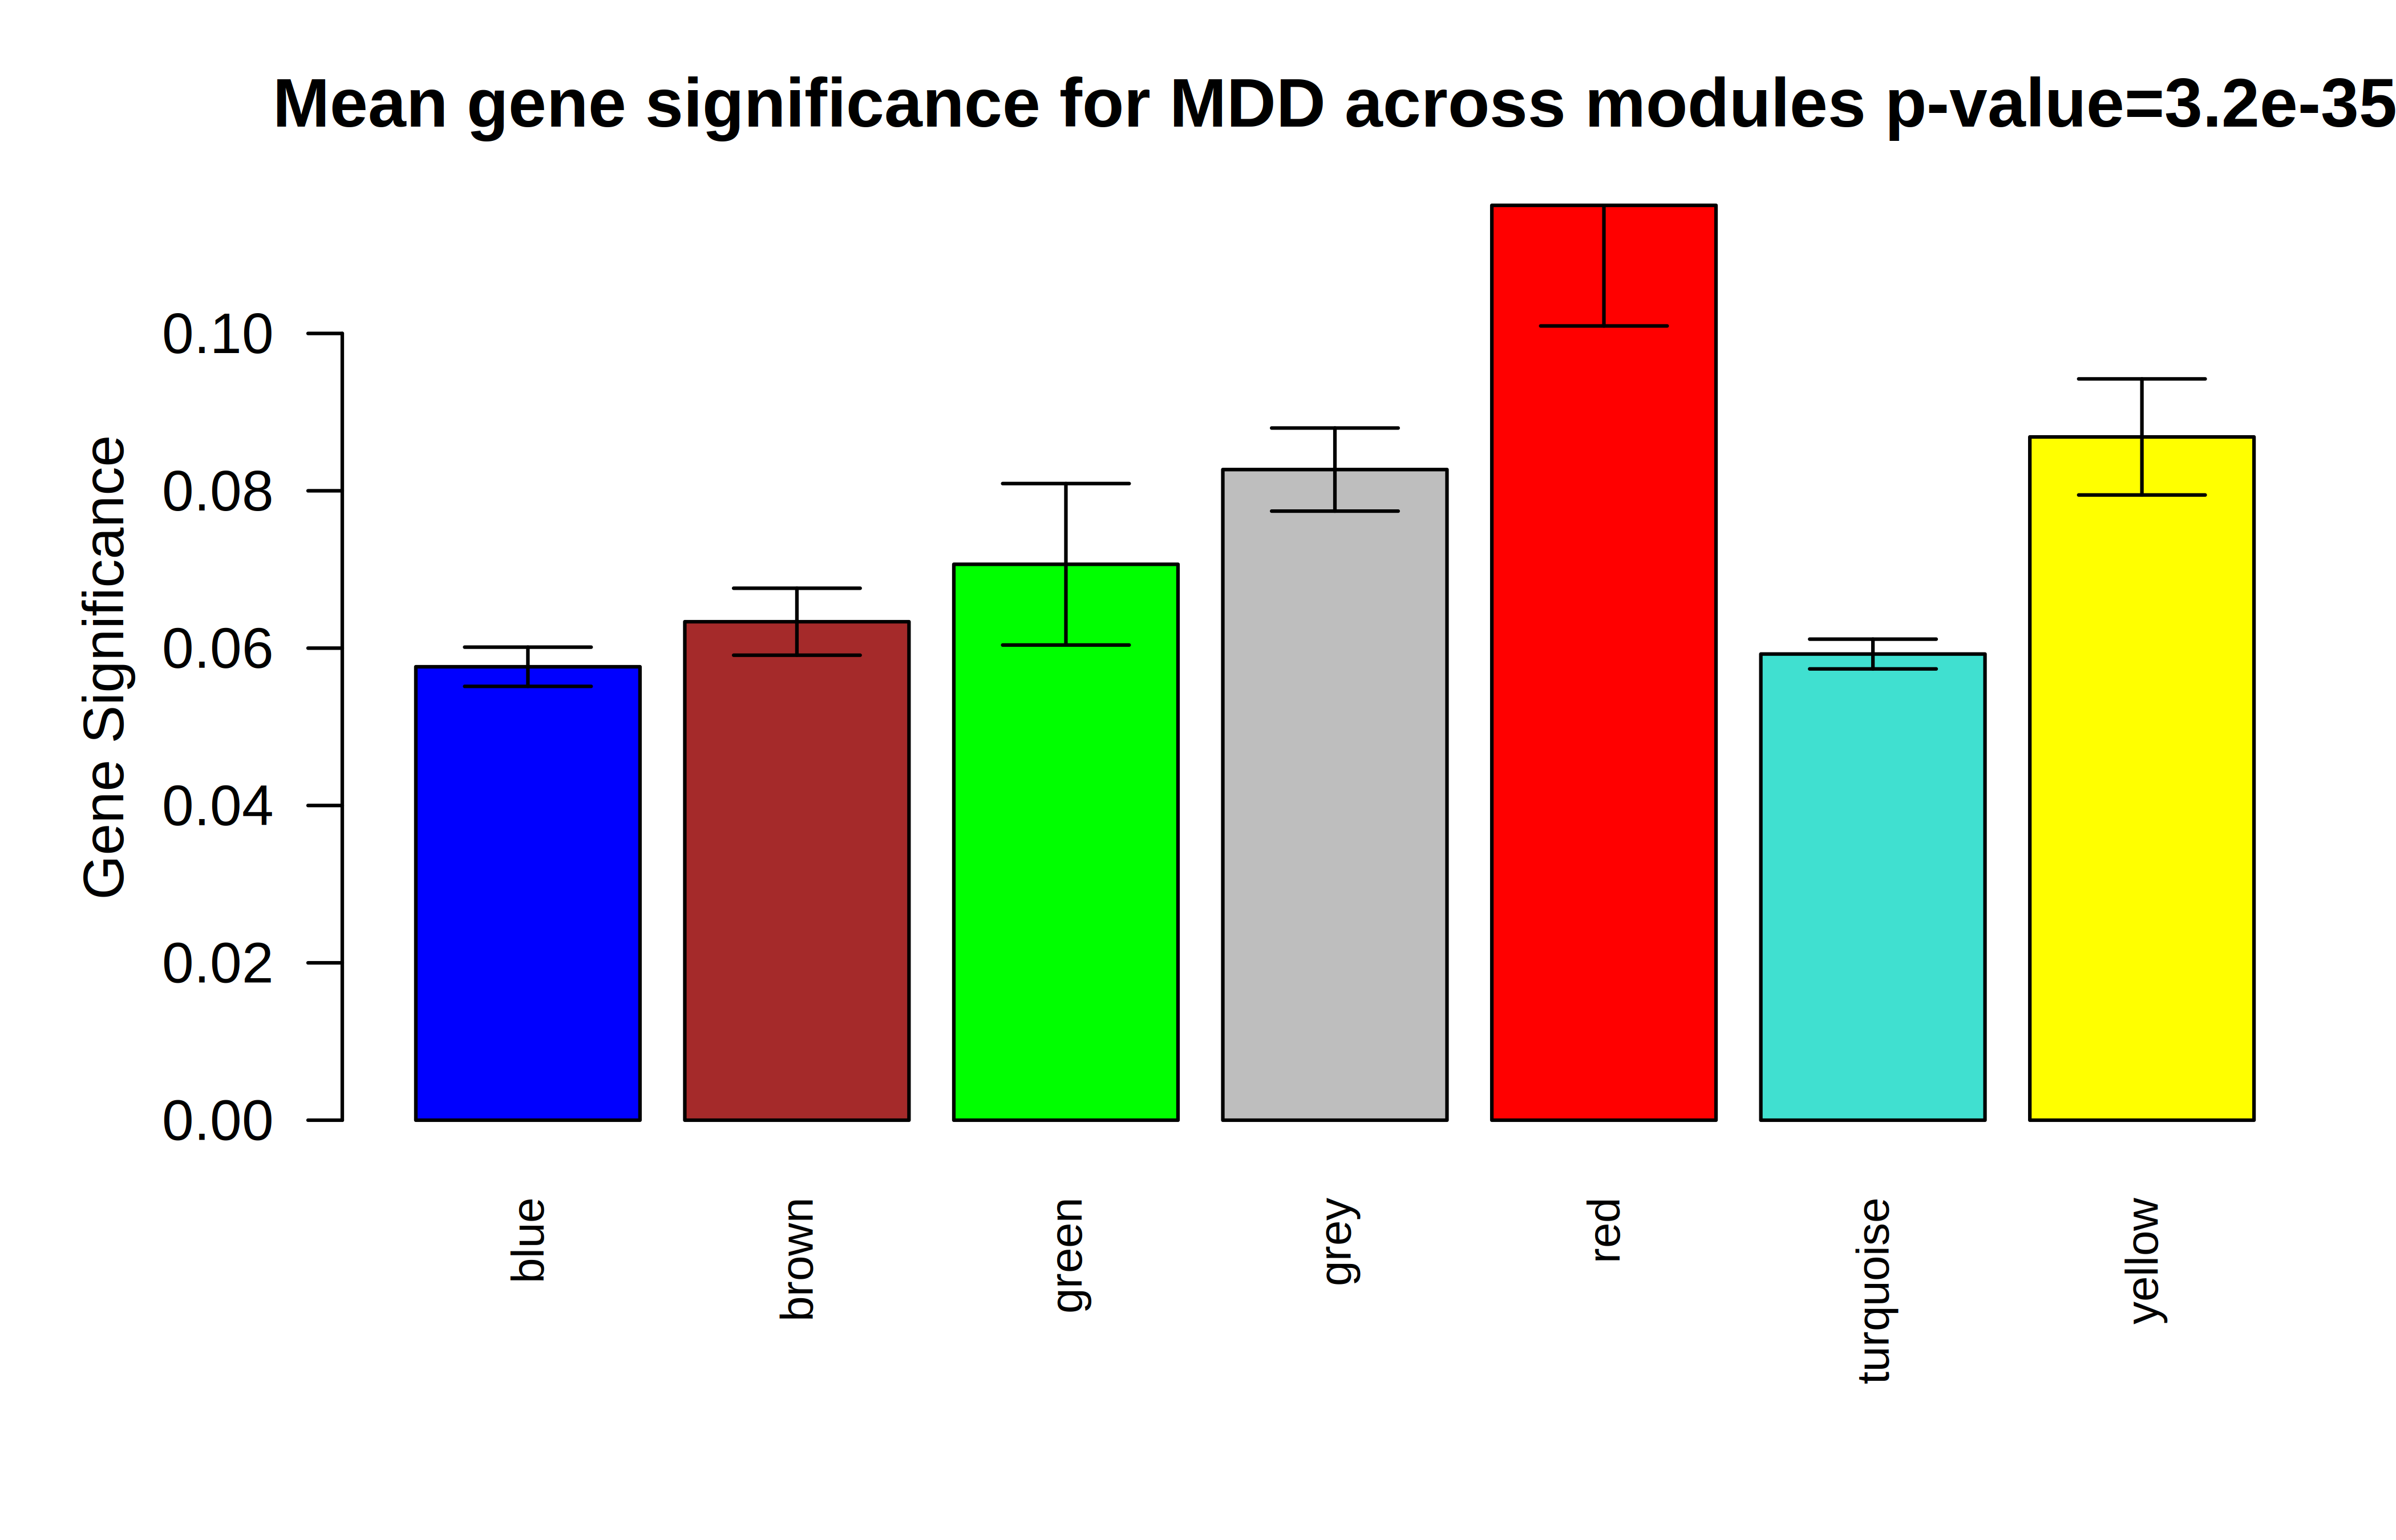

W7_module_preservation_size.png


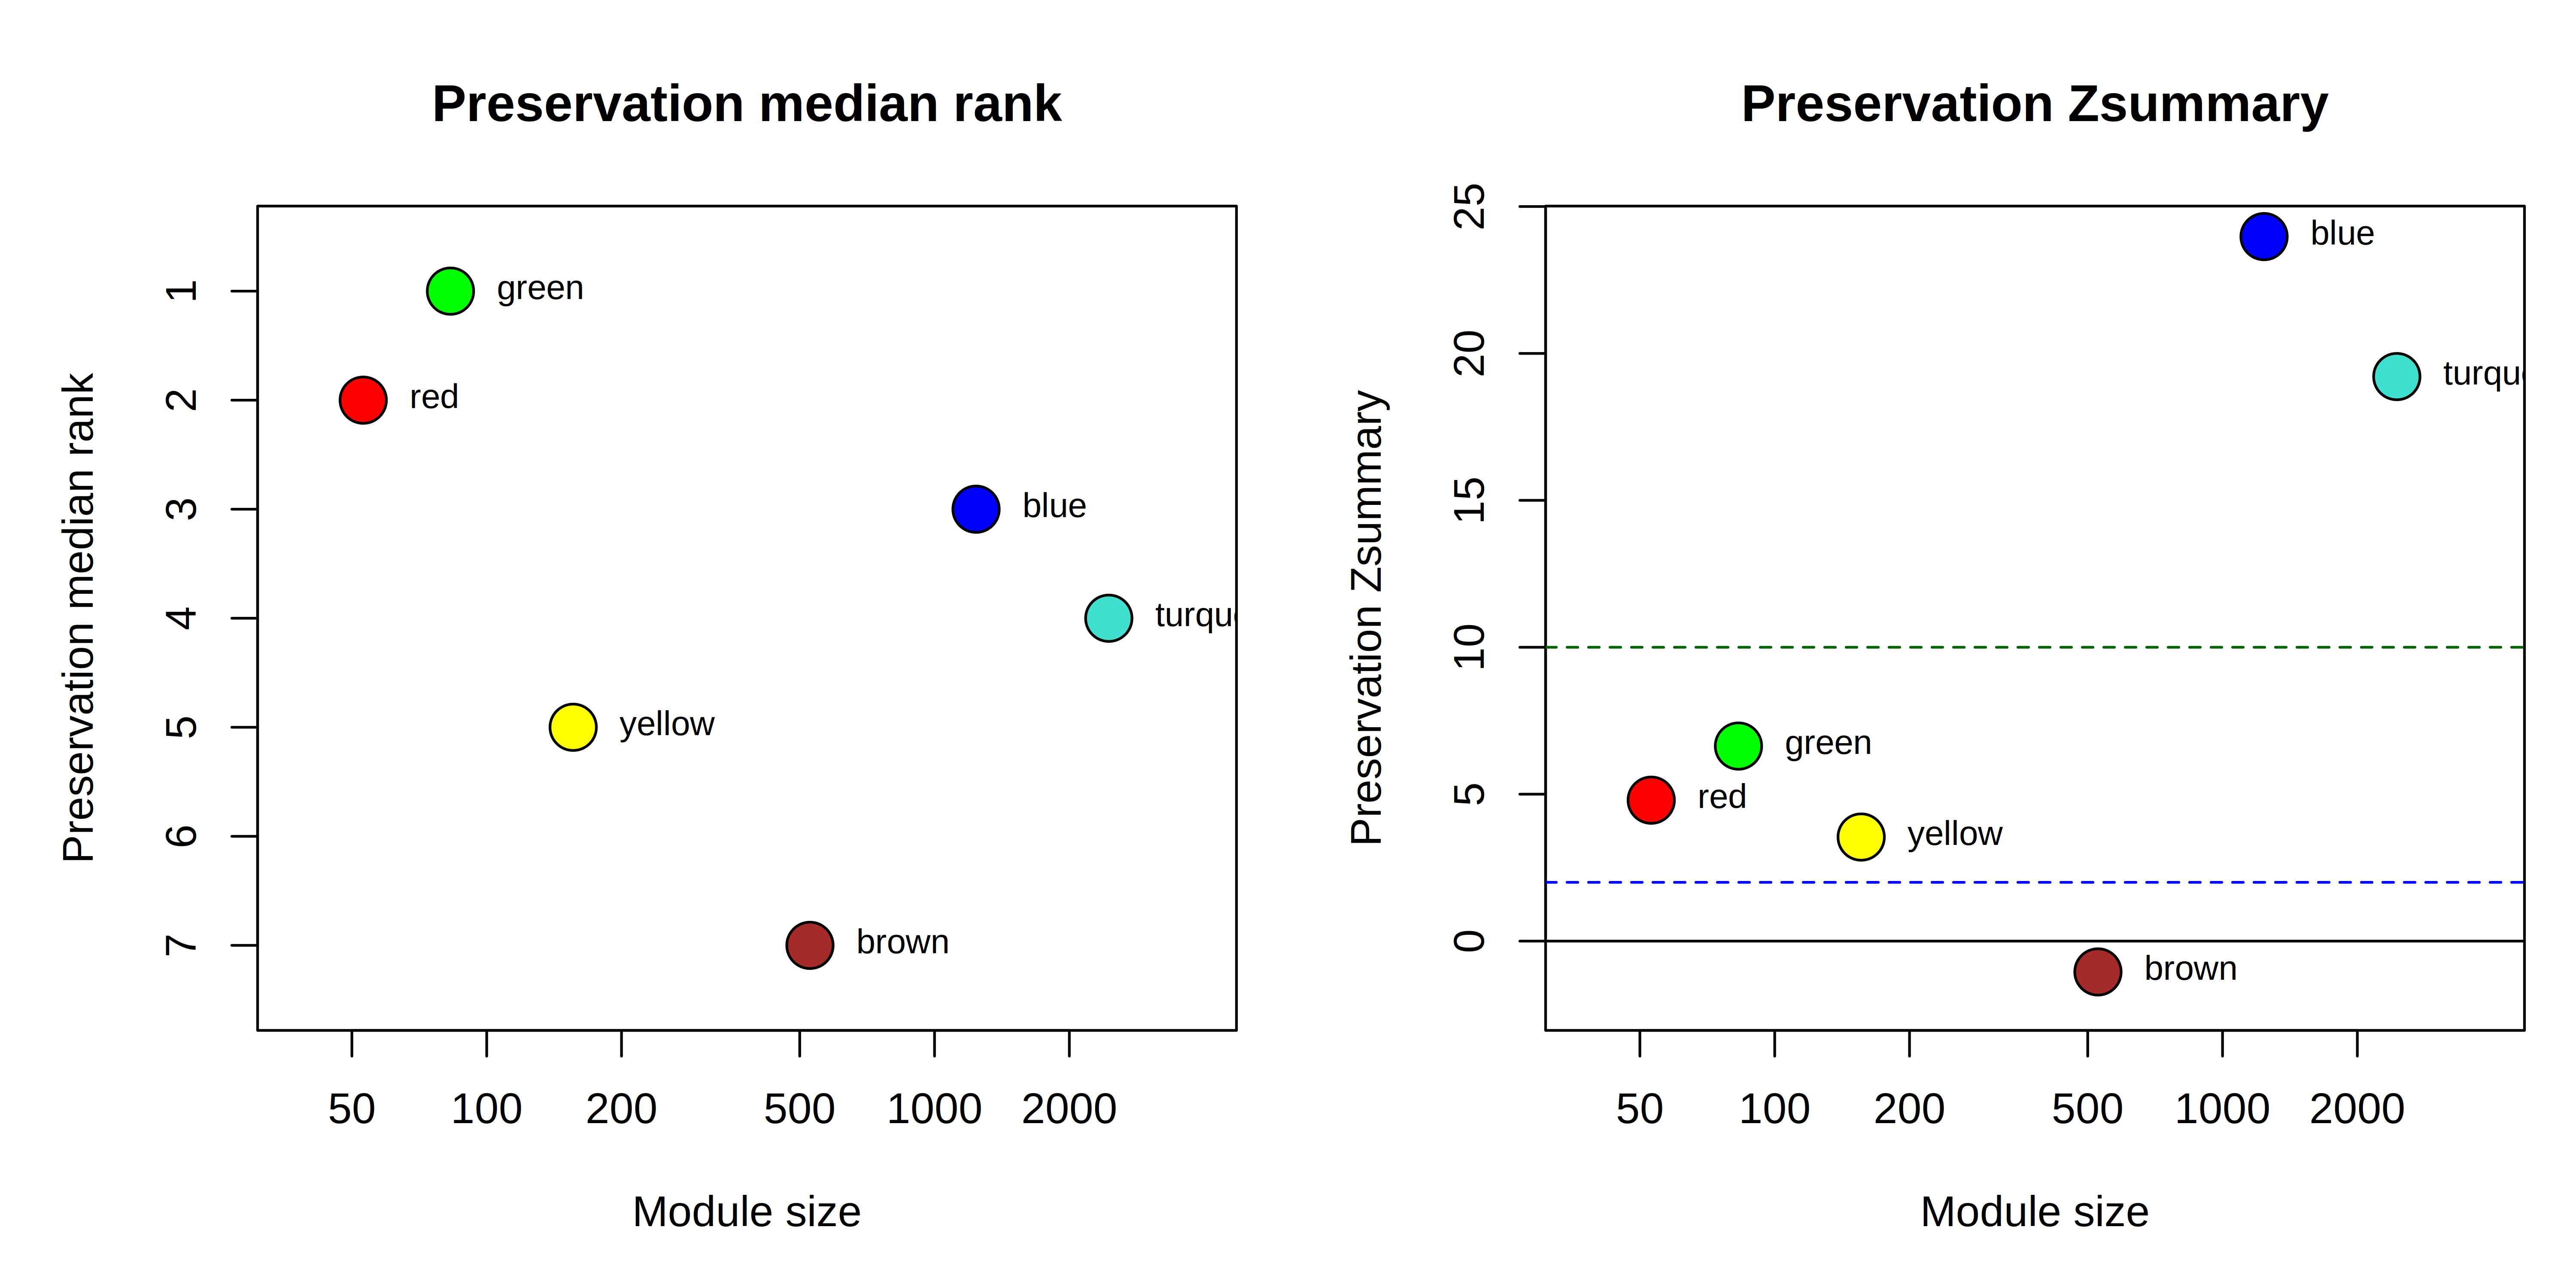

In [ ]:
# ONE CELL: published-style WGCNA figures from the saved Final3 run (~5 min)
from google.colab import drive
drive.mount('/content/drive')

R_CODE = r'''
options(stringsAsFactors = FALSE, warn = 1)
suppressPackageStartupMessages({ library(WGCNA) })
allowWGCNAThreads()
ROOT <- "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
IN   <- paste0(ROOT, "process_datasets_0.08/WGCNA/Final3/")
FIG  <- paste0(IN, "Figures_published_style/")
dir.create(FIG, recursive = TRUE, showWarnings = FALSE)
load(paste0(IN, "WGCNA_final.RData"))
pres <- read.csv(paste0(IN, "Table3_module_preservation.csv"))
HUB  <- c("IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3")

save3 <- function(name, w, h, fun) {
  png(paste0(FIG, name, ".png"), width = w, height = h, units = "in", res = 600); fun(); dev.off()
  pdf(paste0(FIG, name, ".pdf"), width = w, height = h); fun(); dev.off()
  tiff(paste0(FIG, name, ".tiff"), width = w, height = h, units = "in", res = 600, compression = "lzw"); fun(); dev.off()
  cat("saved", name, "\n")
}
MEref  <- orderMEs(moduleEigengenes(datRef, moduleColors)$eigengenes)
MEtest <- moduleEigengenes(datTest, moduleColors)$eigengenes[, colnames(MEref)]
MEnoGrey <- MEref[, colnames(MEref) != "MEgrey", drop = FALSE]

## 1. Sample dendrogram and trait heatmap
for (d in list(list(datRef, yRef, "GSE98793", "MDD", 0.22), list(datTest, yTest, "GSE63878", "PTSD", 0.4))) {
  save3(paste0("W1_sample_dendrogram_trait_", d[[3]]), 10, 5, function() {
    tr <- hclust(dist(d[[1]]), method = "average")
    tc <- numbers2colors(data.frame(x = d[[2]]), signed = FALSE, colors = c("white", "#C0392B"))
    plotDendroAndColors(tr, tc, groupLabels = d[[4]], cex.dendroLabels = d[[5]], hang = 0.03,
                        main = paste0("Sample dendrogram and trait heatmap (", d[[3]], ")"),
                        marAll = c(1, 5, 3, 1))
  })
}

## 2. Module-trait relationships
rM <- cor(MEref, yRef); pM <- corPvalueStudent(rM, length(yRef))
rP <- cor(MEtest, yTest); pP <- corPvalueStudent(rP, length(yTest))
R  <- cbind(rM, rP); P <- cbind(pM, pP)
txt <- matrix(paste0(signif(R, 2), "\n(", signif(P, 1), ")"), nrow = nrow(R))
save3("W2_module_trait_relationships", 6, 0.45 * nrow(R) + 2, function() {
  par(mar = c(6, 9, 3, 3))
  labeledHeatmap(Matrix = R, xLabels = c("MDD (GSE98793)", "PTSD (GSE63878)"),
                 yLabels = colnames(MEref), ySymbols = colnames(MEref), colorLabels = FALSE,
                 colors = blueWhiteRed(50), textMatrix = txt, setStdMargins = FALSE,
                 cex.text = 0.8, zlim = c(-1, 1), main = "Module-trait relationships")
})

## 3. Eigengene dendrogram + adjacency heatmap
save3("W3_eigengene_network", 6, 8, function() {
  plotEigengeneNetworks(orderMEs(cbind(MEnoGrey, MDD = yRef)), "Eigengene dendrogram and adjacency",
                        marDendro = c(0, 4, 2, 0), marHeatmap = c(4, 5, 1, 2),
                        cex.lab = 0.9, xLabelsAngle = 90)
})

## 4. TOM network heatmap (400 random genes)
set.seed(12345)
sel <- sample(ncol(datRef), 400)
dissTOM <- 1 - TOMsimilarityFromExpr(datRef[, sel], power = softPower, networkType = "signed",
                                     TOMType = "signed", verbose = 0)
selTree <- hclust(as.dist(dissTOM), method = "average")
plotTOM <- dissTOM^7; diag(plotTOM) <- NA
save3("W4_TOM_network_heatmap", 7, 7, function() {
  TOMplot(plotTOM, selTree, moduleColors[sel],
          main = "Network heatmap plot (TOM), 400 randomly selected genes")
})

## 5. Module membership vs gene significance
GS <- abs(cor(datRef, yRef))[, 1]
hubMods <- setdiff(unique(moduleColors[intersect(HUB, names(moduleColors))]), "grey")
save3("W5_MM_vs_GS_hub_modules", 4 * length(hubMods), 4.3, function() {
  par(mfrow = c(1, length(hubMods)), mar = c(5, 5, 4, 1))
  for (m in hubMods) {
    g <- names(moduleColors)[moduleColors == m]
    MM <- abs(cor(datRef[, g], MEref[, paste0("ME", m)]))[, 1]
    verboseScatterplot(MM, GS[g], col = m, pch = 21, bg = adjustcolor(m, 0.5), cex = 0.8,
                       xlab = paste("Module membership in", m, "module"),
                       ylab = "Gene significance for MDD", main = paste(m, "module\n"),
                       cex.main = 1, cex.lab = 1, cex.axis = 0.9, abline = TRUE)
    h <- intersect(HUB, g)
    if (length(h)) { points(MM[h], GS[h], pch = 23, bg = "black", cex = 1.3)
                     text(MM[h], GS[h], h, pos = 3, cex = 0.8, font = 4) }
  }
})

## 6. Gene significance across modules
save3("W6_module_significance", 7, 4.5, function() {
  par(mar = c(6, 5, 3, 1))
  plotModuleSignificance(GS, moduleColors, main = "Mean gene significance for MDD across modules",
                         las = 2, cex.names = 0.8)
})

## 7. Module preservation vs module size
real <- pres[!pres$Module %in% c("grey", "gold"), ]
save3("W7_module_preservation_size", 10, 5, function() {
  par(mfrow = c(1, 2), mar = c(5, 5, 4, 1))
  plot(real$ModuleSize, real$medianRank, pch = 21, bg = real$Module, cex = 2.4, log = "x",
       ylim = rev(range(real$medianRank) + c(-0.5, 0.5)), xlim = range(real$ModuleSize) * c(0.7, 1.6),
       xlab = "Module size", ylab = "Preservation median rank", main = "Preservation median rank")
  text(real$ModuleSize, real$medianRank, real$Module, pos = 4, offset = 0.9, cex = 0.8)
  plot(real$ModuleSize, real$Zsummary, pch = 21, bg = real$Module, cex = 2.4, log = "x",
       ylim = range(c(-2, real$Zsummary, 12)), xlim = range(real$ModuleSize) * c(0.7, 1.6),
       xlab = "Module size", ylab = "Preservation Zsummary", main = "Preservation Zsummary")
  text(real$ModuleSize, real$Zsummary, real$Module, pos = 4, offset = 0.9, cex = 0.8)
  abline(h = 0); abline(h = 2, col = "blue", lty = 2); abline(h = 10, col = "darkgreen", lty = 2)
})
cat("\nAll published-style figures saved to:", FIG, "\n"); print(list.files(FIG, pattern = "png$"))
'''

with open("/content/WGCNA_published_figures.R", "w") as f:
    f.write(R_CODE)
import subprocess, sys
proc = subprocess.Popen(["Rscript", "/content/WGCNA_published_figures.R"],
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    sys.stdout.write(line); sys.stdout.flush()
proc.wait()
print("\nFINISHED, exit code:", proc.returncode)

from IPython.display import Image, display
import glob
for f in sorted(glob.glob("/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final3/Figures_published_style/*.png")):
    print(f.split("/")[-1]); display(Image(f, width=750))

In [ ]:
# Build reviewer-ready WGCNA tables (Table 3 + Supplementary) from the Final3 run
import re, os, pandas as pd

OUT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final3/"
TAB = OUT + "Tables/"
os.makedirs(TAB, exist_ok=True)

pres = pd.read_csv(OUT + "Table3_module_preservation.csv")
log  = open(OUT + "run_log.txt").read()
grab = lambda pat, default="NA": (re.search(pat, log).group(1) if re.search(pat, log) else default)

power  = grab(r"Soft power = (\d+)")
r2     = grab(r"signed R\^2 = ([0-9.]+)")
meank  = grab(r"mean connectivity = ([0-9.]+)")
ncom   = grab(r"Genes measured in both datasets[^:]*: (\d+)")
nused  = grab(r"Final matrices: reference \d+ x (\d+)")
ngrey  = grab(r"grey = (\d+)")
fmt_r  = lambda r, q: "" if pd.isna(r) else f"{r:.2f} ({q:.2f})"

# ---------------- Table 3 (main text)
mods = pres[~pres.Module.isin(["grey", "gold"])].sort_values("Zsummary", ascending=False)
gold = pres[pres.Module == "gold"]
rows = []
for _, r in pd.concat([mods, gold]).iterrows():
    rows.append({
        "Module": "gold (random genes)\u2020" if r.Module == "gold" else r.Module,
        "Module size (genes)": int(r.ModuleSize),
        "Zsummary": round(r.Zsummary, 2),
        "Zdensity": round(r.Zdensity, 2),
        "Zconnectivity": round(r.Zconnectivity, 2),
        "Median rank": int(r.medianRank) if r.Module != "gold" else "",
        "Preservation": "Reference" if r.Module == "gold" else
                        ("Strong" if r.Zsummary > 10 else "Moderate" if r.Zsummary > 2 else "Not preserved"),
        "r with MDD (FDR)": fmt_r(r.r_MDD_GSE98793, r.FDR_MDD),
        "r with PTSD (FDR)": fmt_r(r.r_PTSD_GSE63878, r.FDR_PTSD),
    })
t3 = pd.DataFrame(rows)
t3.to_csv(TAB + "Table3_module_preservation_final.csv", index=False, encoding="utf-8-sig")

n_mod = len(mods)
footnote = (
    f"Reference network: GSE98793 (MDD); test network: GSE63878 (PTSD). Modules were detected in the "
    f"reference network from the {nused} genes analysed (the 5,000 most variable of {ncom} genes measured "
    f"on both platforms, plus the hub genes and shared DEGs) using a signed network (soft-thresholding power "
    f"{power}, signed R\u00b2 = {r2}), minimum module size 30, deepSplit 2 and merge cut height 0.25. "
    f"Preservation was computed on the same genes with 200 permutations; module sizes are therefore those of "
    f"the modules as detected. Zsummary > 10, strong; 2\u201310, moderate; < 2, not preserved. A lower median rank "
    f"indicates stronger preservation independent of module size. r: correlation of the module eigengene with "
    f"disease status (FDR, Benjamini\u2013Hochberg). The grey set ({ngrey} unassigned genes) is not a module and "
    f"is omitted. \u2020The gold module is a random sample of 1,000 genes used as a size-matched reference."
)
open(TAB + "Table3_footnote.txt", "w").write(footnote)

# ---------------- Supplementary: WGCNA parameters
params = pd.DataFrame([
    ("Reference network", "GSE98793 (MDD; GPL570; 192 samples: 128 MDD, 64 controls)"),
    ("Test network", "GSE63878 (PTSD; GPL6244; 96 samples: 48 PTSD, 48 controls)"),
    ("Input data", "Full gene-level matrices without DEG or label-based filtering; probes averaged per gene symbol"),
    ("Genes measured on both platforms", ncom),
    ("Genes analysed", f"{nused} (5,000 most variable in the reference + hub genes and shared DEGs)"),
    ("Network type", "Signed; Pearson correlation; signed TOM"),
    ("Soft-thresholding power", f"{power} (lowest power with signed R\u00b2 \u2265 0.85; R\u00b2 = {r2}; mean connectivity = {meank})"),
    ("Module detection", "blockwiseModules, single block; minModuleSize = 30; deepSplit = 2; mergeCutHeight = 0.25"),
    ("Modules detected", f"{n_mod} (sizes {int(mods.ModuleSize.min())}\u2013{int(mods.ModuleSize.max())} genes); {ngrey} unassigned (grey)"),
    ("Module preservation", "modulePreservation; reference GSE98793, test GSE63878; 200 permutations; Zsummary and medianRank"),
    ("Random seed", "12345"),
], columns=["Parameter", "Setting"])
params.to_csv(TAB + "S_WGCNA_parameters.csv", index=False, encoding="utf-8-sig")

# ---------------- Supplementary: hub / shared genes in modules
f = OUT + "S_hub_and_shared_genes_module_membership.csv"
if os.path.exists(f):
    h = pd.read_csv(f)
    hs = pd.DataFrame({
        "Gene": h.Gene, "Gene set": h.Set, "Module (GSE98793)": h.Module,
        "kME GSE98793": h.kME_ref.round(2), "kME GSE63878": h.kME_test.round(2),
        "GS MDD (p)": [f"{a:.2f} ({b:.3f})" for a, b in zip(h.GS_MDD, h.p_GS_MDD)],
        "GS PTSD (p)": [f"{a:.2f} ({b:.3f})" for a, b in zip(h.GS_PTSD, h.p_GS_PTSD)]})
    hs.to_csv(TAB + "S_hub_shared_gene_module_membership.csv", index=False, encoding="utf-8-sig")

# ---------------- one Excel workbook with everything
with pd.ExcelWriter(TAB + "WGCNA_tables_all.xlsx") as xw:
    t3.to_excel(xw, sheet_name="Table3", index=False)
    pd.DataFrame({"Footnote": [footnote]}).to_excel(xw, sheet_name="Table3_footnote", index=False)
    params.to_excel(xw, sheet_name="S_WGCNA_parameters", index=False)
    if os.path.exists(f): hs.to_excel(xw, sheet_name="S_hub_gene_modules", index=False)

pd.set_option("display.width", 200)
print(t3.to_string(index=False)); print("\nFOOTNOTE:\n" + footnote); print("\n", params.to_string(index=False))
print("\nSaved to:", TAB, os.listdir(TAB))

              Module  Module size (genes)  Zsummary  Zdensity  Zconnectivity Median rank  Preservation r with MDD (FDR) r with PTSD (FDR)
                blue                 1238     23.98     22.78          25.18           3        Strong     -0.03 (0.94)       0.05 (0.82)
           turquoise                 2450     19.21     11.34          27.08           4        Strong      0.01 (0.94)       0.03 (0.82)
               green                   83      6.64      6.20           7.08           1      Moderate      0.06 (0.78)       0.02 (0.82)
                 red                   53      4.80      4.02           5.57           2      Moderate      0.15 (0.11)      -0.09 (0.82)
              yellow                  156      3.54     -0.17           7.26           5      Moderate      0.11 (0.30)      -0.02 (0.82)
               brown                  527     -1.05     -5.98           3.89           7 Not preserved     -0.01 (0.94)      -0.06 (0.82)
gold (random genes)†              

#Final Code for Overral check

In [ ]:
# ===== FINAL REVIEWER #2 CONCERN #8 PIPELINE (one cell; ~2-4 h) =====
# Paste this whole cell into ONE empty Colab cell and run. Output: WGCNA/Final_Reviewer8/
from google.colab import drive
drive.mount('/content/drive')

R_CODE = r'''
## ======================================================================================
## FINAL WGCNA PIPELINE FOR REVIEWER #2, CONCERN #8  (run once, first to last)
##   1. Main analysis    : reference GSE98793 (MDD) -> test GSE63878 (PTSD), 5,000 genes, 200 permutations
##   2. Reverse check    : reference GSE63878 (PTSD) -> test GSE98793 (MDD), 200 permutations
##   3. Sensitivity      : gene-set size 3,000 and 8,000 (100 permutations)
##   4. Figures + tables : main Fig 4, published-style WGCNA figures, supplementary figures
## Output: WGCNA/Final_Reviewer8/ (01_results, 03_figures_main, 04_figures_supplementary, 05_logs)
## ======================================================================================
options(stringsAsFactors = FALSE, warn = 1)
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager", repos = "https://cloud.r-project.org")
for (p in c("impute", "preprocessCore", "GO.db", "AnnotationDbi"))
  if (!requireNamespace(p, quietly = TRUE)) BiocManager::install(p, ask = FALSE, update = FALSE)
for (p in c("WGCNA", "data.table", "ggplot2", "patchwork", "png", "scales"))
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p, repos = "https://cloud.r-project.org")
suppressPackageStartupMessages({
  library(WGCNA); library(data.table); library(ggplot2); library(patchwork)
  library(png); library(grid); library(scales)
})
allowWGCNAThreads()

## ------------------------------------------------------------------ CONFIG
ROOT <- "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
SM   <- paste0(ROOT, "process_datasets_0.08/WGCNA/")
OUT  <- paste0(ROOT, "process_datasets_0.08/WGCNA/Final_Reviewer8/")
RES  <- paste0(OUT, "01_results/"); FIGM <- paste0(OUT, "03_figures_main/")
FIGS <- paste0(OUT, "04_figures_supplementary/"); LOGD <- paste0(OUT, "05_logs/")
for (d in c(RES, FIGM, FIGS, LOGD)) dir.create(d, recursive = TRUE, showWarnings = FALSE)

SEARCH_DIRS <- paste0(ROOT, c("process_datasets_0.08/datasets/", "Final_validation/"))
MIN_COLS <- 15000; N_GENES <- 5000; R2_CUT <- 0.85; MIN_MODULE <- 30; DEEP_SPLIT <- 2
MERGE_CUT <- 0.25; N_PERM <- 200; N_PERM_SENS <- 100; SENS_SIZES <- c(3000, 8000); SEED <- 12345
RUN_REVERSE <- TRUE; RUN_SENSITIVITY <- TRUE
HUB <- c("IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3")
SHARED <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B","CYP2U1","IGF1R",
            "GALNT11","HGF","DKKL1","GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

log_file <- file(paste0(LOGD, "run_log.txt"), open = "wt")
say <- function(...) { msg <- paste0(...); cat(msg, "\n"); cat(msg, "\n", file = log_file); flush(log_file) }
say("Started: ", format(Sys.time()))

## ------------------------------------------------------------------ DATA
pick_full <- function(gse) {
  for (d in SEARCH_DIRS) {
    f <- paste0(d, gse, "_matrix_Transpose_labeled.csv")
    if (file.exists(f)) {
      n <- ncol(fread(f, nrows = 1)) - 1
      say(sprintf("  %s: %d gene columns %s", f, n, ifelse(n >= MIN_COLS, "-> FULL, used", "-> filtered, skipped")))
      if (n >= MIN_COLS) return(f)
    }
  }
  stop("No full (unfiltered) matrix found for ", gse)
}
sample_ids <- function(raw, gse) {
  ex <- fread(paste0(SM, gse, "_expression.csv"), data.table = FALSE)
  ids <- colnames(ex)[-1]; E <- as.matrix(ex[, -1]); storage.mode(E) <- "numeric"
  lab <- read.csv(paste0(SM, gse, "_labels.csv"))
  fallback <- paste0(gse, "_S", seq_len(nrow(raw)))
  if (length(ids) != nrow(raw)) return(fallback)
  cand <- setdiff(colnames(raw), "target"); cand <- cand[!grepl("\\.[0-9]+$", cand)]
  set.seed(1); cand <- sample(cand, min(30, length(cand)))
  hit <- vapply(cand, function(g) { x <- suppressWarnings(as.numeric(raw[[g]])); if (anyNA(x)) return(NA)
    any(rowSums(abs(sweep(E, 2, x))) < 1e-3, na.rm = TRUE) }, logical(1))
  rate <- mean(hit, na.rm = TRUE)
  lab_ok <- isTRUE(all(as.integer(lab$Label[match(ids, lab$Sample)] == 1) == as.integer(raw$target == 1)))
  say(sprintf("  %s: %.0f%% of tested genes match the series matrix in sample order; labels identical: %s", gse, 100 * rate, lab_ok))
  if (rate >= 0.8 && lab_ok) ids else fallback
}
read_gene_matrix <- function(gse, name) {
  path <- pick_full(gse)
  df <- fread(path, data.table = FALSE, check.names = FALSE)
  ids <- sample_ids(df, gse); y <- as.integer(df$target == 1)
  X <- df[, setdiff(colnames(df), "target"), drop = FALSE]
  X[] <- lapply(X, function(v) suppressWarnings(as.numeric(v)))
  X <- X[, colSums(!is.na(X)) > 0, drop = FALSE]
  sym <- sub("\\.[0-9]+$", "", colnames(X)); keep <- sym != "" & !grepl("///", sym, fixed = TRUE)
  X <- X[, keep, drop = FALSE]; sym <- sym[keep]; M <- as.matrix(X)
  logged <- max(M, na.rm = TRUE) > 50; if (logged) M <- log2(pmax(M, 0) + 1)
  idx <- split(seq_along(sym), sym)
  G <- sapply(idx, function(i) if (length(i) == 1) M[, i] else rowMeans(M[, i, drop = FALSE], na.rm = TRUE))
  for (j in seq_len(ncol(G))) { v <- G[, j]; v[is.na(v)] <- median(v, na.rm = TRUE); G[, j] <- v }
  rownames(G) <- ids
  say(sprintf("%s: %d samples (case %d / control %d); %d probes -> %d genes; log2 applied %s; file %s",
              name, nrow(G), sum(y), sum(1 - y), ncol(X), ncol(G), logged, path))
  list(X = as.data.frame(G), y = y)
}
say("Reading data:")
MDD  <- read_gene_matrix("GSE98793", "GSE98793 (MDD)")
PTSD <- read_gene_matrix("GSE63878", "GSE63878 (PTSD)")

## ------------------------------------------------------------------ CORE FUNCTION
run_wgcna <- function(R, Tt, refName, testName, N, perms, tag) {
  say("\n=== ", tag, ": reference ", refName, " -> test ", testName, "; top ", N, " genes; ", perms, " permutations")
  common <- intersect(colnames(R$X), colnames(Tt$X))
  vR <- apply(R$X[, common], 2, var); vT <- apply(Tt$X[, common], 2, var)
  common <- common[vR > 0 & vT > 0]
  top <- names(sort(vR[common], decreasing = TRUE))[seq_len(min(N, length(common)))]
  genes <- c(top, setdiff(intersect(c(HUB, SHARED), common), top))
  dR <- R$X[, genes]; dT <- Tt$X[, genes]
  gR <- goodSamplesGenes(dR, verbose = 0); gT <- goodSamplesGenes(dT, verbose = 0)
  okG <- gR$goodGenes & gT$goodGenes
  dR <- dR[gR$goodSamples, okG]; dT <- dT[gT$goodSamples, okG]
  yR <- R$y[gR$goodSamples]; yT <- Tt$y[gT$goodSamples]
  powers <- 1:20
  sft <- pickSoftThreshold(dR, powerVector = powers, networkType = "signed", verbose = 0)
  fit <- -sign(sft$fitIndices$slope) * sft$fitIndices$SFT.R.sq
  ok <- which(fit >= R2_CUT); pw <- if (length(ok)) powers[min(ok)] else powers[which.max(fit)]
  net <- blockwiseModules(dR, power = pw, networkType = "signed", TOMType = "signed", corType = "pearson",
                          maxBlockSize = ncol(dR) + 10, minModuleSize = MIN_MODULE, deepSplit = DEEP_SPLIT,
                          mergeCutHeight = MERGE_CUT, reassignThreshold = 0, pamRespectsDendro = FALSE,
                          numericLabels = TRUE, randomSeed = SEED, saveTOMs = FALSE, verbose = 0)
  mc <- labels2colors(net$colors); names(mc) <- colnames(dR)
  ms <- sort(table(mc), decreasing = TRUE); nonGrey <- ms[names(ms) != "grey"]
  MEr <- orderMEs(moduleEigengenes(dR, mc)$eigengenes)
  MEt <- moduleEigengenes(dT, mc)$eigengenes[, colnames(MEr)]
  cr <- cor(MEr, yR)[, 1]; ct <- cor(MEt, yT)[, 1]
  pr <- corPvalueStudent(cr, length(yR)); pt <- corPvalueStudent(ct, length(yT))
  trait <- data.frame(Module = sub("^ME", "", colnames(MEr)), Size = as.integer(ms[sub("^ME", "", colnames(MEr))]),
                      r_ref = cr, p_ref = pr, FDR_ref = p.adjust(pr, "BH"),
                      r_test = ct, p_test = pt, FDR_test = p.adjust(pt, "BH"))
  mp <- modulePreservation(setNames(list(list(data = dR), list(data = dT)), c(refName, testName)),
                           setNames(list(mc), refName), referenceNetworks = 1, testNetworks = 2,
                           networkType = "signed", corFnc = "cor", nPermutations = perms,
                           maxModuleSize = max(nonGrey), randomSeed = SEED, quickCor = 0, verbose = 0)
  obs <- cbind(mp$quality$observed[[1]][[2]][, -1, drop = FALSE], mp$preservation$observed[[1]][[2]][, -1, drop = FALSE])
  Z   <- cbind(mp$quality$Z[[1]][[2]][, -1, drop = FALSE], mp$preservation$Z[[1]][[2]][, -1, drop = FALSE])
  pres <- data.frame(Module = rownames(Z), ModuleSize = mp$preservation$Z[[1]][[2]]$moduleSize,
                     Zsummary = Z[, "Zsummary.pres"], Zdensity = Z[, "Zdensity.pres"],
                     Zconnectivity = Z[, "Zconnectivity.pres"], medianRank = obs[, "medianRank.pres"])
  pres$Interpretation <- ifelse(pres$Zsummary > 10, "Strong", ifelse(pres$Zsummary > 2, "Moderate", "Low/none"))
  pres <- merge(pres, trait[, c("Module", "r_ref", "FDR_ref", "r_test", "FDR_test")], by = "Module", all.x = TRUE)
  pres <- pres[order(-pres$Zsummary), ]
  real <- pres[!pres$Module %in% c("grey", "gold"), ]
  summ <- data.frame(Analysis = tag, Reference = refName, Test = testName, Genes_common = length(common),
                     Genes_analysed = ncol(dR), Power = pw, Signed_R2 = round(fit[powers == pw], 3),
                     Modules = length(nonGrey), Smallest_module = min(nonGrey), Largest_module = max(nonGrey),
                     Grey_genes = ifelse("grey" %in% names(ms), ms[["grey"]], 0), Permutations = perms,
                     Strong = sum(real$Zsummary > 10), Moderate = sum(real$Zsummary > 2 & real$Zsummary <= 10),
                     Not_preserved = sum(real$Zsummary <= 2),
                     Gold_Zsummary = round(pres$Zsummary[pres$Module == "gold"], 2),
                     Modules_FDR05_reference_trait = sum(trait$FDR_ref < 0.05 & trait$Module != "grey"),
                     Modules_FDR05_test_trait = sum(trait$FDR_test < 0.05 & trait$Module != "grey"))
  say(sprintf("  power %d (R2 %.3f); %d modules (%d-%d genes); strong %d, moderate %d, not preserved %d; trait-associated modules ref %d / test %d",
              pw, fit[powers == pw], length(nonGrey), min(nonGrey), max(nonGrey), summ$Strong, summ$Moderate,
              summ$Not_preserved, summ$Modules_FDR05_reference_trait, summ$Modules_FDR05_test_trait))
  list(dR = dR, dT = dT, yR = yR, yT = yT, sft = sft, fit = fit, power = pw, net = net, mc = mc, ms = ms,
       MEr = MEr, MEt = MEt, trait = trait, pres = pres, mp = mp, summ = summ, ncommon = length(common))
}

## ------------------------------------------------------------------ 1. MAIN ANALYSIS
M <- run_wgcna(MDD, PTSD, "GSE98793", "GSE63878", N_GENES, N_PERM, "Main")
datRef <- M$dR; datTest <- M$dT; yRef <- M$yR; yTest <- M$yT; net <- M$net
moduleColors <- M$mc; modSize <- M$ms; softPower <- M$power; MEref <- M$MEr; MEtest <- M$MEt
sftTab <- cbind(M$sft$fitIndices, signedR2 = M$fit)
trait <- with(M$trait, data.frame(Module, Size, r_MDD_GSE98793 = r_ref, p_MDD = p_ref, FDR_MDD = FDR_ref,
                                  r_PTSD_GSE63878 = r_test, p_PTSD = p_test, FDR_PTSD = FDR_test))
pres <- M$pres; names(pres)[names(pres) == "r_ref"] <- "r_MDD_GSE98793"; names(pres)[names(pres) == "FDR_ref"] <- "FDR_MDD"
names(pres)[names(pres) == "r_test"] <- "r_PTSD_GSE63878"; names(pres)[names(pres) == "FDR_test"] <- "FDR_PTSD"
pres$Note <- ifelse(pres$Module == "grey", "unassigned genes (not a module)",
                    ifelse(pres$Module == "gold", "random-gene reference (gold)", ""))

kmeR <- signedKME(datRef, MEref); kmeT <- signedKME(datTest, MEtest)
gsR <- cor(datRef, yRef); gsT <- cor(datTest, yTest)
hub <- do.call(rbind, lapply(intersect(unique(c(HUB, SHARED)), colnames(datRef)), function(g) {
  m <- moduleColors[[g]]; col <- paste0("kME", m)
  data.frame(Gene = g, Set = ifelse(g %in% HUB & g %in% SHARED, "hub + shared DEG", ifelse(g %in% HUB, "hub (network)", "shared DEG")),
             Module = m, kME_ref = kmeR[g, col], kME_test = kmeT[g, col],
             GS_MDD = gsR[g, 1], p_GS_MDD = corPvalueStudent(gsR[g, 1], length(yRef)),
             GS_PTSD = gsT[g, 1], p_GS_PTSD = corPvalueStudent(gsT[g, 1], length(yTest)))
}))
write.csv(sftTab, paste0(RES, "S_soft_threshold_table.csv"), row.names = FALSE)
write.csv(data.frame(Module = names(modSize), Size = as.integer(modSize)), paste0(RES, "S_module_sizes.csv"), row.names = FALSE)
write.csv(data.frame(Gene = names(moduleColors), Module = moduleColors), paste0(RES, "S_gene_module_assignment.csv"), row.names = FALSE)
write.csv(trait, paste0(RES, "S_module_trait_correlation.csv"), row.names = FALSE)
write.csv(pres, paste0(RES, "Table3_module_preservation.csv"), row.names = FALSE)
write.csv(hub, paste0(RES, "S_hub_and_shared_genes_module_membership.csv"), row.names = FALSE)
summary_rows <- M$summ
write.csv(summary_rows, paste0(RES, "S_analysis_summary.csv"), row.names = FALSE)
save(net, moduleColors, datRef, datTest, yRef, yTest, softPower, file = paste0(RES, "WGCNA_main.RData"))
mp_main <- M$mp; save(mp_main, file = paste0(RES, "WGCNA_main_preservation.RData")); rm(M); gc()

## ------------------------------------------------------------------ 2. FIGURES (main analysis)
BS <- 8
theme_pub <- theme_classic(base_size = BS) +
  theme(plot.title = element_text(face = "bold", size = BS + 1, hjust = 0.5), axis.text = element_text(colour = "black"),
        axis.title = element_text(face = "bold"), legend.title = element_text(face = "bold"),
        legend.key.size = unit(0.35, "cm"), plot.margin = margin(4, 6, 4, 6))
modcol <- function(m) ifelse(m == "gold", "#D4AF37", ifelse(m == "grey", "grey70", m))
pfmt <- function(p) ifelse(p < 0.001, "p<0.001", sprintf("p=%.2f", p))
save3 <- function(dir, name, w, h, fun) {
  png(paste0(dir, name, ".png"), width = w, height = h, units = "in", res = 600); fun(); dev.off()
  pdf(paste0(dir, name, ".pdf"), width = w, height = h); fun(); dev.off()
  tiff(paste0(dir, name, ".tiff"), width = w, height = h, units = "in", res = 600, compression = "lzw"); fun(); dev.off()
}
as_panel <- function(dir, name, fun, w, h) {
  save3(dir, name, w, h, fun); wrap_elements(full = rasterGrob(readPNG(paste0(dir, name, ".png")), interpolate = TRUE))
}
tree_fun <- function(dat, y, title, cexLab) function() {
  tr <- hclust(dist(dat), method = "average")
  plotDendroAndColors(tr, ifelse(y == 1, "#C0392B", "#2E86C1"), groupLabels = "Status", dendroLabels = NULL,
                      cex.dendroLabels = cexLab, hang = 0.03, cex.colorLabels = 0.8, cex.main = 1,
                      main = title, marAll = c(1, 5, 3, 1))
}
pA <- as_panel(FIGM, "Fig4A_sample_clustering_GSE98793",
               tree_fun(datRef, yRef, "GSE98793 sample clustering (red = MDD, blue = control)", 0.22), 9, 4.5)
save3(FIGS, "FigS_sample_clustering_GSE63878", 9, 4.5,
      tree_fun(datTest, yTest, "GSE63878 sample clustering (red = PTSD, blue = control)", 0.4))
pB <- as_panel(FIGM, "Fig4B_gene_dendrogram", function() {
  plotDendroAndColors(net$dendrograms[[1]], moduleColors[net$blockGenes[[1]]], "Module", dendroLabels = FALSE,
                      hang = 0.03, addGuide = TRUE, guideHang = 0.05, cex.colorLabels = 0.8, cex.main = 1,
                      marAll = c(1, 5, 3, 1),
                      main = sprintf("GSE98793 gene dendrogram (%d genes, power %d)", ncol(datRef), softPower))
}, 5.6, 3.9)

pres_bar <- function(p, title) {
  pc <- p[p$Module != "grey", ]; pc <- pc[order(-pc$Zsummary), ]
  lab <- ifelse(pc$Module == "gold", paste0("gold*\n(n=", pc$ModuleSize, ")"), paste0(pc$Module, "\n(n=", pc$ModuleSize, ")"))
  pc$Label <- factor(lab, levels = unique(lab))
  ggplot(pc, aes(Label, Zsummary, fill = Module)) +
    geom_hline(yintercept = c(2, 10), linetype = "dashed", colour = c("#C0392B", "#1F4E99"), linewidth = 0.5) +
    geom_col(width = 0.7, colour = "black", linewidth = 0.3) +
    geom_text(aes(label = sprintf("%.1f", Zsummary), vjust = ifelse(Zsummary >= 0, -0.4, 1.3)), size = BS / 3, fontface = "bold") +
    annotate("text", x = nrow(pc) + 0.45, y = 10.6, label = "Strong (Z > 10)", hjust = 1, colour = "#1F4E99", size = BS / 3.2, fontface = "bold") +
    annotate("text", x = nrow(pc) + 0.45, y = 2.6, label = "Moderate (Z > 2)", hjust = 1, colour = "#C0392B", size = BS / 3.2, fontface = "bold") +
    scale_fill_manual(values = setNames(modcol(pc$Module), pc$Module), guide = "none") +
    scale_y_continuous(limits = c(min(0, min(pc$Zsummary)) - 1.5, max(c(pc$Zsummary, 11)) + 4), expand = c(0, 0)) +
    geom_hline(yintercept = 0, linewidth = 0.3) + labs(title = title, x = NULL, y = "Zsummary") +
    theme_pub + theme(axis.text.x = element_text(size = BS - 1))
}
pC <- pres_bar(pres, "Module preservation (GSE98793 \u2192 GSE63878)")

sftTab$chosen <- sftTab$Power == softPower
ptp <- function(yvar, ttl, ylab) ggplot(sftTab, aes(Power, .data[[yvar]])) +
  geom_line(colour = "grey55", linewidth = 0.4) + geom_point(aes(colour = chosen, size = chosen)) +
  geom_text(aes(label = Power), vjust = -0.9, size = BS / 3.4) +
  scale_colour_manual(values = c(`FALSE` = "#C0392B", `TRUE` = "black"), guide = "none") +
  scale_size_manual(values = c(`FALSE` = 1.4, `TRUE` = 2.8), guide = "none") +
  labs(title = ttl, x = "Soft-threshold power", y = ylab) + theme_pub
d1 <- ptp("signedR2", "Scale independence", "Signed scale-free R\u00b2") +
  geom_hline(yintercept = R2_CUT, linetype = "dashed", colour = "#1F4E99", linewidth = 0.5) +
  scale_y_continuous(limits = c(min(0, min(sftTab$signedR2)) - 0.05, 1.05))
d2 <- ptp("mean.k.", "Mean connectivity", "Mean connectivity") + scale_y_continuous(labels = comma, expand = expansion(mult = c(0.05, 0.12)))
pD <- wrap_elements(full = d1 | d2)

tm <- trait[trait$Module != "grey", ]; tm <- tm[order(-tm$Size), ]
lv <- paste0(tm$Module, " (", tm$Size, ")")
el <- rbind(data.frame(Module = tm$Module, Lab = lv, Data = "MDD\nGSE98793", r = tm$r_MDD_GSE98793, p = tm$p_MDD),
            data.frame(Module = tm$Module, Lab = lv, Data = "PTSD\nGSE63878", r = tm$r_PTSD_GSE63878, p = tm$p_PTSD))
el$Lab <- factor(el$Lab, levels = rev(lv)); lim <- max(0.3, ceiling(max(abs(el$r)) * 10) / 10)
strip <- unique(el[, c("Module", "Lab")])
pE <- ggplot(el, aes(Data, Lab, fill = r)) + geom_tile(colour = "white", linewidth = 0.8) +
  geom_text(aes(label = sprintf("%.2f\n%s", r, pfmt(p))), size = BS / 3.3, lineheight = 0.9) +
  geom_tile(data = strip, aes(x = 0.38, y = Lab), width = 0.18, fill = modcol(strip$Module), colour = "black",
            linewidth = 0.2, inherit.aes = FALSE) +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", limits = c(-lim, lim), oob = squish, name = "r") +
  scale_x_discrete(expand = expansion(add = c(0.75, 0.5))) +
  labs(title = "Module eigengene\u2013disease correlation", x = NULL, y = "Module (size)") +
  theme_pub + theme(axis.line = element_blank(), axis.ticks = element_blank())

hf <- hub[hub$Set != "shared DEG", ]
hf <- hf[order(match(hf$Module, c("turquoise", "blue", "brown", "green", "red", "yellow", "grey")), -hf$kME_ref), ]
hf$Gene <- factor(hf$Gene, levels = rev(hf$Gene))
hl <- rbind(data.frame(Gene = hf$Gene, kME = hf$kME_ref, Data = "GSE98793 (reference)"),
            data.frame(Gene = hf$Gene, kME = hf$kME_test, Data = "GSE63878 (test)"))
pF <- ggplot() + geom_vline(xintercept = 0, colour = "grey60", linewidth = 0.4) +
  geom_segment(data = hf, aes(x = kME_ref, xend = kME_test, y = Gene, yend = Gene), colour = "grey55", linewidth = 0.6) +
  geom_point(data = hl, aes(kME, Gene, shape = Data, fill = Data), size = 2.4, colour = "black", stroke = 0.3) +
  geom_tile(data = hf, aes(x = -1.17, y = Gene), width = 0.1, height = 0.8, fill = modcol(hf$Module), colour = "black", linewidth = 0.2) +
  geom_text(data = hf, aes(x = -1.04, y = Gene, label = Module), hjust = 0, size = BS / 3.5, colour = "grey25") +
  scale_shape_manual(values = c(21, 24), name = NULL) + scale_fill_manual(values = c("#C0392B", "#2E86C1"), name = NULL) +
  scale_x_continuous(limits = c(-1.25, 1), breaks = seq(-1, 1, 0.5)) +
  labs(title = "Hub-gene module membership", x = "kME (correlation with module eigengene)", y = NULL) +
  theme_pub + theme(legend.position = "bottom", axis.text.y = element_text(face = "italic"))

for (x in list(list(pC, "Fig4C_module_preservation", 4.5, 3.3), list(d1 | d2, "Fig4D_soft_threshold", 6, 3),
               list(pE, "Fig4E_module_trait_heatmap", 4, 4), list(pF, "Fig4F_hub_gene_kME", 4.5, 3.8))) {
  ggsave(paste0(FIGM, x[[2]], ".pdf"), x[[1]], width = x[[3]], height = x[[4]])
  ggsave(paste0(FIGM, x[[2]], ".png"), x[[1]], width = x[[3]], height = x[[4]], dpi = 600, bg = "white")
}
fig4 <- pA / (pB | pC) / pD / (pE | pF) + plot_layout(heights = c(1.1, 1, 0.8, 1.15)) +
  plot_annotation(tag_levels = "A") & theme(plot.tag = element_text(face = "bold", size = 12))
ggsave(paste0(FIGM, "Fig4_composite.pdf"), fig4, width = 7.5, height = 8.75)
ggsave(paste0(FIGM, "Fig4_composite.png"), fig4, width = 7.5, height = 8.75, dpi = 600, bg = "white")
ggsave(paste0(FIGM, "Fig4_composite.tiff"), fig4, width = 7.5, height = 8.75, dpi = 600, compression = "lzw", bg = "white")
say("Main figures saved.")

## published-style supplementary figures
R2m <- cbind(cor(MEref, yRef), cor(MEtest, yTest)); P2m <- R2m
P2m[, 1] <- corPvalueStudent(R2m[, 1], length(yRef)); P2m[, 2] <- corPvalueStudent(R2m[, 2], length(yTest))
txt <- matrix(paste0(signif(R2m, 2), "\n(", signif(P2m, 1), ")"), nrow = nrow(R2m))
save3(FIGS, "FigS_module_trait_relationships", 6, 0.45 * nrow(R2m) + 2, function() {
  par(mar = c(6, 9, 3, 3))
  labeledHeatmap(Matrix = R2m, xLabels = c("MDD (GSE98793)", "PTSD (GSE63878)"), yLabels = colnames(MEref),
                 ySymbols = colnames(MEref), colorLabels = FALSE, colors = blueWhiteRed(50), textMatrix = txt,
                 setStdMargins = FALSE, cex.text = 0.8, zlim = c(-1, 1), main = "Module-trait relationships")
})
save3(FIGS, "FigS_eigengene_network", 6, 8, function() {
  plotEigengeneNetworks(orderMEs(cbind(MEref[, colnames(MEref) != "MEgrey", drop = FALSE], MDD = yRef)),
                        "Eigengene dendrogram and adjacency", marDendro = c(0, 4, 2, 0),
                        marHeatmap = c(4, 5, 1, 2), cex.lab = 0.9, xLabelsAngle = 90)
})
set.seed(SEED); sel <- sample(ncol(datRef), 400)
dissTOM <- 1 - TOMsimilarityFromExpr(datRef[, sel], power = softPower, networkType = "signed", TOMType = "signed", verbose = 0)
selTree <- hclust(as.dist(dissTOM), method = "average"); plotTOM <- dissTOM^7; diag(plotTOM) <- NA
save3(FIGS, "FigS_TOM_network_heatmap", 7, 7, function()
  TOMplot(plotTOM, selTree, moduleColors[sel], main = "Network heatmap plot (TOM), 400 randomly selected genes"))
GS <- abs(gsR[, 1]); hubMods <- setdiff(unique(moduleColors[intersect(HUB, names(moduleColors))]), "grey")
save3(FIGS, "FigS_MM_vs_GS_hub_modules", 4 * length(hubMods), 4.3, function() {
  par(mfrow = c(1, length(hubMods)), mar = c(5, 5, 4, 1))
  for (m in hubMods) {
    g <- names(moduleColors)[moduleColors == m]; MM <- abs(cor(datRef[, g], MEref[, paste0("ME", m)]))[, 1]
    verboseScatterplot(MM, GS[g], col = m, pch = 21, bg = adjustcolor(m, 0.5), cex = 0.8,
                       xlab = paste("Module membership in", m, "module"), ylab = "Gene significance for MDD",
                       main = paste(m, "module\n"), cex.main = 1, cex.lab = 1, cex.axis = 0.9, abline = TRUE)
    h <- intersect(HUB, g)
    if (length(h)) { points(MM[h], GS[h], pch = 23, bg = "black", cex = 1.3); text(MM[h], GS[h], h, pos = 3, cex = 0.8, font = 4) }
  }
})
real <- pres[!pres$Module %in% c("grey", "gold"), ]
save3(FIGS, "FigS_preservation_vs_module_size", 10, 5, function() {
  par(mfrow = c(1, 2), mar = c(5, 5, 4, 1))
  plot(real$ModuleSize, real$medianRank, pch = 21, bg = real$Module, cex = 2.4, log = "x",
       ylim = rev(range(real$medianRank) + c(-0.5, 0.5)), xlim = range(real$ModuleSize) * c(0.7, 1.6),
       xlab = "Module size", ylab = "Preservation median rank", main = "Preservation median rank")
  text(real$ModuleSize, real$medianRank, real$Module, pos = 4, offset = 0.9, cex = 0.8)
  plot(real$ModuleSize, real$Zsummary, pch = 21, bg = real$Module, cex = 2.4, log = "x",
       ylim = range(c(-2, real$Zsummary, 12)), xlim = range(real$ModuleSize) * c(0.7, 1.6),
       xlab = "Module size", ylab = "Preservation Zsummary", main = "Preservation Zsummary")
  text(real$ModuleSize, real$Zsummary, real$Module, pos = 4, offset = 0.9, cex = 0.8)
  abline(h = 0); abline(h = 2, col = "blue", lty = 2); abline(h = 10, col = "darkgreen", lty = 2)
})
say("Supplementary figures saved.")

## ------------------------------------------------------------------ 3. REVERSE PRESERVATION
if (RUN_REVERSE) {
  Rv <- run_wgcna(PTSD, MDD, "GSE63878", "GSE98793", N_GENES, N_PERM, "Reverse")
  rp <- Rv$pres; names(rp) <- sub("r_ref", "r_PTSD_GSE63878", sub("FDR_ref", "FDR_PTSD", sub("r_test", "r_MDD_GSE98793", sub("FDR_test", "FDR_MDD", names(rp)))))
  write.csv(rp, paste0(RES, "S_reverse_preservation_GSE63878_to_GSE98793.csv"), row.names = FALSE)
  ggsave(paste0(FIGS, "FigS_reverse_preservation.png"), pres_bar(Rv$pres, "Reverse preservation (GSE63878 \u2192 GSE98793)"),
         width = 4.5, height = 3.3, dpi = 600, bg = "white")
  summary_rows <- rbind(summary_rows, Rv$summ); write.csv(summary_rows, paste0(RES, "S_analysis_summary.csv"), row.names = FALSE)
  rm(Rv); gc()
}

## ------------------------------------------------------------------ 4. SENSITIVITY (gene-set size)
if (RUN_SENSITIVITY) for (N in SENS_SIZES) {
  S <- run_wgcna(MDD, PTSD, "GSE98793", "GSE63878", N, N_PERM_SENS, paste0("Sensitivity_top", N))
  write.csv(S$pres, paste0(RES, "S_sensitivity_preservation_top", N, ".csv"), row.names = FALSE)
  summary_rows <- rbind(summary_rows, S$summ); write.csv(summary_rows, paste0(RES, "S_analysis_summary.csv"), row.names = FALSE)
  rm(S); gc()
}

writeLines(capture.output(sessionInfo()), paste0(LOGD, "sessionInfo.txt"))
say("\nSUMMARY OF ALL ANALYSES:"); say(paste(capture.output(print(summary_rows, row.names = FALSE)), collapse = "\n"))
say("Finished: ", format(Sys.time())); close(log_file)
'''
with open("/content/WGCNA_final_reviewer8.R", "w") as f:
    f.write(R_CODE)

import subprocess, sys
print("Running R pipeline ...")
proc = subprocess.Popen(["Rscript", "/content/WGCNA_final_reviewer8.R"], stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    sys.stdout.write(line); sys.stdout.flush()
proc.wait()
print("\nR finished, exit code:", proc.returncode)

# ---------- Reviewer-ready tables from Final_Reviewer8 (pure Python) ----------
import re, os, pandas as pd
OUT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final_Reviewer8/"
RES, TAB = OUT + "01_results/", OUT + "02_tables/"
os.makedirs(TAB, exist_ok=True)
pres = pd.read_csv(RES + "Table3_module_preservation.csv")
summ = pd.read_csv(RES + "S_analysis_summary.csv")
main = summ[summ.Analysis == "Main"].iloc[0]
fmt_r = lambda r, q: "" if pd.isna(r) else f"{r:.2f} ({q:.2f})"
def label(z): return "Strong" if z > 10 else "Moderate" if z > 2 else "Not preserved"

def pres_table(p, rcol1, qcol1, rcol2, qcol2, n1, n2):
    mods = p[~p.Module.isin(["grey", "gold"])].sort_values("Zsummary", ascending=False)
    rows = []
    for _, r in pd.concat([mods, p[p.Module == "gold"]]).iterrows():
        g = r.Module == "gold"
        rows.append({"Module": "gold (random genes)\u2020" if g else r.Module, "Module size (genes)": int(r.ModuleSize),
                     "Zsummary": round(r.Zsummary, 2), "Zdensity": round(r.Zdensity, 2),
                     "Zconnectivity": round(r.Zconnectivity, 2), "Median rank": "" if g else int(r.medianRank),
                     "Preservation": "Reference" if g else label(r.Zsummary),
                     n1: "" if g else fmt_r(r[rcol1], r[qcol1]), n2: "" if g else fmt_r(r[rcol2], r[qcol2])})
    return pd.DataFrame(rows)

t3 = pres_table(pres, "r_MDD_GSE98793", "FDR_MDD", "r_PTSD_GSE63878", "FDR_PTSD", "r with MDD (FDR)", "r with PTSD (FDR)")
t3.to_csv(TAB + "Table3_module_preservation_final.csv", index=False, encoding="utf-8-sig")
foot = (f"Reference network: GSE98793 (MDD); test network: GSE63878 (PTSD). Modules were detected in the reference network "
        f"from {int(main.Genes_analysed):,} genes (the 5,000 most variable of {int(main.Genes_common):,} genes measured on both "
        f"platforms, plus the hub genes and shared DEGs) using a signed network (soft-thresholding power {int(main.Power)}, "
        f"signed R\u00b2 = {main.Signed_R2}), minimum module size 30, deepSplit 2 and merge cut height 0.25. Preservation was "
        f"computed on the same genes with {int(main.Permutations)} permutations, so module sizes are those of the modules as "
        f"detected. Zsummary > 10, strong; 2\u201310, moderate; < 2, not preserved. A lower median rank indicates stronger "
        f"preservation independent of module size. r: correlation of the module eigengene with disease status (FDR, "
        f"Benjamini\u2013Hochberg). The grey set ({int(main.Grey_genes)} unassigned genes) is not a module and is omitted. "
        f"\u2020Random sample of 1,000 genes used as a size-matched reference.")
open(TAB + "Table3_footnote.txt", "w").write(foot)

params = pd.DataFrame([
    ("Reference network", "GSE98793 (MDD; GPL570; 192 samples: 128 MDD, 64 controls)"),
    ("Test network", "GSE63878 (PTSD; GPL6244; 96 samples: 48 PTSD, 48 controls)"),
    ("Input data", "Full gene-level matrices without DEG or label-based filtering; probes averaged per gene symbol"),
    ("Genes measured on both platforms", f"{int(main.Genes_common):,}"),
    ("Genes analysed", f"{int(main.Genes_analysed):,} (5,000 most variable in the reference + hub genes and shared DEGs)"),
    ("Not used for network construction", "Top-800 Fisher-score genes, combined feature sets and the 19 shared genes"),
    ("Network type", "Signed; Pearson correlation; signed TOM"),
    ("Soft-thresholding power", f"{int(main.Power)} (lowest power with signed R\u00b2 \u2265 0.85; R\u00b2 = {main.Signed_R2})"),
    ("Module detection", "blockwiseModules, single block; minModuleSize = 30; deepSplit = 2; mergeCutHeight = 0.25"),
    ("Modules detected", f"{int(main.Modules)} ({int(main.Smallest_module)}\u2013{int(main.Largest_module)} genes); {int(main.Grey_genes)} unassigned (grey)"),
    ("Module preservation", f"modulePreservation; reference GSE98793, test GSE63878; {int(main.Permutations)} permutations"),
    ("Additional analyses", "Reverse preservation (GSE63878 \u2192 GSE98793, 200 permutations); gene-set size 3,000 and 8,000 (100 permutations)"),
    ("Random seed", "12345")], columns=["Parameter", "Setting"])
params.to_csv(TAB + "S11_WGCNA_parameters.csv", index=False, encoding="utf-8-sig")

h = pd.read_csv(RES + "S_hub_and_shared_genes_module_membership.csv")
hs = pd.DataFrame({"Gene": h.Gene, "Gene set": h.Set, "Module (GSE98793)": h.Module,
                   "kME GSE98793": h.kME_ref.round(2), "kME GSE63878": h.kME_test.round(2),
                   "GS MDD (p)": [f"{a:.2f} ({b:.3f})" for a, b in zip(h.GS_MDD, h.p_GS_MDD)],
                   "GS PTSD (p)": [f"{a:.2f} ({b:.3f})" for a, b in zip(h.GS_PTSD, h.p_GS_PTSD)],
                   "Same direction in MDD and PTSD": ["yes" if (a > 0) == (b > 0) else "no" for a, b in zip(h.GS_MDD, h.GS_PTSD)]})
hs.to_csv(TAB + "S12_hub_shared_gene_module_membership.csv", index=False, encoding="utf-8-sig")

sens = summ.rename(columns={"Modules_FDR05_reference_trait": "Trait-associated modules in reference (FDR<0.05)",
                            "Modules_FDR05_test_trait": "Trait-associated modules in test (FDR<0.05)"})
sens.to_csv(TAB + "S13_robustness_summary.csv", index=False, encoding="utf-8-sig")
sheets = {"Table3": t3, "Table3_footnote": pd.DataFrame({"Footnote": [foot]}), "S11_parameters": params,
          "S12_hub_genes": hs, "S13_robustness": sens}
rev = RES + "S_reverse_preservation_GSE63878_to_GSE98793.csv"
if os.path.exists(rev):
    r = pd.read_csv(rev)
    s14 = pres_table(r, "r_PTSD_GSE63878", "FDR_PTSD", "r_MDD_GSE98793", "FDR_MDD", "r with PTSD (FDR)", "r with MDD (FDR)")
    s14.to_csv(TAB + "S14_reverse_preservation.csv", index=False, encoding="utf-8-sig"); sheets["S14_reverse"] = s14
with pd.ExcelWriter(TAB + "WGCNA_all_tables.xlsx") as xw:
    for k, v in sheets.items(): v.to_excel(xw, sheet_name=k, index=False)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
print("TABLE 3\n", t3.to_string(index=False)); print("\nFOOTNOTE:\n", foot)
print("\nROBUSTNESS SUMMARY\n", summ.to_string(index=False))
if "S14_reverse" in sheets: print("\nREVERSE PRESERVATION\n", sheets["S14_reverse"].to_string(index=False))
print("\nTables saved to:", TAB, sorted(os.listdir(TAB)))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running R pipeline ...

Allowing multi-threading with up to 2 threads.
Started: 2026-10-03 13:59:28 
Reading data: 
  /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/datasets/GSE98793_matrix_Transpose_labeled.csv: 4607 gene columns -> filtered, skipped 
  /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/Final_validation/GSE98793_matrix_Transpose_labeled.csv: 45118 gene columns -> FULL, used 
  GSE98793: 100% of tested genes match the series matrix in sample order; labels identical: FALSE 
GSE98793 (MDD): 192 samples (case 128 / control 64); 42904 probes -> 20848 genes; log2 applied FALSE; file /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_jou

In [2]:
# ---------- Redraw module-preservation bar charts from saved results (seconds, no re-analysis) ----------
import os, pandas as pd, matplotlib.pyplot as plt
from google.colab import drive; drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final_Reviewer8/"
RES, FIGM, FIGS = ROOT + "01_results/", ROOT + "03_figures_main/", ROOT + "04_figures_supplementary/"
plt.rcParams.update({"font.size": 9, "font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False})
COL = {"gold": "#D4AF37", "grey": "#B0B0B0"}

def pres_bar(csv, title, out):
    d = pd.read_csv(csv)
    d = d[d.Module != "grey"].sort_values("Zsummary", ascending=False).reset_index(drop=True)
    labels = [f"{m}{'*' if m == 'gold' else ''}\n(n={int(n):,})" for m, n in zip(d.Module, d.ModuleSize)]
    ymax = max(d.Zsummary.max(), 11) * 1.12; ymin = min(0, d.Zsummary.min()) - (3 if d.Zsummary.min() < 0 else 1)
    fig, ax = plt.subplots(figsize=(5.2, 3.8))
    ax.axhline(10, ls="--", color="#1F4E99", lw=1, zorder=1, label="Strong preservation (Z = 10)")
    ax.axhline(2, ls="--", color="#C0392B", lw=1, zorder=1, label="Moderate preservation (Z = 2)")
    ax.axhline(0, color="black", lw=0.6)
    ax.bar(range(len(d)), d.Zsummary, width=0.68, color=[COL.get(m, m) for m in d.Module], edgecolor="black", linewidth=0.5, zorder=2)
    for i, z in enumerate(d.Zsummary):
        ax.text(i, z + (ymax * 0.015 if z >= 0 else -ymax * 0.015), f"{z:.1f}", ha="center", va="bottom" if z >= 0 else "top",
                fontsize=8, fontweight="bold", zorder=4, bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none"))
    ax.set_xticks(range(len(d))); ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylim(ymin, ymax); ax.set_ylabel("Zsummary"); ax.set_title(title, fontweight="bold", fontsize=10)
    ax.legend(loc="upper right", frameon=True, framealpha=0.95, edgecolor="none", fontsize=7.5)
    fig.text(0.01, -0.02, "*gold: random set of 1,000 genes (reference).", fontsize=7)
    fig.tight_layout()
    for ext in ("png", "tiff"): fig.savefig(out + "." + ext, dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(out + ".pdf", bbox_inches="tight"); plt.close(fig); print("saved", out)

pres_bar(RES + "S_reverse_preservation_GSE63878_to_GSE98793.csv", "Reverse preservation (GSE63878 \u2192 GSE98793)", FIGS + "FigS_reverse_preservation")
pres_bar(RES + "Table3_module_preservation.csv", "Module preservation (GSE98793 \u2192 GSE63878)", FIGM + "Fig4C_module_preservation")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
saved /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final_Reviewer8/04_figures_supplementary/FigS_reverse_preservation
saved /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final_Reviewer8/03_figures_main/Fig4C_module_preservation


In [ ]:
# ===== FINAL REVIEWER #2 CONCERN #8 PIPELINE (one cell; ~2-4 h) =====
# Paste this whole cell into ONE empty Colab cell and run. Output: WGCNA/Final_Reviewer8/
from google.colab import drive
drive.mount('/content/drive')

R_CODE = r'''
## ======================================================================================
## FINAL WGCNA PIPELINE FOR REVIEWER #2, CONCERN #8  (run once, first to last)
##   1. Main analysis    : reference GSE98793 (MDD) -> test GSE63878 (PTSD), 5,000 genes, 200 permutations
##   2. Reverse check    : reference GSE63878 (PTSD) -> test GSE98793 (MDD), 200 permutations
##   3. Sensitivity      : gene-set size 3,000 and 8,000 (100 permutations)
##   4. Figures + tables : main Fig 4, published-style WGCNA figures, supplementary figures
## Output: WGCNA/Final_Reviewer8/ (01_results, 03_figures_main, 04_figures_supplementary, 05_logs)
## ======================================================================================
options(stringsAsFactors = FALSE, warn = 1)
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager", repos = "https://cloud.r-project.org")
for (p in c("impute", "preprocessCore", "GO.db", "AnnotationDbi"))
  if (!requireNamespace(p, quietly = TRUE)) BiocManager::install(p, ask = FALSE, update = FALSE)
for (p in c("WGCNA", "data.table", "ggplot2", "patchwork", "png", "scales"))
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p, repos = "https://cloud.r-project.org")
suppressPackageStartupMessages({
  library(WGCNA); library(data.table); library(ggplot2); library(patchwork)
  library(png); library(grid); library(scales)
})
allowWGCNAThreads()

## ------------------------------------------------------------------ CONFIG
ROOT <- "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/"
SM   <- paste0(ROOT, "process_datasets_0.08/WGCNA/")
OUT  <- paste0(ROOT, "process_datasets_0.08/WGCNA/Final_Reviewer8/")
RES  <- paste0(OUT, "01_results/"); FIGM <- paste0(OUT, "03_figures_main/")
FIGS <- paste0(OUT, "04_figures_supplementary/"); LOGD <- paste0(OUT, "05_logs/")
for (d in c(RES, FIGM, FIGS, LOGD)) dir.create(d, recursive = TRUE, showWarnings = FALSE)

SEARCH_DIRS <- paste0(ROOT, c("process_datasets_0.08/datasets/", "Final_validation/"))
MIN_COLS <- 15000; N_GENES <- 5000; R2_CUT <- 0.85; MIN_MODULE <- 30; DEEP_SPLIT <- 2
MERGE_CUT <- 0.25; N_PERM <- 200; N_PERM_SENS <- 100; SENS_SIZES <- c(3000, 8000); SEED <- 12345
RUN_REVERSE <- TRUE; RUN_SENSITIVITY <- TRUE
HUB <- c("IGF1R","STAT2","PML","HGF","HDAC1","JAK2","JAK1","MDM2","ERBB2","STAT3")
SHARED <- c("TDRD9","OLFM4","SYTL2","PML","BTN3A2","PLXNA2","EIF4B","CYP2U1","IGF1R",
            "GALNT11","HGF","DKKL1","GFI1B","PTMA","AHI1","SCAPER","SLC22A14","DOCK4","STAT2")

log_file <- file(paste0(LOGD, "run_log.txt"), open = "wt")
say <- function(...) { msg <- paste0(...); cat(msg, "\n"); cat(msg, "\n", file = log_file); flush(log_file) }
say("Started: ", format(Sys.time()))

## ------------------------------------------------------------------ DATA
pick_full <- function(gse) {
  for (d in SEARCH_DIRS) {
    f <- paste0(d, gse, "_matrix_Transpose_labeled.csv")
    if (file.exists(f)) {
      n <- ncol(fread(f, nrows = 1)) - 1
      say(sprintf("  %s: %d gene columns %s", f, n, ifelse(n >= MIN_COLS, "-> FULL, used", "-> filtered, skipped")))
      if (n >= MIN_COLS) return(f)
    }
  }
  stop("No full (unfiltered) matrix found for ", gse)
}
sample_ids <- function(raw, gse) {
  ex <- fread(paste0(SM, gse, "_expression.csv"), data.table = FALSE)
  ids <- colnames(ex)[-1]; E <- as.matrix(ex[, -1]); storage.mode(E) <- "numeric"
  lab <- read.csv(paste0(SM, gse, "_labels.csv"))
  fallback <- paste0(gse, "_S", seq_len(nrow(raw)))
  if (length(ids) != nrow(raw)) return(fallback)
  cand <- setdiff(colnames(raw), "target"); cand <- cand[!grepl("\\.[0-9]+$", cand)]
  set.seed(1); cand <- sample(cand, min(30, length(cand)))
  hit <- vapply(cand, function(g) { x <- suppressWarnings(as.numeric(raw[[g]])); if (anyNA(x)) return(NA)
    any(rowSums(abs(sweep(E, 2, x))) < 1e-3, na.rm = TRUE) }, logical(1))
  rate <- mean(hit, na.rm = TRUE)
  lab_ok <- isTRUE(all(as.integer(lab$Label[match(ids, lab$Sample)] == 1) == as.integer(raw$target == 1)))
  say(sprintf("  %s: %.0f%% of tested genes match the series matrix in sample order; labels identical: %s", gse, 100 * rate, lab_ok))
  if (rate >= 0.8 && lab_ok) ids else fallback
}
read_gene_matrix <- function(gse, name) {
  path <- pick_full(gse)
  df <- fread(path, data.table = FALSE, check.names = FALSE)
  ids <- sample_ids(df, gse); y <- as.integer(df$target == 1)
  X <- df[, setdiff(colnames(df), "target"), drop = FALSE]
  X[] <- lapply(X, function(v) suppressWarnings(as.numeric(v)))
  X <- X[, colSums(!is.na(X)) > 0, drop = FALSE]
  sym <- sub("\\.[0-9]+$", "", colnames(X)); keep <- sym != "" & !grepl("///", sym, fixed = TRUE)
  X <- X[, keep, drop = FALSE]; sym <- sym[keep]; M <- as.matrix(X)
  logged <- max(M, na.rm = TRUE) > 50; if (logged) M <- log2(pmax(M, 0) + 1)
  idx <- split(seq_along(sym), sym)
  G <- sapply(idx, function(i) if (length(i) == 1) M[, i] else rowMeans(M[, i, drop = FALSE], na.rm = TRUE))
  for (j in seq_len(ncol(G))) { v <- G[, j]; v[is.na(v)] <- median(v, na.rm = TRUE); G[, j] <- v }
  rownames(G) <- ids
  say(sprintf("%s: %d samples (case %d / control %d); %d probes -> %d genes; log2 applied %s; file %s",
              name, nrow(G), sum(y), sum(1 - y), ncol(X), ncol(G), logged, path))
  list(X = as.data.frame(G), y = y)
}
say("Reading data:")
MDD  <- read_gene_matrix("GSE98793", "GSE98793 (MDD)")
PTSD <- read_gene_matrix("GSE63878", "GSE63878 (PTSD)")

## ------------------------------------------------------------------ CORE FUNCTION
run_wgcna <- function(R, Tt, refName, testName, N, perms, tag) {
  say("\n=== ", tag, ": reference ", refName, " -> test ", testName, "; top ", N, " genes; ", perms, " permutations")
  common <- intersect(colnames(R$X), colnames(Tt$X))
  vR <- apply(R$X[, common], 2, var); vT <- apply(Tt$X[, common], 2, var)
  common <- common[vR > 0 & vT > 0]
  top <- names(sort(vR[common], decreasing = TRUE))[seq_len(min(N, length(common)))]
  genes <- c(top, setdiff(intersect(c(HUB, SHARED), common), top))
  dR <- R$X[, genes]; dT <- Tt$X[, genes]
  gR <- goodSamplesGenes(dR, verbose = 0); gT <- goodSamplesGenes(dT, verbose = 0)
  okG <- gR$goodGenes & gT$goodGenes
  dR <- dR[gR$goodSamples, okG]; dT <- dT[gT$goodSamples, okG]
  yR <- R$y[gR$goodSamples]; yT <- Tt$y[gT$goodSamples]
  powers <- 1:20
  sft <- pickSoftThreshold(dR, powerVector = powers, networkType = "signed", verbose = 0)
  fit <- -sign(sft$fitIndices$slope) * sft$fitIndices$SFT.R.sq
  ok <- which(fit >= R2_CUT); pw <- if (length(ok)) powers[min(ok)] else powers[which.max(fit)]
  net <- blockwiseModules(dR, power = pw, networkType = "signed", TOMType = "signed", corType = "pearson",
                          maxBlockSize = ncol(dR) + 10, minModuleSize = MIN_MODULE, deepSplit = DEEP_SPLIT,
                          mergeCutHeight = MERGE_CUT, reassignThreshold = 0, pamRespectsDendro = FALSE,
                          numericLabels = TRUE, randomSeed = SEED, saveTOMs = FALSE, verbose = 0)
  mc <- labels2colors(net$colors); names(mc) <- colnames(dR)
  ms <- sort(table(mc), decreasing = TRUE); nonGrey <- ms[names(ms) != "grey"]
  MEr <- orderMEs(moduleEigengenes(dR, mc)$eigengenes)
  MEt <- moduleEigengenes(dT, mc)$eigengenes[, colnames(MEr)]
  cr <- cor(MEr, yR)[, 1]; ct <- cor(MEt, yT)[, 1]
  pr <- corPvalueStudent(cr, length(yR)); pt <- corPvalueStudent(ct, length(yT))
  trait <- data.frame(Module = sub("^ME", "", colnames(MEr)), Size = as.integer(ms[sub("^ME", "", colnames(MEr))]),
                      r_ref = cr, p_ref = pr, FDR_ref = p.adjust(pr, "BH"),
                      r_test = ct, p_test = pt, FDR_test = p.adjust(pt, "BH"))
  mp <- modulePreservation(setNames(list(list(data = dR), list(data = dT)), c(refName, testName)),
                           setNames(list(mc), refName), referenceNetworks = 1, testNetworks = 2,
                           networkType = "signed", corFnc = "cor", nPermutations = perms,
                           maxModuleSize = max(nonGrey), randomSeed = SEED, quickCor = 0, verbose = 0)
  obs <- cbind(mp$quality$observed[[1]][[2]][, -1, drop = FALSE], mp$preservation$observed[[1]][[2]][, -1, drop = FALSE])
  Z   <- cbind(mp$quality$Z[[1]][[2]][, -1, drop = FALSE], mp$preservation$Z[[1]][[2]][, -1, drop = FALSE])
  pres <- data.frame(Module = rownames(Z), ModuleSize = mp$preservation$Z[[1]][[2]]$moduleSize,
                     Zsummary = Z[, "Zsummary.pres"], Zdensity = Z[, "Zdensity.pres"],
                     Zconnectivity = Z[, "Zconnectivity.pres"], medianRank = obs[, "medianRank.pres"])
  pres$Interpretation <- ifelse(pres$Zsummary > 10, "Strong", ifelse(pres$Zsummary > 2, "Moderate", "Low/none"))
  pres <- merge(pres, trait[, c("Module", "r_ref", "FDR_ref", "r_test", "FDR_test")], by = "Module", all.x = TRUE)
  pres <- pres[order(-pres$Zsummary), ]
  real <- pres[!pres$Module %in% c("grey", "gold"), ]
  summ <- data.frame(Analysis = tag, Reference = refName, Test = testName, Genes_common = length(common),
                     Genes_analysed = ncol(dR), Power = pw, Signed_R2 = round(fit[powers == pw], 3),
                     Modules = length(nonGrey), Smallest_module = min(nonGrey), Largest_module = max(nonGrey),
                     Grey_genes = ifelse("grey" %in% names(ms), ms[["grey"]], 0), Permutations = perms,
                     Strong = sum(real$Zsummary > 10), Moderate = sum(real$Zsummary > 2 & real$Zsummary <= 10),
                     Not_preserved = sum(real$Zsummary <= 2),
                     Gold_Zsummary = round(pres$Zsummary[pres$Module == "gold"], 2),
                     Modules_FDR05_reference_trait = sum(trait$FDR_ref < 0.05 & trait$Module != "grey"),
                     Modules_FDR05_test_trait = sum(trait$FDR_test < 0.05 & trait$Module != "grey"))
  say(sprintf("  power %d (R2 %.3f); %d modules (%d-%d genes); strong %d, moderate %d, not preserved %d; trait-associated modules ref %d / test %d",
              pw, fit[powers == pw], length(nonGrey), min(nonGrey), max(nonGrey), summ$Strong, summ$Moderate,
              summ$Not_preserved, summ$Modules_FDR05_reference_trait, summ$Modules_FDR05_test_trait))
  list(dR = dR, dT = dT, yR = yR, yT = yT, sft = sft, fit = fit, power = pw, net = net, mc = mc, ms = ms,
       MEr = MEr, MEt = MEt, trait = trait, pres = pres, mp = mp, summ = summ, ncommon = length(common))
}

## ------------------------------------------------------------------ 1. MAIN ANALYSIS
M <- run_wgcna(MDD, PTSD, "GSE98793", "GSE63878", N_GENES, N_PERM, "Main")
datRef <- M$dR; datTest <- M$dT; yRef <- M$yR; yTest <- M$yT; net <- M$net
moduleColors <- M$mc; modSize <- M$ms; softPower <- M$power; MEref <- M$MEr; MEtest <- M$MEt
sftTab <- cbind(M$sft$fitIndices, signedR2 = M$fit)
trait <- with(M$trait, data.frame(Module, Size, r_MDD_GSE98793 = r_ref, p_MDD = p_ref, FDR_MDD = FDR_ref,
                                  r_PTSD_GSE63878 = r_test, p_PTSD = p_test, FDR_PTSD = FDR_test))
pres <- M$pres; names(pres)[names(pres) == "r_ref"] <- "r_MDD_GSE98793"; names(pres)[names(pres) == "FDR_ref"] <- "FDR_MDD"
names(pres)[names(pres) == "r_test"] <- "r_PTSD_GSE63878"; names(pres)[names(pres) == "FDR_test"] <- "FDR_PTSD"
pres$Note <- ifelse(pres$Module == "grey", "unassigned genes (not a module)",
                    ifelse(pres$Module == "gold", "random-gene reference (gold)", ""))

kmeR <- signedKME(datRef, MEref); kmeT <- signedKME(datTest, MEtest)
gsR <- cor(datRef, yRef); gsT <- cor(datTest, yTest)
hub <- do.call(rbind, lapply(intersect(unique(c(HUB, SHARED)), colnames(datRef)), function(g) {
  m <- moduleColors[[g]]; col <- paste0("kME", m)
  data.frame(Gene = g, Set = ifelse(g %in% HUB & g %in% SHARED, "hub + shared DEG", ifelse(g %in% HUB, "hub (network)", "shared DEG")),
             Module = m, kME_ref = kmeR[g, col], kME_test = kmeT[g, col],
             GS_MDD = gsR[g, 1], p_GS_MDD = corPvalueStudent(gsR[g, 1], length(yRef)),
             GS_PTSD = gsT[g, 1], p_GS_PTSD = corPvalueStudent(gsT[g, 1], length(yTest)))
}))
write.csv(sftTab, paste0(RES, "S_soft_threshold_table.csv"), row.names = FALSE)
write.csv(data.frame(Module = names(modSize), Size = as.integer(modSize)), paste0(RES, "S_module_sizes.csv"), row.names = FALSE)
write.csv(data.frame(Gene = names(moduleColors), Module = moduleColors), paste0(RES, "S_gene_module_assignment.csv"), row.names = FALSE)
write.csv(trait, paste0(RES, "S_module_trait_correlation.csv"), row.names = FALSE)
write.csv(pres, paste0(RES, "Table3_module_preservation.csv"), row.names = FALSE)
write.csv(hub, paste0(RES, "S_hub_and_shared_genes_module_membership.csv"), row.names = FALSE)
summary_rows <- M$summ
write.csv(summary_rows, paste0(RES, "S_analysis_summary.csv"), row.names = FALSE)
save(net, moduleColors, datRef, datTest, yRef, yTest, softPower, file = paste0(RES, "WGCNA_main.RData"))
mp_main <- M$mp; save(mp_main, file = paste0(RES, "WGCNA_main_preservation.RData")); rm(M); gc()

## ------------------------------------------------------------------ 2. FIGURES (main analysis)
BS <- 8
theme_pub <- theme_classic(base_size = BS) +
  theme(plot.title = element_text(face = "bold", size = BS + 1, hjust = 0.5), axis.text = element_text(colour = "black"),
        axis.title = element_text(face = "bold"), legend.title = element_text(face = "bold"),
        legend.key.size = unit(0.35, "cm"), plot.margin = margin(4, 6, 4, 6))
modcol <- function(m) ifelse(m == "gold", "#D4AF37", ifelse(m == "grey", "grey70", m))
pfmt <- function(p) ifelse(p < 0.001, "p<0.001", sprintf("p=%.2f", p))
save3 <- function(dir, name, w, h, fun) {
  png(paste0(dir, name, ".png"), width = w, height = h, units = "in", res = 600); fun(); dev.off()
  pdf(paste0(dir, name, ".pdf"), width = w, height = h); fun(); dev.off()
  tiff(paste0(dir, name, ".tiff"), width = w, height = h, units = "in", res = 600, compression = "lzw"); fun(); dev.off()
}
as_panel <- function(dir, name, fun, w, h) {
  save3(dir, name, w, h, fun); wrap_elements(full = rasterGrob(readPNG(paste0(dir, name, ".png")), interpolate = TRUE))
}
tree_fun <- function(dat, y, title, cexLab) function() {
  tr <- hclust(dist(dat), method = "average")
  plotDendroAndColors(tr, ifelse(y == 1, "#C0392B", "#2E86C1"), groupLabels = "Status", dendroLabels = NULL,
                      cex.dendroLabels = cexLab, hang = 0.03, cex.colorLabels = 0.8, cex.main = 1,
                      main = title, marAll = c(1, 5, 3, 1))
}
pA <- as_panel(FIGM, "Fig4A_sample_clustering_GSE98793",
               tree_fun(datRef, yRef, "GSE98793 sample clustering (red = MDD, blue = control)", 0.22), 9, 4.5)
save3(FIGS, "FigS_sample_clustering_GSE63878", 9, 4.5,
      tree_fun(datTest, yTest, "GSE63878 sample clustering (red = PTSD, blue = control)", 0.4))
pB <- as_panel(FIGM, "Fig4B_gene_dendrogram", function() {
  plotDendroAndColors(net$dendrograms[[1]], moduleColors[net$blockGenes[[1]]], "Module", dendroLabels = FALSE,
                      hang = 0.03, addGuide = TRUE, guideHang = 0.05, cex.colorLabels = 0.8, cex.main = 1,
                      marAll = c(1, 5, 3, 1),
                      main = sprintf("GSE98793 gene dendrogram (%d genes, power %d)", ncol(datRef), softPower))
}, 5.6, 3.9)

pres_bar <- function(p, title) {
  pc <- p[p$Module != "grey", ]; pc <- pc[order(-pc$Zsummary), ]
  lab <- ifelse(pc$Module == "gold", paste0("gold*\n(n=", pc$ModuleSize, ")"), paste0(pc$Module, "\n(n=", pc$ModuleSize, ")"))
  pc$Label <- factor(lab, levels = unique(lab))
  ggplot(pc, aes(Label, Zsummary, fill = Module)) +
    geom_hline(yintercept = c(2, 10), linetype = "dashed", colour = c("#C0392B", "#1F4E99"), linewidth = 0.5) +
    geom_col(width = 0.7, colour = "black", linewidth = 0.3) +
    geom_text(aes(label = sprintf("%.1f", Zsummary), vjust = ifelse(Zsummary >= 0, -0.4, 1.3)), size = BS / 3, fontface = "bold") +
    annotate("text", x = nrow(pc) + 0.45, y = 10.6, label = "Strong (Z > 10)", hjust = 1, colour = "#1F4E99", size = BS / 3.2, fontface = "bold") +
    annotate("text", x = nrow(pc) + 0.45, y = 2.6, label = "Moderate (Z > 2)", hjust = 1, colour = "#C0392B", size = BS / 3.2, fontface = "bold") +
    scale_fill_manual(values = setNames(modcol(pc$Module), pc$Module), guide = "none") +
    scale_y_continuous(limits = c(min(0, min(pc$Zsummary)) - 1.5, max(c(pc$Zsummary, 11)) + 4), expand = c(0, 0)) +
    geom_hline(yintercept = 0, linewidth = 0.3) + labs(title = title, x = NULL, y = "Zsummary") +
    theme_pub + theme(axis.text.x = element_text(size = BS - 1))
}
pC <- pres_bar(pres, "Module preservation (GSE98793 \u2192 GSE63878)")

sftTab$chosen <- sftTab$Power == softPower
ptp <- function(yvar, ttl, ylab) ggplot(sftTab, aes(Power, .data[[yvar]])) +
  geom_line(colour = "grey55", linewidth = 0.4) + geom_point(aes(colour = chosen, size = chosen)) +
  geom_text(aes(label = Power), vjust = -0.9, size = BS / 3.4) +
  scale_colour_manual(values = c(`FALSE` = "#C0392B", `TRUE` = "black"), guide = "none") +
  scale_size_manual(values = c(`FALSE` = 1.4, `TRUE` = 2.8), guide = "none") +
  labs(title = ttl, x = "Soft-threshold power", y = ylab) + theme_pub
d1 <- ptp("signedR2", "Scale independence", "Signed scale-free R\u00b2") +
  geom_hline(yintercept = R2_CUT, linetype = "dashed", colour = "#1F4E99", linewidth = 0.5) +
  scale_y_continuous(limits = c(min(0, min(sftTab$signedR2)) - 0.05, 1.05))
d2 <- ptp("mean.k.", "Mean connectivity", "Mean connectivity") + scale_y_continuous(labels = comma, expand = expansion(mult = c(0.05, 0.12)))
pD <- wrap_elements(full = d1 | d2)

tm <- trait[trait$Module != "grey", ]; tm <- tm[order(-tm$Size), ]
lv <- paste0(tm$Module, " (", tm$Size, ")")
el <- rbind(data.frame(Module = tm$Module, Lab = lv, Data = "MDD\nGSE98793", r = tm$r_MDD_GSE98793, p = tm$p_MDD),
            data.frame(Module = tm$Module, Lab = lv, Data = "PTSD\nGSE63878", r = tm$r_PTSD_GSE63878, p = tm$p_PTSD))
el$Lab <- factor(el$Lab, levels = rev(lv)); lim <- max(0.3, ceiling(max(abs(el$r)) * 10) / 10)
strip <- unique(el[, c("Module", "Lab")])
pE <- ggplot(el, aes(Data, Lab, fill = r)) + geom_tile(colour = "white", linewidth = 0.8) +
  geom_text(aes(label = sprintf("%.2f\n%s", r, pfmt(p))), size = BS / 3.3, lineheight = 0.9) +
  geom_tile(data = strip, aes(x = 0.38, y = Lab), width = 0.18, fill = modcol(strip$Module), colour = "black",
            linewidth = 0.2, inherit.aes = FALSE) +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", limits = c(-lim, lim), oob = squish, name = "r") +
  scale_x_discrete(expand = expansion(add = c(0.75, 0.5))) +
  labs(title = "Module eigengene\u2013disease correlation", x = NULL, y = "Module (size)") +
  theme_pub + theme(axis.line = element_blank(), axis.ticks = element_blank())

hf <- hub[hub$Set != "shared DEG", ]
hf <- hf[order(match(hf$Module, c("turquoise", "blue", "brown", "green", "red", "yellow", "grey")), -hf$kME_ref), ]
hf$Gene <- factor(hf$Gene, levels = rev(hf$Gene))
hl <- rbind(data.frame(Gene = hf$Gene, kME = hf$kME_ref, Data = "GSE98793 (reference)"),
            data.frame(Gene = hf$Gene, kME = hf$kME_test, Data = "GSE63878 (test)"))
pF <- ggplot() + geom_vline(xintercept = 0, colour = "grey60", linewidth = 0.4) +
  geom_segment(data = hf, aes(x = kME_ref, xend = kME_test, y = Gene, yend = Gene), colour = "grey55", linewidth = 0.6) +
  geom_point(data = hl, aes(kME, Gene, shape = Data, fill = Data), size = 2.4, colour = "black", stroke = 0.3) +
  geom_tile(data = hf, aes(x = -1.17, y = Gene), width = 0.1, height = 0.8, fill = modcol(hf$Module), colour = "black", linewidth = 0.2) +
  geom_text(data = hf, aes(x = -1.04, y = Gene, label = Module), hjust = 0, size = BS / 3.5, colour = "grey25") +
  scale_shape_manual(values = c(21, 24), name = NULL) + scale_fill_manual(values = c("#C0392B", "#2E86C1"), name = NULL) +
  scale_x_continuous(limits = c(-1.25, 1), breaks = seq(-1, 1, 0.5)) +
  labs(title = "Hub-gene module membership", x = "kME (correlation with module eigengene)", y = NULL) +
  theme_pub + theme(legend.position = "bottom", axis.text.y = element_text(face = "italic"))

for (x in list(list(pC, "Fig4C_module_preservation", 4.5, 3.3), list(d1 | d2, "Fig4D_soft_threshold", 6, 3),
               list(pE, "Fig4E_module_trait_heatmap", 4, 4), list(pF, "Fig4F_hub_gene_kME", 4.5, 3.8))) {
  ggsave(paste0(FIGM, x[[2]], ".pdf"), x[[1]], width = x[[3]], height = x[[4]])
  ggsave(paste0(FIGM, x[[2]], ".png"), x[[1]], width = x[[3]], height = x[[4]], dpi = 600, bg = "white")
}
fig4 <- pA / (pB | pC) / pD / (pE | pF) + plot_layout(heights = c(1.1, 1, 0.8, 1.15)) +
  plot_annotation(tag_levels = "A") & theme(plot.tag = element_text(face = "bold", size = 12))
ggsave(paste0(FIGM, "Fig4_composite.pdf"), fig4, width = 7.5, height = 8.75)
ggsave(paste0(FIGM, "Fig4_composite.png"), fig4, width = 7.5, height = 8.75, dpi = 600, bg = "white")
ggsave(paste0(FIGM, "Fig4_composite.tiff"), fig4, width = 7.5, height = 8.75, dpi = 600, compression = "lzw", bg = "white")
say("Main figures saved.")

## published-style supplementary figures
R2m <- cbind(cor(MEref, yRef), cor(MEtest, yTest)); P2m <- R2m
P2m[, 1] <- corPvalueStudent(R2m[, 1], length(yRef)); P2m[, 2] <- corPvalueStudent(R2m[, 2], length(yTest))
txt <- matrix(paste0(signif(R2m, 2), "\n(", signif(P2m, 1), ")"), nrow = nrow(R2m))
save3(FIGS, "FigS_module_trait_relationships", 6, 0.45 * nrow(R2m) + 2, function() {
  par(mar = c(6, 9, 3, 3))
  labeledHeatmap(Matrix = R2m, xLabels = c("MDD (GSE98793)", "PTSD (GSE63878)"), yLabels = colnames(MEref),
                 ySymbols = colnames(MEref), colorLabels = FALSE, colors = blueWhiteRed(50), textMatrix = txt,
                 setStdMargins = FALSE, cex.text = 0.8, zlim = c(-1, 1), main = "Module-trait relationships")
})
save3(FIGS, "FigS_eigengene_network", 6, 8, function() {
  plotEigengeneNetworks(orderMEs(cbind(MEref[, colnames(MEref) != "MEgrey", drop = FALSE], MDD = yRef)),
                        "Eigengene dendrogram and adjacency", marDendro = c(0, 4, 2, 0),
                        marHeatmap = c(4, 5, 1, 2), cex.lab = 0.9, xLabelsAngle = 90)
})
set.seed(SEED); sel <- sample(ncol(datRef), 400)
dissTOM <- 1 - TOMsimilarityFromExpr(datRef[, sel], power = softPower, networkType = "signed", TOMType = "signed", verbose = 0)
selTree <- hclust(as.dist(dissTOM), method = "average"); plotTOM <- dissTOM^7; diag(plotTOM) <- NA
save3(FIGS, "FigS_TOM_network_heatmap", 7, 7, function()
  TOMplot(plotTOM, selTree, moduleColors[sel], main = "Network heatmap plot (TOM), 400 randomly selected genes"))
GS <- abs(gsR[, 1]); hubMods <- setdiff(unique(moduleColors[intersect(HUB, names(moduleColors))]), "grey")
save3(FIGS, "FigS_MM_vs_GS_hub_modules", 4 * length(hubMods), 4.3, function() {
  par(mfrow = c(1, length(hubMods)), mar = c(5, 5, 4, 1))
  for (m in hubMods) {
    g <- names(moduleColors)[moduleColors == m]; MM <- abs(cor(datRef[, g], MEref[, paste0("ME", m)]))[, 1]
    verboseScatterplot(MM, GS[g], col = m, pch = 21, bg = adjustcolor(m, 0.5), cex = 0.8,
                       xlab = paste("Module membership in", m, "module"), ylab = "Gene significance for MDD",
                       main = paste(m, "module\n"), cex.main = 1, cex.lab = 1, cex.axis = 0.9, abline = TRUE)
    h <- intersect(HUB, g)
    if (length(h)) { points(MM[h], GS[h], pch = 23, bg = "black", cex = 1.3); text(MM[h], GS[h], h, pos = 3, cex = 0.8, font = 4) }
  }
})
real <- pres[!pres$Module %in% c("grey", "gold"), ]
save3(FIGS, "FigS_preservation_vs_module_size", 10, 5, function() {
  par(mfrow = c(1, 2), mar = c(5, 5, 4, 1))
  plot(real$ModuleSize, real$medianRank, pch = 21, bg = real$Module, cex = 2.4, log = "x",
       ylim = rev(range(real$medianRank) + c(-0.5, 0.5)), xlim = range(real$ModuleSize) * c(0.7, 1.6),
       xlab = "Module size", ylab = "Preservation median rank", main = "Preservation median rank")
  text(real$ModuleSize, real$medianRank, real$Module, pos = 4, offset = 0.9, cex = 0.8)
  plot(real$ModuleSize, real$Zsummary, pch = 21, bg = real$Module, cex = 2.4, log = "x",
       ylim = range(c(-2, real$Zsummary, 12)), xlim = range(real$ModuleSize) * c(0.7, 1.6),
       xlab = "Module size", ylab = "Preservation Zsummary", main = "Preservation Zsummary")
  text(real$ModuleSize, real$Zsummary, real$Module, pos = 4, offset = 0.9, cex = 0.8)
  abline(h = 0); abline(h = 2, col = "blue", lty = 2); abline(h = 10, col = "darkgreen", lty = 2)
})
say("Supplementary figures saved.")

## ------------------------------------------------------------------ 3. REVERSE PRESERVATION
if (RUN_REVERSE) {
  Rv <- run_wgcna(PTSD, MDD, "GSE63878", "GSE98793", N_GENES, N_PERM, "Reverse")
  rp <- Rv$pres; names(rp) <- sub("r_ref", "r_PTSD_GSE63878", sub("FDR_ref", "FDR_PTSD", sub("r_test", "r_MDD_GSE98793", sub("FDR_test", "FDR_MDD", names(rp)))))
  write.csv(rp, paste0(RES, "S_reverse_preservation_GSE63878_to_GSE98793.csv"), row.names = FALSE)
  ggsave(paste0(FIGS, "FigS_reverse_preservation.png"), pres_bar(Rv$pres, "Reverse preservation (GSE63878 \u2192 GSE98793)"),
         width = 4.5, height = 3.3, dpi = 600, bg = "white")
  summary_rows <- rbind(summary_rows, Rv$summ); write.csv(summary_rows, paste0(RES, "S_analysis_summary.csv"), row.names = FALSE)
  rm(Rv); gc()
}

## ------------------------------------------------------------------ 4. SENSITIVITY (gene-set size)
if (RUN_SENSITIVITY) for (N in SENS_SIZES) {
  S <- run_wgcna(MDD, PTSD, "GSE98793", "GSE63878", N, N_PERM_SENS, paste0("Sensitivity_top", N))
  write.csv(S$pres, paste0(RES, "S_sensitivity_preservation_top", N, ".csv"), row.names = FALSE)
  summary_rows <- rbind(summary_rows, S$summ); write.csv(summary_rows, paste0(RES, "S_analysis_summary.csv"), row.names = FALSE)
  rm(S); gc()
}

writeLines(capture.output(sessionInfo()), paste0(LOGD, "sessionInfo.txt"))
say("\nSUMMARY OF ALL ANALYSES:"); say(paste(capture.output(print(summary_rows, row.names = FALSE)), collapse = "\n"))
say("Finished: ", format(Sys.time())); close(log_file)
'''
with open("/content/WGCNA_final_reviewer8.R", "w") as f:
    f.write(R_CODE)

import subprocess, sys
print("Running R pipeline ...")
proc = subprocess.Popen(["Rscript", "/content/WGCNA_final_reviewer8.R"], stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    sys.stdout.write(line); sys.stdout.flush()
proc.wait()
print("\nR finished, exit code:", proc.returncode)

# ---------- Reviewer-ready tables from Final_Reviewer8 (pure Python) ----------
import re, os, pandas as pd
OUT = "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/process_datasets_0.08/WGCNA/Final_Reviewer8/"
RES, TAB = OUT + "01_results/", OUT + "02_tables/"
os.makedirs(TAB, exist_ok=True)
pres = pd.read_csv(RES + "Table3_module_preservation.csv")
summ = pd.read_csv(RES + "S_analysis_summary.csv")
main = summ[summ.Analysis == "Main"].iloc[0]
fmt_r = lambda r, q: "" if pd.isna(r) else f"{r:.2f} ({q:.2f})"
def label(z): return "Strong" if z > 10 else "Moderate" if z > 2 else "Not preserved"

def pres_table(p, rcol1, qcol1, rcol2, qcol2, n1, n2):
    mods = p[~p.Module.isin(["grey", "gold"])].sort_values("Zsummary", ascending=False)
    rows = []
    for _, r in pd.concat([mods, p[p.Module == "gold"]]).iterrows():
        g = r.Module == "gold"
        rows.append({"Module": "gold (random genes)\u2020" if g else r.Module, "Module size (genes)": int(r.ModuleSize),
                     "Zsummary": round(r.Zsummary, 2), "Zdensity": round(r.Zdensity, 2),
                     "Zconnectivity": round(r.Zconnectivity, 2), "Median rank": "" if g else int(r.medianRank),
                     "Preservation": "Reference" if g else label(r.Zsummary),
                     n1: "" if g else fmt_r(r[rcol1], r[qcol1]), n2: "" if g else fmt_r(r[rcol2], r[qcol2])})
    return pd.DataFrame(rows)

t3 = pres_table(pres, "r_MDD_GSE98793", "FDR_MDD", "r_PTSD_GSE63878", "FDR_PTSD", "r with MDD (FDR)", "r with PTSD (FDR)")
t3.to_csv(TAB + "Table3_module_preservation_final.csv", index=False, encoding="utf-8-sig")
foot = (f"Reference network: GSE98793 (MDD); test network: GSE63878 (PTSD). Modules were detected in the reference network "
        f"from {int(main.Genes_analysed):,} genes (the 5,000 most variable of {int(main.Genes_common):,} genes measured on both "
        f"platforms, plus the hub genes and shared DEGs) using a signed network (soft-thresholding power {int(main.Power)}, "
        f"signed R\u00b2 = {main.Signed_R2}), minimum module size 30, deepSplit 2 and merge cut height 0.25. Preservation was "
        f"computed on the same genes with {int(main.Permutations)} permutations, so module sizes are those of the modules as "
        f"detected. Zsummary > 10, strong; 2\u201310, moderate; < 2, not preserved. A lower median rank indicates stronger "
        f"preservation independent of module size. r: correlation of the module eigengene with disease status (FDR, "
        f"Benjamini\u2013Hochberg). The grey set ({int(main.Grey_genes)} unassigned genes) is not a module and is omitted. "
        f"\u2020Random sample of 1,000 genes used as a size-matched reference.")
open(TAB + "Table3_footnote.txt", "w").write(foot)

params = pd.DataFrame([
    ("Reference network", "GSE98793 (MDD; GPL570; 192 samples: 128 MDD, 64 controls)"),
    ("Test network", "GSE63878 (PTSD; GPL6244; 96 samples: 48 PTSD, 48 controls)"),
    ("Input data", "Full gene-level matrices without DEG or label-based filtering; probes averaged per gene symbol"),
    ("Genes measured on both platforms", f"{int(main.Genes_common):,}"),
    ("Genes analysed", f"{int(main.Genes_analysed):,} (5,000 most variable in the reference + hub genes and shared DEGs)"),
    ("Not used for network construction", "Top-800 Fisher-score genes, combined feature sets and the 19 shared genes"),
    ("Network type", "Signed; Pearson correlation; signed TOM"),
    ("Soft-thresholding power", f"{int(main.Power)} (lowest power with signed R\u00b2 \u2265 0.85; R\u00b2 = {main.Signed_R2})"),
    ("Module detection", "blockwiseModules, single block; minModuleSize = 30; deepSplit = 2; mergeCutHeight = 0.25"),
    ("Modules detected", f"{int(main.Modules)} ({int(main.Smallest_module)}\u2013{int(main.Largest_module)} genes); {int(main.Grey_genes)} unassigned (grey)"),
    ("Module preservation", f"modulePreservation; reference GSE98793, test GSE63878; {int(main.Permutations)} permutations"),
    ("Additional analyses", "Reverse preservation (GSE63878 \u2192 GSE98793, 200 permutations); gene-set size 3,000 and 8,000 (100 permutations)"),
    ("Random seed", "12345")], columns=["Parameter", "Setting"])
params.to_csv(TAB + "S11_WGCNA_parameters.csv", index=False, encoding="utf-8-sig")

h = pd.read_csv(RES + "S_hub_and_shared_genes_module_membership.csv")
hs = pd.DataFrame({"Gene": h.Gene, "Gene set": h.Set, "Module (GSE98793)": h.Module,
                   "kME GSE98793": h.kME_ref.round(2), "kME GSE63878": h.kME_test.round(2),
                   "GS MDD (p)": [f"{a:.2f} ({b:.3f})" for a, b in zip(h.GS_MDD, h.p_GS_MDD)],
                   "GS PTSD (p)": [f"{a:.2f} ({b:.3f})" for a, b in zip(h.GS_PTSD, h.p_GS_PTSD)],
                   "Same direction in MDD and PTSD": ["yes" if (a > 0) == (b > 0) else "no" for a, b in zip(h.GS_MDD, h.GS_PTSD)]})
hs.to_csv(TAB + "S12_hub_shared_gene_module_membership.csv", index=False, encoding="utf-8-sig")

sens = summ.rename(columns={"Modules_FDR05_reference_trait": "Trait-associated modules in reference (FDR<0.05)",
                            "Modules_FDR05_test_trait": "Trait-associated modules in test (FDR<0.05)"})
sens.to_csv(TAB + "S13_robustness_summary.csv", index=False, encoding="utf-8-sig")
sheets = {"Table3": t3, "Table3_footnote": pd.DataFrame({"Footnote": [foot]}), "S11_parameters": params,
          "S12_hub_genes": hs, "S13_robustness": sens}
rev = RES + "S_reverse_preservation_GSE63878_to_GSE98793.csv"
if os.path.exists(rev):
    r = pd.read_csv(rev)
    s14 = pres_table(r, "r_PTSD_GSE63878", "FDR_PTSD", "r_MDD_GSE98793", "FDR_MDD", "r with PTSD (FDR)", "r with MDD (FDR)")
    s14.to_csv(TAB + "S14_reverse_preservation.csv", index=False, encoding="utf-8-sig"); sheets["S14_reverse"] = s14
with pd.ExcelWriter(TAB + "WGCNA_all_tables.xlsx") as xw:
    for k, v in sheets.items(): v.to_excel(xw, sheet_name=k, index=False)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
print("TABLE 3\n", t3.to_string(index=False)); print("\nFOOTNOTE:\n", foot)
print("\nROBUSTNESS SUMMARY\n", summ.to_string(index=False))
if "S14_reverse" in sheets: print("\nREVERSE PRESERVATION\n", sheets["S14_reverse"].to_string(index=False))
print("\nTables saved to:", TAB, sorted(os.listdir(TAB)))